## Objetivo del proyecto:

**El objetivo es crear un dataset híbrido que combine historia deportiva, potencia estadística y factores ambientales para predecir probabilidades reales.**

Fase 1: Ingeniería de Potencia (Deporte + ELO)

    Limpieza: Filtrar el dataset original de Kaggle (results.csv) desde el año 2000 para mantener la relevancia moderna.

    Cálculo de ELO Dinámico: Programar un script que recorra los 49,000 partidos y asigne puntos ELO a cada equipo antes de cada encuentro.

    Variables de Forma: Crear columnas de "Racha" (puntos en últimos 5 partidos) y "Puntería" (promedio de goles recientes).

    Resultado: Generar el primer archivo nuevo: futbol_base_elo.csv.

Fase 2: Análisis y Refinamiento

    Validación: Se analizará el nuevo CSV para ver si el ELO refleja la realidad histórica.

    Ajuste de Tuercas: Decidiremos si el peso de los partidos (K) es el correcto o si hay que penalizar más las derrotas contra equipos débiles.

Fase 3: Inyección de Contexto (Clima + Altitud)

    Geolocalización: Obtener coordenadas (Lat/Lon) de las sedes.

    Cruce Climático: Usar la API de Meteostat para traer: temperatura, humedad, viento, presión (altitud) y estado del tiempo (lluvia/nieve) para cada fecha y lugar.

    Distancia de Viaje: Calcular cuántos kilómetros recorrió el equipo visitante desde su país de origen hasta las coordenadas del partido.

    Resultado: Generar el dataset final: mundial_2026_master.csv.

Fase 4: El Modelo Predictivo (ML)

    Entrenamiento: Usar algoritmos para aprender patrones.

    Probabilidades: El modelo no dirá "gana tal", dirá: Local 45% - Empate 25% - Visitante 30%.


## Vista preliminar de datos

In [ ]:
# importando librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# conversiòn de la data a dataframe
fut = pd.read_csv("results.csv", sep=",")
fut

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49066,2026-01-18,Bolivia,Panama,1,1,Friendly,Tarija,Bolivia,False
49067,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False
49068,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False
49069,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False


In [ ]:
# cantidad de filas y columnas del dataframe
fut.shape

(49071, 9)

In [ ]:
# listar las columnas que posee el dataframe
col = fut.columns
col = pd.DataFrame(col)
col.columns = ['Columnas']
col

,Columnas
0,date
1,home_team
2,away_team
3,home_score
4,away_score
5,tournament
6,city
7,country
8,neutral


In [ ]:
# mostramos las columnas numericas de la data
fut.describe()

,home_score,away_score
count,49071.000000,49071.000000
mean,1.756272,1.182185
std,1.771367,1.401572
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [ ]:
# tipos de los datos del dataframe
fut.dtypes

date          object
home_team     object
away_team     object
home_score     int64
away_score     int64
tournament    object
city          object
country       object
neutral         bool
dtype: object

In [ ]:
# nulos de la data
# Cantidad total de nulos dentro de la data
fut.isnull().sum().sum()

np.int64(0)

In [ ]:
# datos duplicados
fut.duplicated().any()

np.False_

In [ ]:
# revisamos los valores unicos entre competencias
fut['tournament'].unique().tolist()

['Friendly',
 'British Home Championship',
 'Évence Coppée Trophy',
 'Muratti Vase',
 'Copa Lipton',
 'Copa Newton',
 'Copa Premio Honor Argentino',
 'Olympic Games',
 'Copa Premio Honor Uruguayo',
 'Far Eastern Championship Games',
 'Copa Roca',
 'Copa América',
 'Inter-Allied Games',
 'Peace Cup',
 'Open International Championship',
 'Soccer Ashes',
 'Copa Chevallier Boutell',
 'Nordic Championship',
 'Central European International Cup',
 'Baltic Cup',
 'Balkan Cup',
 'Central American and Caribbean Games',
 'FIFA World Cup',
 'Copa Rio Branco',
 'FIFA World Cup qualification',
 'Bolivarian Games',
 'CCCF Championship',
 'NAFC Championship',
 'Copa Oswaldo Cruz',
 'Asian Games',
 'Pan American Championship',
 'Copa del Pacífico',
 "Copa Bernardo O'Higgins",
 'AFC Asian Cup qualification',
 'Atlantic Cup',
 'AFC Asian Cup',
 'African Cup of Nations',
 'Copa Paz del Chaco',
 'Merdeka Tournament',
 'UEFA Euro qualification',
 'Southeast Asian Peninsular Games',
 'African Friendship Gam

In [ ]:
# Extraer torneos únicos y guardarlos para revisar
torneos_unicos = sorted(fut['tournament'].unique().tolist())

with open('lista_torneos.txt', 'w', encoding='utf-8') as f:
    for t in torneos_unicos:
        f.write(f"{t}\n")

print(
    f"Se han extraído {len(torneos_unicos)} torneos. Revisa 'lista_torneos.txt'.")

Se han extraído 191 torneos. Revisa 'lista_torneos.txt'.


## Se procede a crear los nuevos datos de ELO

🏆 Clasificación de Importancia (Factores K)

Categoría -	Torneos de la lista	- Peso K

Elite (Mundial)	= FIFA World Cup = 60

Continental Top = Copa América, UEFA Euro, African Cup of Nations, AFC Asian Cup, Gold Cup, Oceania Nations Cup, Confederations Cup, CONMEBOL–UEFA Cup of Champions = 50

Clasificatorias / Nations League = Todas las qualification, UEFA Nations League, CONCACAF Nations League = 40

Regionales / Oficiales Menores = AFC Challenge Cup, CONCACAF Championship, Nations Cup, Superclásico de las Américas, CONCACAF Series = 30

Multideportivos / Amistosos = Olympic Games, Friendly, All-African Games, Asian Games, Pacific Games, South Asian Games, etc = 20

In [ ]:
# filtraremos desde el año 2000, calcularemos el ELO con los pesos exactos de la lista y generaremos el nuevo archivo
import pandas as pd

# 1. Carga y limpieza
df = pd.read_csv('results.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'] >= '2000-01-01'].sort_values('date').reset_index(drop=True)

# 2. Función de Pesos K corregida
def obtener_k(torneo):
    t = torneo.lower()
    if 'fifa world cup' in t and 'qualification' not in t: return 60
    if any(x in t for x in ['copa américa', 'euro', 'african cup of nations', 'asian cup', 'gold cup', 'confederations', 'cup of champions']):
        return 40 if 'qualification' in t else 50
    # CORRECCIÓN AQUÍ: Cambiamos 'n' por 't'
    if 'nations league' in t or 'qualification' in t or 'qualifying' in t: return 40
    if 'friendly' in t or 'games' in t or 'olympic' in t: return 20
    return 30

# 3. Inicialización
elo_dict = {}
INITIAL_ELO = 1500
# Diccionario para rastrear los últimos resultados por equipo (para la racha)
history_dict = {} 

home_elo_before, away_elo_before, expected_results = [], [], []
home_form, away_form = [], []

# 4. Motor de Procesamiento
for idx, row in df.iterrows():
    h_team, a_team = row['home_team'], row['away_team']
    h_elo, a_elo = elo_dict.get(h_team, INITIAL_ELO), elo_dict.get(a_team, INITIAL_ELO)
    
    # A. Guardar ELO antes del partido
    home_elo_before.append(h_elo)
    away_elo_before.append(a_elo)
    
    # B. Calcular Racha (Puntos en últimos 5 partidos)
    def calcular_racha(team):
        last_games = history_dict.get(team, [])[-5:] # Tomamos los últimos 5
        return sum(last_games) if last_games else 0

    home_form.append(calcular_racha(h_team))
    away_form.append(calcular_racha(a_team))
    
    # C. Probabilidad y Resultado
    we = 1 / (10**(-(h_elo - a_elo)/400) + 1)
    expected_results.append(round(we, 3))
    
    # Puntos para el Ranking ELO (1, 0.5, 0)
    w_elo = 1 if row['home_score'] > row['away_score'] else (0.5 if row['home_score'] == row['away_score'] else 0)
    # Puntos para la Racha (3 gana, 1 empata, 0 pierde)
    puntos_h = 3 if row['home_score'] > row['away_score'] else (1 if row['home_score'] == row['away_score'] else 0)
    puntos_a = 3 if row['away_score'] > row['home_score'] else (1 if row['home_score'] == row['away_score'] else 0)
    
    # D. Actualizar Diccionarios
    k = obtener_k(row['tournament'])
    elo_dict[h_team] = h_elo + k * (w_elo - we)
    elo_dict[a_team] = a_elo + k * ((1 - w_elo) - (1 - we))
    
    # Actualizar historial de puntos (racha)
    # aqui es donde se sabe cuantos puntos ha sumado cada equipo en sus ultimos 5 encuentros
    history_dict.setdefault(h_team, []).append(puntos_h)
    history_dict.setdefault(a_team, []).append(puntos_a)

# 5. Guardar Columnas
df['home_elo'] = home_elo_before
df['away_elo'] = away_elo_before
df['elo_diff'] = df['home_elo'] - df['away_elo']
df['expected_result'] = expected_results
df['home_form_l5'] = home_form
df['away_form_l5'] = away_form

df.to_csv('futbol_base_elo.csv', index=False)
print("Fase 1 completada sin errores, Archivo listo.")

/tmp/ipykernel_3035/673993836.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['date'] = pd.to_datetime(df['date'])
/tmp/ipykernel_3035/673993836.py:69: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You ar

Fase 1 completada sin errores, Archivo listo.


## Vista de los datos + ELO

In [ ]:
# primero revisamos el nuevo csv
import pandas as pd
df2 = pd.read_csv('futbol_base_elo.csv')
df2

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo,elo_diff,expected_result,home_form_l5,away_form_l5
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,1500.000000,0.000000,0.500,0,0
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,1490.000000,10.000000,0.514,0,0
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,1500.000000,0.000000,0.500,0,0
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,1500.000000,0.000000,0.500,0,0
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,1500.000000,0.000000,0.500,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25008,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1375.801228,1643.517533,-267.716305,0.176,15,8
25009,2026-01-18,Morocco,Senegal,0,1,African Cup of Nations,Rabat,Morocco,False,1889.556358,1863.819481,25.736877,0.537,11,13
25010,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False,1781.668102,1855.748479,-74.080377,0.395,11,3
25011,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False,1644.312030,1863.648010,-219.335980,0.221,4,5


In [ ]:
# cantidad de filas y columnas del dataframe
df2.shape

(25013, 15)

In [ ]:
#listar las columnas que posee el dataframe
col2 = df2.columns
col2 = pd.DataFrame(col2)
col2.columns = ['Columnas']
col2

,Columnas
0,date
1,home_team
2,away_team
3,home_score
4,away_score
5,tournament
6,city
7,country
8,neutral
9,home_elo


In [ ]:
# mostramos las columnas numericas de la data
df2.describe()

,home_score,away_score,home_elo,away_elo,elo_diff,expected_result,home_form_l5,away_form_l5
count,25013.000000,25013.000000,25013.000000,25013.000000,25013.000000,25013.000000,25013.000000,25013.000000
mean,1.640147,1.111502,1555.829354,1542.197861,13.631493,0.517030,6.901611,6.705873
std,1.704571,1.347979,162.043350,158.824976,175.279875,0.200261,3.618042,3.588942
min,0.000000,0.000000,936.960678,941.250230,-988.832182,0.003000,0.000000,0.000000
25%,0.000000,0.000000,1457.881564,1450.318485,-85.122854,0.380000,4.000000,4.000000
50%,1.000000,1.000000,1545.119371,1533.736415,13.293404,0.519000,7.000000,7.000000
75%,2.000000,2.000000,1660.784957,1642.860346,114.890091,0.660000,10.000000,9.000000
max,31.000000,21.000000,2078.912086,2082.812763,984.076788,0.997000,15.000000,15.000000


In [ ]:
# tipos de datos del dataframe
df2.dtypes

date                object
home_team           object
away_team           object
home_score           int64
away_score           int64
tournament          object
city                object
country             object
neutral               bool
home_elo           float64
away_elo           float64
elo_diff           float64
expected_result    float64
home_form_l5         int64
away_form_l5         int64
dtype: object

In [ ]:
# nulos de la data
# Cantidad total de nulos dentro de la data
df2.isnull().sum().sum()

np.int64(0)

In [ ]:
# datos duplicados
df2.duplicated().any()

np.False_

In [ ]:
# revisamos los valores unicos entre competencias
df2['tournament'].unique().tolist()

['Friendly',
 'African Cup of Nations',
 'AFC Asian Cup qualification',
 'Nordic Championship',
 'Cyprus International Tournament',
 'Lunar New Year Cup',
 'Malta International Tournament',
 'Gold Cup',
 "King's Cup",
 'FIFA World Cup qualification',
 'COSAFA Cup',
 'Muratti Vase',
 'Melanesia Cup',
 'Baltic Cup',
 'Amílcar Cabral Cup',
 'WAFF Championship',
 'USA Cup',
 'King Hassan II Tournament',
 'Oceania Nations Cup qualification',
 'UEFA Euro',
 'Kirin Cup',
 'Oceania Nations Cup',
 'African Cup of Nations qualification',
 'Merdeka Tournament',
 'United Arab Emirates Friendship Tournament',
 'AFC Asian Cup',
 'AFF Championship',
 'CECAFA Cup',
 'Millennium Cup',
 'Cup of Ancient Civilizations',
 'CFU Caribbean Cup qualification',
 'Windward Islands Tournament',
 'CFU Caribbean Cup',
 'UNCAF Cup',
 'Confederations Cup',
 'Island Games',
 'Copa América',
 'SKN Football Festival',
 'Gold Cup qualification',
 "Prime Minister's Cup",
 'Gulf Cup',
 'Unity Cup',
 'FIFA World Cup',
 'The

In [ ]:
# 1. Obteniendo el ELO mas reciente registrado por cada equipo
# miramos home_team y away_team en sus fechas mas recientes
home_last = df2.sort_values('date').groupby('home_team').tail(1)[['home_team', 'home_elo']].rename(columns={'home_team': 'team', 'home_elo': 'elo'})
away_last = df2.sort_values('date').groupby('away_team').tail(1)[['away_team', 'away_elo']].rename(columns={'away_team': 'team', 'away_elo': 'elo'})

# 2. Combinamos y nos quedamos con el valor mas reciente de cada uno
ranking_actual = pd.concat([home_last, away_last]).sort_values('elo', ascending=False)
ranking_actual = ranking_actual.drop_duplicates(subset=['team'], keep='first')

# 3. Mostrar el Top 15
print("TOP 15 ELO")
print(ranking_actual.head(15).reset_index(drop=True))

# 4. Chequeo de una seleccion en especifica
seleccion = "Chile"
print(f"\nELO de {seleccion}:", ranking_actual[ranking_actual['team'] == seleccion]['elo'].values)


TOP 15 ELO
           team          elo
0         Spain  2065.594498
1     Argentina  2016.214015
2        France  1959.195187
3       England  1930.956498
4      Portugal  1924.155963
5        Brazil  1907.702255
6      Colombia  1900.750647
7       Morocco  1889.556358
8   Netherlands  1888.593406
9         Japan  1877.213670
10      Ecuador  1872.756890
11      Germany  1868.994748
12       Mexico  1868.373429
13      Senegal  1863.819481
14        Italy  1853.834835

ELO de Chile: [1679.69738562]


## Creacion de los datos de latitud y longitud

Extraer Sedes Únicas: De los 25,000 partidos, es probable que solo haya unas 1,000 o 2,000 combinaciones de Ciudad/País únicas.

Mapeo de Coordenadas: Buscaremos la Lat/Lon de esas sedes una sola vez.

El "Extra" (Altitud): La presión atmosférica está directamente ligada a la altitud. Un partido en La Paz (3,600m) es un deporte distinto a uno en Río de Janeiro (0m).

In [ ]:
# se utilizara una api llamada geopy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd
import time

# 1. Cargamos el dataset
df3 = pd.read_csv('futbol_base_elo.csv')

# 2. Creamos la lista de sedes unicas (ciudad, pais)
# con esto vamos a reducir la cantidad de llamadas a la api
# localidad es simplemente el nombre que le pondremos a la columna donde ira la informacion
df3['localidad'] = df3['city'] + ", " + df3['country']
sedes_unicas = df3['localidad'].unique()

print(f'Buscando coordenadas para {len(sedes_unicas)} sedes unicas...')

# Nominatim es como obtener la geografia y el user_agent es una identificaion a la hora de realizar la peticion a la api
geolocator = Nominatim(user_agent="mundial_2026_nodel")
# geocode es una especie de freno, porque no se puede pedir mas de una peticion por segundo y el RateLImiter dice que esperemos un segundo por peticion
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# 3. Diccionario para guardar resultados
geo_dict = {}

# 4. Bucle de busqueda
for sede in sedes_unicas:
    try:
        location = geolocator.geocode(sede)
        if location:
            geo_dict[sede] = {
                'lat': location.latitude,
                'lon': location.longitude
                }
        else:
            geo_dict[sede] = {'lat': None, 'lon': None}
    except:
        geo_dict[sede] = {'lat': None, 'lon': None}
        time.sleep(2) # esto seria una pausa en caso de error

# 5. Mapear de vuelta al dataframe original
# map dice que recorramos la columna localidad fila por fila y que se haga lo que esta dentro del parentesis
# la funcion lambda lo que hace es llamar x de momento a todo lo que este en la celda
# entonces con geo_dict tomamos eso que vale x y le buscaremos y otorgaremos su latitud/longitud
df3['lat'] = df3['localidad'].map(lambda x: geo_dict[x]['lat'])
df3['lon'] = df3['localidad'].map(lambda x: geo_dict[x]['lon'])

# guardamos el progreso
df3.to_csv('futbol_completed_base.csv', index=False)
print("Coordenadas integradas correctamente")


/tmp/ipykernel_3035/1945525199.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df3['localidad'] = df3['city'] + ", " + df3['country']


Buscando coordenadas para 1768 sedes unicas...


Lamentablemente este metodo aunque si se llama y trae los datos de la api, por conflicto de nombres entre el csv y los que representan en la api, se rellenan con exito solo 9.77% de los datos correctamente, mientras que el restante 90.23% presentan solo datos nulos, asi que se hara de otra forma, la cual sera cruzando dos csv, el presente trabajado y uno nuevo.

In [ ]:
# cargamos el nuevo csv
import pandas as pd
dfl = pd.read_csv('worldcities.csv')
dfl

,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
0,Tokyo,Tokyo,35.6870,139.7495,Japan,JP,JPN,Tōkyō,primary,37785000.0,1392685764
1,Jakarta,Jakarta,-6.1750,106.8275,Indonesia,ID,IDN,Jakarta,primary,33756000.0,1360771077
2,Delhi,Delhi,28.6100,77.2300,India,IN,IND,Delhi,admin,32226000.0,1356872604
3,Guangzhou,Guangzhou,23.1300,113.2600,China,CN,CHN,Guangdong,admin,26940000.0,1156237133
4,Mumbai,Mumbai,19.0761,72.8775,India,IN,IND,Mahārāshtra,admin,24973000.0,1356226629
...,...,...,...,...,...,...,...,...,...,...,...
48054,Al Jabīn,Al Jabin,14.7040,43.5990,Yemen,YE,YEM,Raymah,admin,NaN,1887910100
48055,Nelspruit,Nelspruit,-25.4745,30.9703,South Africa,ZA,ZAF,Mpumalanga,admin,NaN,1710114438
48056,Gqeberha,Gqeberha,-33.9681,25.5981,South Africa,ZA,ZAF,Eastern Cape,NaN,NaN,1710000082
48057,Lupane,Lupane,-18.9315,27.8070,Zimbabwe,ZW,ZWE,Matabeleland North,admin,NaN,1716206606


In [ ]:
# crgamos el csv que ya teniamos
df3 = pd.read_csv('futbol_base_elo.csv')
df3

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo,elo_diff,expected_result,home_form_l5,away_form_l5
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,1500.000000,0.000000,0.500,0,0
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,1490.000000,10.000000,0.514,0,0
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,1500.000000,0.000000,0.500,0,0
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,1500.000000,0.000000,0.500,0,0
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,1500.000000,0.000000,0.500,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25008,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1375.801228,1643.517533,-267.716305,0.176,15,8
25009,2026-01-18,Morocco,Senegal,0,1,African Cup of Nations,Rabat,Morocco,False,1889.556358,1863.819481,25.736877,0.537,11,13
25010,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False,1781.668102,1855.748479,-74.080377,0.395,11,3
25011,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False,1644.312030,1863.648010,-219.335980,0.221,4,5


In [ ]:
# dfl = datos de lugar
# df3 = data ya con ELO

# limpiamos un poco los nombres para un mejor cruce
dfl['city_ascii'] = dfl['city_ascii'].str.lower().str.strip()
df3['city_lower'] = df3['city'].str.lower().str.strip()

df3['country'] = df3['country'].str.strip()
dfl['country'] = dfl['country'].str.strip()

# cruce de datos por nombre de ciudad y pais
# para eso haremos el merge (cruce/union de dos dataframes, similar a lo que son los join sql)
df_final = pd.merge(
    df3,
    dfl[['city_ascii', 'country', 'lat', 'lng']],
    left_on = ['city_lower', 'country'],
    right_on = ['city_ascii', 'country'],
    how = 'left'
)

# limpieza de columnas temporales
df_final = df_final.drop(columns=['city_lower', 'city_ascii'])
df_final = df_final.rename(columns={'lng': 'lon'})

# guardaremos en un nuevo dataset con la nueva data
df_final.to_csv('futbol_localidad_base.csv', index=False)

## Comprobando el nuevo dataset y agregando los datos que faltan

In [ ]:
# revisamos los nulos de los nuevos datos generados
import pandas as pd
dff = pd.read_csv('futbol_localidad_base.csv')
print(f'Nulos restantes: {dff['lat'].isna().sum()} de {len(dff)}')

Nulos restantes: 6603 de 25788


In [ ]:
# identificamos quienes siguen siendo nulos
nulos = dff[dff['lat'].isna()].copy()
dff = dff[dff['lat'].notna()]

# se intentara un segudo cruce con los nulos (sie s que el nombre original coincide)
nulos = nulos.drop(columns = ['lat', 'lon'], errors = 'ignore')
rescate = pd.merge(
    nulos,
    dfl[['city', 'country', 'lat', 'lng']],
    on = ['city', 'country'],
    how = 'left'
).rename(columns = {'lng': 'lon'})

# unamos la data
dff = pd.concat([dff, rescate], ignore_index=True)

print(f'Nulos finales: {dff['lat'].isna().sum()}')
dff.to_csv('futbol_localidad_sin_nulos.csv', index=False)

Nulos finales: 5160


In [ ]:
# vemos cuales son las sedes que mas se repiten
print(dff[dff['lat'].isna()]['city'].value_counts().count())

599


In [ ]:
copia = dff[dff['lat'].isna()]['city'].value_counts().head(599)

copia.to_csv('sedes_por_mapear.csv', index=False)

In [ ]:
# 1. Contamos cuántas veces aparece cada ciudad nula
conteo_nulos = dff[dff['lat'].isna()]['city'].value_counts()

# 2. Análisis de umbral (Threshold)
umbral = 3
sedes_a_borrar = conteo_nulos[conteo_nulos < umbral].index
filas_perdidas = conteo_nulos[conteo_nulos < umbral].sum()
sedes_a_mapear = len(conteo_nulos[conteo_nulos >= umbral])

print(f"Si borramos sedes con menos de {umbral} partidos:")
print(f"- Perderías {filas_perdidas} filas (partidos) del dataset.")
print(f"- Te quedarían solo {sedes_a_mapear} sedes por buscar coordenadas.")

Si borramos sedes con menos de 3 partidos:
- Perderías 354 filas (partidos) del dataset.
- Te quedarían solo 325 sedes por buscar coordenadas.


In [ ]:
# ok, acepto esas 354 filas menos a cambio de quitar el ruido
# comenzamos con unos de la UK
# 1. Diccionario de coordenadas para las capitales que fallaron por el nombre del país
capitales_fix = {
    'London': (51.5074, -0.1278),
    'Dublin': (53.3498, -6.2603),
    'Belfast': (54.5973, -5.9301),
    'Glasgow': (55.8642, -4.2518),
    'Cardiff': (51.4816, -3.3419)
}

# 2. Aplicamos el parche solo a los nulos
for ciudad, coords in capitales_fix.items():
    mask = (dff['city'] == ciudad) & (dff['lat'].isna())
    dff.loc[mask, 'lat'] = coords[0]
    dff.loc[mask, 'lon'] = coords[1]


In [ ]:
# Diccionario de coordenadas para las sedes
manual_coords = {
    ('Riffa', 'Bahrain'): (26.13, 50.55),
    ('Al Rayyan', 'Qatar'): (25.30, 51.34),
    ('Serravalle', 'San Marino'): (43.97, 12.48),
    ('Malé', 'Maldives'): (4.17, 73.51),
    ("St. George's", 'Grenada'): (12.05, -61.75),
    ('Al Ain', 'United Arab Emirates'): (24.13, 55.74),
    ('East Rutherford', 'United States'): (40.83, -74.09),
    ('So Kon Po', 'Hong Kong'): (22.27, 114.19),
    ('Sant Julià de Lòria', 'Andorra'): (42.46, 1.49),
    ('Saint Sampson', 'Guernsey'): (49.48, -2.54),
    ('Port Vila', 'Vanuatu'): (-17.73, 168.32),
    ("Sana'a", 'Yemen'): (15.35, 44.20),
    ('Foxborough', 'United States'): (42.06, -71.25),
    ("Ta' Qali", 'Malta'): (35.89, 14.42),
    ('Basra', 'Iraq'): (30.50, 47.82),
    ('Macoya', 'Trinidad and Tobago'): (10.64, -61.37),
    ('St. Gallen', 'Switzerland'): (47.42, 9.37),
    ('Klagenfurt', 'Austria'): (46.62, 14.31),
    ('Al Khor', 'Qatar'): (25.68, 51.50),
    ('Sukhumi', 'Georgia'): (43.00, 41.01),
    ('Couva', 'Trinidad and Tobago'): (10.42, -61.46),
    ('Shetland', 'Scotland'): (60.30, -1.30),
    ('Paynesville', 'Liberia'): (6.27, -10.71),
    ('Ulaanbaatar', 'Mongolia'): (47.88, 106.90),
    ('North Sound', 'Antigua and Barbuda'): (17.11, -61.79)
}

# Aplicar las coordenadas al dataframe 'dff'
for (ciudad, pais), coords in manual_coords.items():
    mask = (dff['city'] == ciudad) & (dff['country'] == pais)
    dff.loc[mask, 'lat'] = coords[0]
    dff.loc[mask, 'lon'] = coords[1]

In [ ]:
manual_coords_2 = {
    # Sedes de Sudáfrica (Mundial y ligas)
    ('Nelspruit', 'South Africa'): (-25.47, 30.96),
    ('Moruleng', 'South Africa'): (-25.16, 27.20),
    ('Witbank', 'South Africa'): (-25.87, 29.23),
    ('Phokeng', 'South Africa'): (-25.58, 27.10),
    ('Rustenburg', 'South Africa'): (-25.65, 27.24),
    
    # Sedes de Medio Oriente y Asia
    ('Abha', 'Saudi Arabia'): (18.21, 42.50),
    ('Buraidah', 'Saudi Arabia'): (26.32, 43.97),
    ('Pathum Thani', 'Thailand'): (14.02, 100.52),
    ('Buriram', 'Thailand'): (14.99, 103.10),
    
    # Sedes de América y Caribe
    ('Puerto Ordaz', 'Venezuela'): (8.29, -62.71),
    ('Barquisimeto', 'Venezuela'): (10.06, -69.34),
    ('Bacolet', 'Trinidad and Tobago'): (11.17, -60.72),
    ('Providenciales', 'Turks and Caicos Islands'): (21.78, -72.28),
    
    # Europa y otros
    ('Baku', 'Azerbaijan'): (40.40, 49.86),
    ('Gyumri', 'Armenia'): (40.78, 43.84),
    ('Aveiro', 'Portugal'): (40.64, -8.65),
    ('Loulé', 'Portugal'): (37.13, -8.02)
}

# Aplicar el segundo bloque
for (ciudad, pais), coords in manual_coords_2.items():
    mask = (dff['city'] == ciudad) & (dff['country'] == pais)
    dff.loc[mask, 'lat'] = coords[0]
    dff.loc[mask, 'lon'] = coords[1]

In [ ]:
top_nulos_coords = {
    'Seoul': (37.5665, 126.9780),
    'Chișinău': (47.0105, 28.8638),
    'Abidjan': (5.3600, -4.0083),
    'Yangon': (16.8661, 96.1951),
    'Solna': (59.3600, 18.0000),
    'Kinshasa': (-4.4419, 15.2663),
    'Praia': (14.9330, -23.5133),
    'Prague': (50.0755, 14.4378),
    'Kallang': (1.3114, 103.8714),
    "St. John's": (17.1167, -61.8500),
    'Port Elizabeth': (-33.9608, 25.6022),
    'Brazzaville': (-4.2634, 15.2832),
    'Dammam': (26.4207, 50.0888),
    'Lobamba': (-26.4667, 31.2000),
    'Washington, D.C.': (38.8951, -77.0364),
    'Bakau': (13.4781, -16.6819),
    'Road Town': (18.4235, -64.6184),
    'Suwon': (37.2636, 127.0286),
    'Pyongyang': (39.0392, 125.7625),
    'Nassau': (25.0443, -77.3504),
    'Guangzhou': (23.1291, 113.2644),
    'Seville': (37.3891, -5.9845),
    'Manchester': (53.4808, -2.2426),
    'Beijing': (39.9042, 116.4074),
    'Belgrade': (44.7866, 20.4489),
    'Frankfurt am Main': (50.1109, 8.6821)
}

# Aplicamos el parche por nombre de ciudad
for ciudad, coords in top_nulos_coords.items():
    mask = (dff['city'] == ciudad) & (dff['lat'].isna())
    dff.loc[mask, 'lat'] = coords[0]
    dff.loc[mask, 'lon'] = coords[1]

In [ ]:
final_rescue_coords = {
    'Les Abymes': (16.27, -61.50),
    'Alderney': (49.71, -2.20),
    'Rhodes': (36.43, 28.22),
    'Pointe-Noire': (-4.77, 11.86),
    'Bouaké': (7.69, -5.03),
    'Anglesey': (53.29, -4.36),
    'El Jadida': (33.23, -8.50),
    'North Shore': (-36.79, 174.75),
    'Isa Town': (26.17, 50.54),
    'Santiago de los Caballeros': (19.45, -70.68),
    'St Helier': (49.18, -2.10),
    'Dededo': (13.52, 144.83),
    'Faro-Loulé': (37.01, -7.93),
    'Ebimpé': (5.47, -4.01),
    'Lusail': (25.41, 51.50),
    'Bishan': (1.35, 103.84),
    'Saint Pierre': (-21.34, 55.47),
    'Saint Croix': (17.72, -64.83),
    'São Tomé': (0.33, 6.73),
    'Chongqing': (29.56, 106.55),
    'Busan': (35.17, 129.07),
    'Wuhan': (30.58, 114.27),
    'Bengaluru': (12.97, 77.59),
    'Papeete': (-17.53, -149.56),
    'Hanover': (52.37, 9.73),
    'Barysaw': (54.23, 28.50),
    'Mbombela': (-25.47, 30.96),
    'Shanghai': (31.23, 121.47),
    'Incheon': (37.45, 126.70),
    'Goyang': (37.65, 126.83),
    'Nur-Sultan': (51.16, 71.42),
    'Tianjin': (39.12, 117.19),
    'Karbala': (32.61, 44.01),
    'Calcutta': (22.57, 88.36),
    'Daegu': (35.87, 128.60),
    'Ulsan': (35.53, 129.31)
}

# Aplicar rescate
for ciudad, coords in final_rescue_coords.items():
    mask = (dff['city'] == ciudad) & (dff['lat'].isna())
    dff.loc[mask, 'lat'] = coords[0]
    dff.loc[mask, 'lon'] = coords[1]

In [ ]:
final_mega_fix = {
    # Sedes con alto impacto (>15 partidos)
    'Teplice': (50.64, 13.82), 'Olomouc': (49.59, 17.25),
    'Arad': (46.18, 21.31), 'Limbé': (4.01, 9.22),
    'Margao': (15.28, 73.98), 'Suita': (34.76, 135.51),
    'San-Pédro': (4.74, -6.63), 'Chittagong': (22.34, 91.81),
    'Hawassa': (7.05, 38.49), 'Manzini': (-26.49, 31.37),
    'Heraklion': (35.33, 25.14), 'Mapou': (-20.07, 57.58),
    'Kunming': (25.04, 102.71), 'Chengdu': (30.66, 104.06),
    'Santa Cruz': (17.78, -63.18), 'Yona': (13.41, 144.77),
    'Plzeň': (49.74, 13.37), 'Leonora': (6.87, -58.29),
    'Yamoussoukro': (6.82, -5.27), 'Oujda': (34.68, -1.91),
    'Banjul': (13.45, -16.57), 'Mbabane': (-26.32, 31.14),
    'Shenyang': (41.80, 123.43), 'Jeonju': (35.82, 127.14),
    
    # Sedes británicas y europeas que fallan por nomenclatura
    'Enfield': (51.65, -0.07), 'Edinburgh': (55.95, -3.18),
    'Swansea': (51.62, -3.94), 'Wrexham': (53.04, -2.99),
    'Newcastle': (54.97, -1.61), 'Aberdeen': (57.14, -2.09),
    'Cluj': (46.77, 23.59), 'Freiburg': (47.99, 7.84),
    
    # Sedes de Asia y Oceanía
    'Mandalay': (21.95, 96.08), 'Nanning': (22.81, 108.32),
    'Suzhou': (31.29, 120.58), 'Gwangju': (35.15, 126.85),
    'Seogwipo': (33.25, 126.56), 'Shenzhen': (22.54, 114.05),
    
    # Sedes históricas o estadios específicos (Sudáfrica/Qatar)
    'Mbombela': (-25.47, 30.96), 'Phokeng': (-25.58, 27.10),
    'Witbank': (-25.87, 29.23), 'Lusail': (25.41, 51.50)
}

# Aplicar el parche masivo final
for ciudad, coords in final_mega_fix.items():
    mask = (dff['city'] == ciudad) & (dff['lat'].isna())
    dff.loc[mask, 'lat'] = coords[0]
    dff.loc[mask, 'lon'] = coords[1]

In [ ]:
final_final_fix = {
    # Sedes con 10-15 partidos
    'Saint Martin': (18.07, -63.05), 'Madagascar': (-18.87, 47.50),
    'Providence': (6.82, -58.18), 'Moruleng-Saulspoort': (-25.15, 27.20),
    'Rivière-Pilote': (14.48, -60.90), 'Al Farwaniyah': (29.28, 47.95),
    'Réunion': (-20.88, 55.45), 'Ploiești': (44.94, 26.01),
    'Daejeon': (36.35, 127.38), 'Muharraq': (26.25, 50.61),
    'Mitsamiouli': (-11.38, 43.28), 'KwaMashu': (-29.75, 30.95),
    'Hesperange': (49.57, 6.15), 'Devonshire Parish': (32.30, -64.75),

    # Sedes con 5-9 partidos (Alta densidad)
    'Jinan': (36.66, 116.99), 'Changsha': (28.22, 112.93),
    'Kyrenia': (35.33, 33.31), 'Atteridgeville': (-25.77, 28.08),
    'Solomon Islands': (-9.43, 159.95), 'Victoria': (4.01, 9.22),
    'Zarqa': (32.06, 36.08), 'Fez': (34.03, -5.00),
    'Charlotte Amalie': (18.34, -64.93), 'Villeneuve-d\'Ascq': (50.62, 3.14),
    'Kolkota': (22.57, 88.36), 'Marrakesh': (31.62, -7.98),
    'Xi\'an': (34.26, 108.94), 'Taif': (21.26, 40.41),

    # Londres y UK (Distritos que fallan por país)
    'Haringey': (51.60, -0.11), 'Sutton': (51.36, -0.19),
    'Bromley': (51.40, 0.01), 'Watford': (51.65, -0.39),
    'Leicester': (52.63, -1.13), 'Birmingham': (52.48, -1.89),

    # Otros importantes
    'Tel Aviv': (32.08, 34.78), 'Nanjing': (32.06, 118.79),
    'La Coruña': (43.36, -8.41), 'Odessa': (46.48, 30.72),
    'Bombay': (19.07, 72.87), 'Zanzibar City': (-6.16, 39.20)
}

# Aplicar el parche
for ciudad, coords in final_final_fix.items():
    mask = (dff['city'] == ciudad) & (dff['lat'].isna())
    dff.loc[mask, 'lat'] = coords[0]
    dff.loc[mask, 'lon'] = coords[1]

In [ ]:
final_push_coords = {
    'Lookout': (16.79, -62.19), 'Boulari': (-22.23, 166.50),
    'Seeb': (23.67, 58.19), 'Pirae': (-17.53, -149.53),
    'East Hartford': (41.76, -72.61), 'Al-Ram': (31.85, 35.23),
    'Jomala': (60.15, 19.95), 'Mahé': (-4.67, 55.48),
    'Kira': (0.39, 32.64), 'Santiago': (14.28, 121.01),
    'Stepanakert': (39.82, 46.75), 'Chōfu': (35.65, 139.54),
    'Dalian': (38.91, 121.61), 'Piggotts': (17.12, -61.80),
    'Korhogo': (9.45, -5.62), 'Brøndby': (55.65, 12.41),
    'Le Lamentin': (14.61, -61.00), 'Gällivare': (67.13, 20.66),
    'Saint-Jean': (17.90, -62.84), 'Al Hofuf': (25.36, 49.58),
    'Taipa': (22.15, 113.55), 'Rostov-on-Don': (47.23, 39.70),
    'Nizhny Novgorod': (56.32, 44.00), 'Sulaibikhat': (29.33, 47.88),
    'Lubumbashi': (-11.66, 27.48), 'Nicosia': (35.18, 33.36),
    'Jersey': (49.21, -2.13), 'Guernsey': (49.46, -2.58),
    'Addu City': (-0.63, 73.16), 'Gagra': (43.28, 40.26),
    'Tel Aviv': (32.08, 34.78), 'Lefkoşa': (35.18, 33.36),
    '6th of October City': (29.97, 30.94), 'East Riffa': (26.13, 50.55),
    'Mindelo': (16.89, -24.99), 'Ostrava': (49.82, 18.26),
    'Liverpool': (53.41, -2.99), 'Mafikeng': (-25.85, 25.64)
}

# Aplicar a los nulos
for ciudad, coords in final_push_coords.items():
    mask = (dff['city'] == ciudad) & (dff['lat'].isna())
    dff.loc[mask, 'lat'] = coords[0]
    dff.loc[mask, 'lon'] = coords[1]

In [ ]:
coords_umbral_3 = {
    # 6-7 Partidos
    'Hammarland': (60.22, 19.74), 'St. Peter': (49.21, -2.13), 'Paya Rumput': (2.29, 102.21),
    'Leuven': (50.87, 4.70), 'Rincon': (12.23, -68.31), 'Gombani': (-5.22, 39.77),
    'Kirkwall': (58.98, -2.96), "Cap-d'Ail": (43.72, 7.40), 'Le Gosier': (16.20, -61.49),
    'Eckerö': (60.21, 19.62), 'Brading': (50.68, -1.13), 'Cowes': (50.76, -1.29),
    'Hwaseong': (37.19, 126.83), "St John's": (17.11, -61.84), '‘Atele': (-21.18, -175.23),
    'Arnos Vale': (13.14, -61.21), 'New Caledonia': (-22.27, 166.45),

    # 4-5 Partidos
    'Siu Sai Wan': (22.26, 114.24), 'Gianyar': (-8.53, 115.32), 'Malmberget': (67.17, 20.65),
    'Val-de-Marne': (48.78, 2.46), 'Jaffa': (32.05, 34.75), 'Newport': (51.58, -2.99),
    'St. Clement': (49.17, -2.08), 'Dalhem': (57.55, 18.53), 'Väskinde': (57.69, 18.41),
    'Carshalton': (51.36, -0.16), 'Askeran': (39.93, 46.83), 'Berrechid': (33.26, -7.58),
    'Cornwall': (50.44, -4.66), 'Frederiksted': (17.71, -64.88), 'Belle Vue Harel': (-20.09, 57.58),
    'Misrata': (32.37, 15.09), 'St. Peter Port': (49.45, -2.54), 'Liberec': (50.76, 15.05),
    'Brentford': (51.48, -0.30), 'Gazimağusa': (35.12, 33.93), 'Bushbuckridge': (-24.83, 31.04),
    'Hangzhou': (30.27, 120.15), 'Sund': (60.25, 20.17), "Quartier-d'Orleans": (18.06, -63.03),
    'East Cowes': (50.75, -1.28), 'Praslin': (-4.33, 55.73), 'Osbourn': (17.13, -61.79),
    'Godalming': (51.18, -0.61), 'Antigua Guatemala City': (14.56, -90.73), 'Cheonan': (36.81, 127.14),
    'St. Brelade': (49.19, -2.20), 'St. Ouen': (49.23, -2.21), 'Paroi': (2.71, 101.99),
    'Famagusta': (35.12, 33.94), 'Morphou': (35.19, 32.99), 'Säve': (57.80, 11.92),
    'Stenkyrka': (57.79, 18.52), 'Fardhem': (57.25, 18.33), 'Cikarang': (-6.26, 107.15),
    'Bracknell': (51.41, -0.74), 'Grödig': (47.73, 13.03), 'Ekaterinburg': (56.83, 60.61),
    'Beer Sheva': (31.25, 34.79), 'Martuni': (39.79, 47.11), 'Martakert': (40.21, 46.81),
    'Saint Paul': (44.94, -93.09), 'Brondbyvester': (55.64, 12.39), 'Benina': (32.08, 20.26),
    'Khouribga': (32.88, -6.90),

    # 3 Partidos
    'Peel': (54.22, -4.69), 'Castletown': (54.07, -4.65), 'Ramsey': (54.32, -4.38),
    'Big Bend': (-26.76, 31.93), 'Wolverhampton': (52.58, -2.12), 'Palma de Mallorca': (39.56, 2.65),
    'Ghent': (51.05, 3.73), 'Tuxtla Gutiérrez': (16.75, -93.11), "Dnipropetrovs'k": (48.46, 35.04),
    'Saint-Pierre': (46.77, -56.17), 'Chonburi': (13.36, 100.98), 'Offenbach am Main': (50.10, 8.76),
    'Uherské Hradiště': (49.06, 17.45), 'Güzelyurt': (35.19, 32.99), 'Costebelle': (43.09, 6.11),
    'Homel': (52.43, 30.97), 'Iloilo City': (10.72, 122.56), 'Llanelli': (51.68, -4.16),
    'Saltvik': (60.27, 20.05), 'Finström': (60.23, 19.83), "Val-d'Oise": (49.04, 2.03),
    'Essonne': (48.51, 2.25), 'San José': (9.93, -84.08), 'Freshwater': (50.68, -1.52),
    'Shanklin': (50.62, -1.17), 'Petah Tikva': (32.08, 34.88), 'Jurong': (1.33, 103.71),
    'Siliguri': (26.72, 88.39), 'Hougang': (1.37, 103.88), 'Mitrovica': (42.89, 20.86),
    'Hartberg': (47.28, 15.96), 'Sidoarjo': (-7.44, 112.71), 'Robina': (-28.07, 153.37),
    'St. Lawrence': (49.21, -2.14), 'Grouville': (49.19, -2.03), 'Hebron': (31.53, 35.09),
    'Sleman': (-7.72, 110.36), 'Fårösund': (57.86, 19.05), 'Hemse': (57.23, 18.37),
    'Felcsút': (47.45, 18.58), 'Slough': (51.50, -0.59), 'Rotherhithe': (51.49, -0.05),
    'Aveley': (51.49, 0.25), 'Georgetown': (6.80, -58.15), 'Borisov': (54.23, 28.50),
    'Adama': (8.54, 39.26), 'Sugar Ray Xulu Stadium': (-29.82, 30.88), 'Pasching': (48.25, 14.20),
    'Miercurea Ciuc': (46.35, 25.80), 'Sainte-Anne': (16.22, -61.38), "Nuku'alofa": (-21.13, -175.20),
    'Hradec Králové': (50.20, 15.83), 'Wildey': (13.09, -59.58), 'Mohammédia': (33.68, -7.38)
}

# Aplicar las coordenadas
for ciudad, coords in coords_umbral_3.items():
    mask = (dff['city'] == ciudad) & (dff['lat'].isna())
    dff.loc[mask, 'lat'] = coords[0]
    dff.loc[mask, 'lon'] = coords[1]

In [ ]:
# Parche para el caso especial de 'United States'
mask_us = (dff['city'] == 'United States') & (dff['lat'].isna())
dff.loc[mask_us, 'lat'] = 38.8951  # Washington D.C.
dff.loc[mask_us, 'lon'] = -77.0364

In [ ]:
# verificamos nuevamente los nulos
print(f"Nulos restantes: {dff['lat'].isna().sum()}")
print(dff[dff['lat'].isna()]['city'].value_counts().count())
#coso.to_csv('coso.csv')

Nulos restantes: 353
273


In [ ]:
# una vez hecho esto viene dejar la poda final de los lugares con 2 partidos hacia abajo
# eliminamos los vaores nulos
df_final_maestro = dff.dropna(subset=['lat', 'lon']).copy()

# verificamos
nulos_finales = df_final_maestro['lat'].isna().sum()

# guardando el archivo final
df_final_maestro.to_csv('dataset_futbol.csv', index=False)

In [ ]:
nulos_finales

np.int64(0)

In [ ]:

import pandas as pd
dfx = pd.read_csv('dataset_futbol.csv')
dfx

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo,elo_diff,expected_result,home_form_l5,away_form_l5,lat,lon
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,1500.000000,0.000000,0.500,0,0,24.0889,32.8997
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,1490.000000,10.000000,0.514,0,0,36.8064,10.1817
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,1500.000000,0.000000,0.500,0,0,10.6667,-61.5167
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,1500.000000,0.000000,0.500,0,0,12.3686,-1.5275
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,1500.000000,0.000000,0.500,0,0,34.1141,-118.4068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25434,2026-01-05,Nigeria,Mozambique,4,0,African Cup of Nations,Fez,Morocco,True,1737.070108,1511.533242,225.536866,0.786,13,4,34.0300,-5.0000
25435,2026-01-06,Ivory Coast,Burkina Faso,3,0,African Cup of Nations,Marrakesh,Morocco,True,1727.691421,1651.300099,76.391321,0.608,10,12,31.6200,-7.9800
25436,2026-01-10,Algeria,Nigeria,0,2,African Cup of Nations,Marrakesh,Morocco,True,1816.709930,1747.792717,68.917213,0.598,13,13,31.6200,-7.9800
25437,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1375.801228,1643.517533,-267.716305,0.176,15,8,12.0500,-61.7500


## Agregando datos finales (CLima)

In [ ]:
import pandas as pd
dfx = pd.read_csv('dataset_futbol.csv')
dfx

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo,elo_diff,expected_result,home_form_l5,away_form_l5,lat,lon
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,1500.000000,0.000000,0.500,0,0,24.0889,32.8997
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,1490.000000,10.000000,0.514,0,0,36.8064,10.1817
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,1500.000000,0.000000,0.500,0,0,10.6667,-61.5167
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,1500.000000,0.000000,0.500,0,0,12.3686,-1.5275
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,1500.000000,0.000000,0.500,0,0,34.1141,-118.4068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25434,2026-01-05,Nigeria,Mozambique,4,0,African Cup of Nations,Fez,Morocco,True,1737.070108,1511.533242,225.536866,0.786,13,4,34.0300,-5.0000
25435,2026-01-06,Ivory Coast,Burkina Faso,3,0,African Cup of Nations,Marrakesh,Morocco,True,1727.691421,1651.300099,76.391321,0.608,10,12,31.6200,-7.9800
25436,2026-01-10,Algeria,Nigeria,0,2,African Cup of Nations,Marrakesh,Morocco,True,1816.709930,1747.792717,68.917213,0.598,13,13,31.6200,-7.9800
25437,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1375.801228,1643.517533,-267.716305,0.176,15,8,12.0500,-61.7500


In [ ]:
from meteostat import Point, Daily
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# 1. Tipos correctos
# convertimos las columnas a tipos correctos con errors='coerce'
# si no encuentra algo numerico dara error, pero transforma las salidas erroneas en NaN, en vez de detener la ejecucion
dfx['lat'] = pd.to_numeric(dfx['lat'], errors='coerce')
dfx['lon'] = pd.to_numeric(dfx['lon'], errors='coerce')
# convertimos la columna date en un onjeto que python entienda como fecha real
dfx['date'] = pd.to_datetime(dfx['date'])

# 2. Puntos únicos
#buscamos fechas unicas, en este caso buscaremos solo una vez por lugar y fecha
# si dos partidos se jugaron el mismo dia y en el mismo lugar, solo se cuenta uno para evitar realizar demasiadas peticiones a la api
puntos_clima = dfx[['date', 'lat', 'lon']].drop_duplicates().copy()
total = len(puntos_clima)
print(f"Procesando {total} registros únicos...")

# por cada dia crearemos el punto geografico, se piden los datos climaticos de ese mismo dia en el mismo lugar de forma exacta
# se traen los datos con fetch.
# start y end se pueden utilizar para obtener inforacion de un rango de fecha, pero ene ste caso es el mismo dia, ya que se requiere eso
def extraer_clima(row):
    try:
        p = Point(float(row['lat']), float(row['lon']))
        start = row['date'].to_pydatetime()
        end = row['date'].to_pydatetime()

        data = Daily(p, start, end).fetch()

        if not data.empty:
            d = data.iloc[0]
            return pd.Series([
                d.get('tavg'),
                d.get('rhum'),
                d.get('wspd'),
                d.get('prcp'),
                d.get('snow'),
                d.get('coco'),
                p.alt
            ])
        else:
            return pd.Series([None] * 7)

    except Exception:
        return pd.Series([None] * 7)

# 3. Paralelismo con progreso
# el paralelismo es poder realizar multiples peticiones a la vez a una api, de esa manera no es necesario estar esperando a una sola peticion
# mejoramos el tiempo de ejecucion ya que se piden 8, se esperan y se obtienen los datos, en vez de hacerlo de uno en uno
columnas_clima = ['tavg', 'rhum', 'wspd', 'prcp', 'snow', 'condition', 'elevation']
resultados = [None] * total
completados = 0
inicio = time.time()

# esta funcion es un auxiliar, recibe una fila con su indice, llama a la funcion 'extraer_clima' devuelve ambos juntos
# con el indice despues podremos saber a que lugar corresponde que punto
def procesar_fila(args):
    idx, row = args
    return idx, extraer_clima(row)

# aca se crean 8 grupos de trabajo (8 workers) con 'ThreadPoolExecutor'
# 'executor.submit' le dice al trabajador disponible que ejecte la funcion con ciertos datos
# 'futures' es un diccionario donde cada clave es una tarea pendiente y el valor es su indice
# la parte fuerte es que cada uno de los workers trabajan simultaneamente
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(procesar_fila, (idx, row)): idx
        for idx, row in puntos_clima.iterrows()
    }

# 'as_completed' va tomando los datos a medida que se obtienen del nodo trabajador (o nodos), sin embargo se hacen a medida que se terminan, no en orden
# por esa razon se necesita el indice 'idx' para colocar los datos donde deban ir sin importar que dato reciba antes
# guardando los resultados en donde correspondan aunque lleguen desordenados
    for future in as_completed(futures):
        idx, resultado = future.result()
        # guardamos en la posición correcta
        pos = puntos_clima.index.get_loc(idx)
        resultados[pos] = resultado

# se calculara cada 500 filas cuantas filas por segudo se va procesando y se estima el tiempo que queda para el termino
# basicamente es: filas completadas / segundos transcurridos = velocidad
# y tambien: filas restantes / velocidad = tiempo restante.
        completados += 1
        if completados % 500 == 0 or completados == total:
            transcurrido = time.time() - inicio
            velocidad = completados / transcurrido
            restante = (total - completados) / velocidad
            print(f"  {completados}/{total} | "
                  f"{velocidad:.1f} filas/s | "
                  f"Restante: {restante/60:.1f} min")

# 4. Asignamos resultados
# resultados es una lista de pd.Series que se iba llenando durante el paralelismo
# se convierte en dataframe t se ingresan como columnas nuevas en 'puntos_clima'
# el index asegura que cada resultado quede alineado con la fila correcta pues los resultados llegaron en desorden
puntos_clima[columnas_clima] = pd.DataFrame(resultados, index=puntos_clima.index)

# 5. Merge
# el merge une los datos nuevos con los que ya estan para tenerlos todos en el mismo dataframe
# se uniran utilizando: fecha+lat+lon como llave (si dos partidos coparten la combinacion de esas 3 cosas, ambos reciben los mismos datos)
# how='left': esto significa que conservamos todas las filas de dfx aunque no tengan datos climaticos (asi no se sobreescribe ni se peirde nada de valor de dfx en caso de tenerlo)
dfx = dfx.merge(puntos_clima, on=['date', 'lat', 'lon'], how='left')

# 6. Verificar
# notna().sum(): cuenta cuantas filas tienen temperatura (tavg) y no son None (es como una metrica de exito esto)
# si meteostat no encontro datos para la fecha/ubicacion la fila quedara con None
rescatados = dfx['tavg'].notna().sum()
# se verifica el tiempo que transcurrio en la operacion
transcurrido_total = time.time() - inicio
print(f"\nListo en {transcurrido_total/60:.1f} minutos.")
# vemos el porcentaje de cobrtura de datos obtenidos
print(f"Datos rescatados: {rescatados} / {len(dfx)} filas ({rescatados/len(dfx)*100:.1f}%)")

In [ ]:
# verificacion de columnas
for col in columnas_clima:
    rescatados = dfx[col].notna().sum()
    print(f"{col}: {rescatados} / {len(dfx)} ({rescatados/len(dfx)*100:.1f}%)")

tavg: 21383 / 25439 (84.1%)
rhum: 0 / 25439 (0.0%)
wspd: 17562 / 25439 (69.0%)
prcp: 13320 / 25439 (52.4%)
snow: 2182 / 25439 (8.6%)
condition: 0 / 25439 (0.0%)
elevation: 21436 / 25439 (84.3%)


In [ ]:
# borramos columnas que no aportan nada al set
dfx = dfx.drop(columns=['rhum', 'condition', 'snow'])

In [ ]:
# creamos el csv para guardar la informacion
dfx.to_csv('futbol_clima.csv', index=False)

In [ ]:
import pandas as pd
ddff = pd.read_csv('futbol_clima.csv')
ddff.head(20)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,elo_diff,expected_result,home_form_l5,away_form_l5,lat,lon,tavg,wspd,prcp,elevation
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,...,0.000000,0.500,0,0,24.0889,32.8997,NaN,NaN,NaN,NaN
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,...,10.000000,0.514,0,0,36.8064,10.1817,NaN,NaN,NaN,NaN
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,...,0.000000,0.500,0,0,10.6667,-61.5167,NaN,NaN,NaN,NaN
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,...,0.000000,0.500,0,0,12.3686,-1.5275,NaN,NaN,NaN,NaN
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,...,0.000000,0.500,0,0,34.1141,-118.4068,NaN,NaN,NaN,NaN
5,2000-01-09,Mexico,Iran,2,1,Friendly,Oakland,United States,True,1500.000000,...,0.000000,0.500,0,0,37.7904,-122.2166,NaN,NaN,NaN,NaN
6,2000-01-09,Mexico,Iran,2,1,Friendly,Oakland,United States,True,1500.000000,...,0.000000,0.500,0,0,41.0313,-74.2408,NaN,NaN,NaN,NaN
7,2000-01-09,Mexico,Iran,2,1,Friendly,Oakland,United States,True,1500.000000,...,0.000000,0.500,0,0,35.2256,-89.5372,NaN,NaN,NaN,NaN
8,2000-01-11,Bermuda,Canada,0,2,Friendly,Hamilton,Bermuda,False,1500.000000,...,0.000000,0.500,0,1,32.2942,-64.7819,NaN,NaN,NaN,NaN
9,2000-01-11,Burkina Faso,Cameroon,2,2,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,...,0.000000,0.500,1,0,12.3686,-1.5275,26.7,NaN,0.0,316.000000


In [ ]:
ddff.dtypes

date                object
home_team           object
away_team           object
home_score           int64
away_score           int64
tournament          object
city                object
country             object
neutral               bool
home_elo           float64
away_elo           float64
elo_diff           float64
expected_result    float64
home_form_l5         int64
away_form_l5         int64
lat                float64
lon                float64
tavg               float64
wspd               float64
prcp               float64
elevation          float64
dtype: object

## Tratado de Nulos datos climaticos y agregacion de nuevas columnas

### columna: elevation

In [ ]:
import pandas as pd
ddff = pd.read_csv('futbol_clima.csv')
ddff

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,elo_diff,expected_result,home_form_l5,away_form_l5,lat,lon,tavg,wspd,prcp,elevation
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,...,0.000000,0.500,0,0,24.0889,32.8997,NaN,NaN,NaN,NaN
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,...,10.000000,0.514,0,0,36.8064,10.1817,NaN,NaN,NaN,NaN
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,...,0.000000,0.500,0,0,10.6667,-61.5167,NaN,NaN,NaN,NaN
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,...,0.000000,0.500,0,0,12.3686,-1.5275,NaN,NaN,NaN,NaN
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,...,0.000000,0.500,0,0,34.1141,-118.4068,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25434,2026-01-05,Nigeria,Mozambique,4,0,African Cup of Nations,Fez,Morocco,True,1737.070108,...,225.536866,0.786,13,4,34.0300,-5.0000,11.0,19.1,10.7,579.0
25435,2026-01-06,Ivory Coast,Burkina Faso,3,0,African Cup of Nations,Marrakesh,Morocco,True,1727.691421,...,76.391321,0.608,10,12,31.6200,-7.9800,10.2,9.5,0.9,468.0
25436,2026-01-10,Algeria,Nigeria,0,2,African Cup of Nations,Marrakesh,Morocco,True,1816.709930,...,68.917213,0.598,13,13,31.6200,-7.9800,11.0,7.8,0.0,468.0
25437,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1375.801228,...,-267.716305,0.176,15,8,12.0500,-61.7500,27.0,20.6,0.6,6.0


In [ ]:
# verificando cantidad de nulos de columna elevation
print(ddff['elevation'].isna().sum())

4003


In [ ]:
# Tratando la columna Elevation
import requests
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# Filtramos solo los que les falta elevation
sin_elevation = ddff[ddff['elevation'].isna()][['lat', 'lon']].drop_duplicates().copy()
print(f"Puntos sin elevation: {len(sin_elevation)}")

def obtener_elevation(row):
    try:
        url = f"https://api.open-elevation.com/api/v1/lookup?locations={row['lat']},{row['lon']}"
        response = requests.get(url, timeout=10)
        data = response.json()
        return row['lat'], row['lon'], data['results'][0]['elevation']
    except Exception as e:
        return row['lat'], row['lon'], None

# Paralelismo
resultados = {}
total = len(sin_elevation)
completados = 0

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(obtener_elevation, row): idx
        for idx, row in sin_elevation.iterrows()
    }
    for future in as_completed(futures):
        lat, lon, elev = future.result()
        resultados[(lat, lon)] = elev
        completados += 1
        if completados % 100 == 0 or completados == total:
            print(f"  {completados}/{total}")

# Rellenamos en ddff
def rellenar_elevation(row):
    if pd.isna(row['elevation']):
        return resultados.get((row['lat'], row['lon']), None)
    return row['elevation']

ddff['elevation'] = ddff.apply(rellenar_elevation, axis=1)

print(f"Elevation completa: {ddff['elevation'].notna().sum()} / {len(ddff)}")
ddff.to_csv('nuevadata_con_clima.csv', index=False)
print("Guardado!")

Puntos sin elevation: 501
  100/501
  200/501
  300/501
  400/501
  500/501
  501/501
Elevation completa: 23723 / 25439
Guardado!


In [ ]:
print(ddff['elevation'].isna().sum())

1716


In [ ]:
nulos_elev = ddff[ddff['elevation'].isna()][['lat', 'lon']].drop_duplicates()
print(f"Coordenadas únicas sin elevation: {len(nulos_elev)}")
print(nulos_elev.head(10))

In [ ]:
# Filtramos solo los 192 puntos que siguen sin elevation
sin_elevation2 = ddff[ddff['elevation'].isna()][['lat', 'lon']].drop_duplicates().copy()
print(f"Reintentando {len(sin_elevation2)} puntos...")

# Misma función pero con más reintentos
def obtener_elevation_retry(row):
    for intento in range(3):  # 3 intentos por punto
        try:
            url = f"https://api.open-elevation.com/api/v1/lookup?locations={row['lat']},{row['lon']}"
            response = requests.get(url, timeout=15)  # más timeout
            data = response.json()
            return row['lat'], row['lon'], data['results'][0]['elevation']
        except Exception:
            time.sleep(2)  # espera 2 segundos entre intentos
    return row['lat'], row['lon'], None

resultados2 = {}
with ThreadPoolExecutor(max_workers=4) as executor:  # menos workers para no saturar
    futures = {
        executor.submit(obtener_elevation_retry, row): idx
        for idx, row in sin_elevation2.iterrows()
    }
    for future in as_completed(futures):
        lat, lon, elev = future.result()
        resultados2[(lat, lon)] = elev

# Rellenamos
def rellenar_elevation2(row):
    if pd.isna(row['elevation']):
        return resultados2.get((row['lat'], row['lon']), None)
    return row['elevation']

ddff['elevation'] = ddff.apply(rellenar_elevation2, axis=1)

print(f"Elevation completa: {ddff['elevation'].notna().sum()} / {len(ddff)}")
print(f"Nulos restantes: {ddff['elevation'].isna().sum()}")
ddff.to_csv('ddff_con_clima_arrg.csv', index=False)
print("Guardado!")

Reintentando 192 puntos...
Elevation completa: 25439 / 25439
Nulos restantes: 0
Guardado!


In [ ]:
print(ddff['elevation'].isna().sum())

0


In [ ]:
ddff

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,elo_diff,expected_result,home_form_l5,away_form_l5,lat,lon,tavg,wspd,prcp,elevation
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,...,0.000000,0.500,0,0,24.0889,32.8997,NaN,NaN,NaN,106.0
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,...,10.000000,0.514,0,0,36.8064,10.1817,NaN,NaN,NaN,5.0
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,...,0.000000,0.500,0,0,10.6667,-61.5167,NaN,NaN,NaN,22.0
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,...,0.000000,0.500,0,0,12.3686,-1.5275,NaN,NaN,NaN,305.0
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,...,0.000000,0.500,0,0,34.1141,-118.4068,NaN,NaN,NaN,346.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25434,2026-01-05,Nigeria,Mozambique,4,0,African Cup of Nations,Fez,Morocco,True,1737.070108,...,225.536866,0.786,13,4,34.0300,-5.0000,11.0,19.1,10.7,579.0
25435,2026-01-06,Ivory Coast,Burkina Faso,3,0,African Cup of Nations,Marrakesh,Morocco,True,1727.691421,...,76.391321,0.608,10,12,31.6200,-7.9800,10.2,9.5,0.9,468.0
25436,2026-01-10,Algeria,Nigeria,0,2,African Cup of Nations,Marrakesh,Morocco,True,1816.709930,...,68.917213,0.598,13,13,31.6200,-7.9800,11.0,7.8,0.0,468.0
25437,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1375.801228,...,-267.716305,0.176,15,8,12.0500,-61.7500,27.0,20.6,0.6,6.0


### columna: tavg - wspd - prcp

In [ ]:
import pandas as pd
dfdf = pd.read_csv('ddff_con_clima_arrg.csv')
dfdf

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,elo_diff,expected_result,home_form_l5,away_form_l5,lat,lon,tavg,wspd,prcp,elevation
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,...,0.000000,0.500,0,0,24.0889,32.8997,NaN,NaN,NaN,106.0
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,...,10.000000,0.514,0,0,36.8064,10.1817,NaN,NaN,NaN,5.0
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,...,0.000000,0.500,0,0,10.6667,-61.5167,NaN,NaN,NaN,22.0
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,...,0.000000,0.500,0,0,12.3686,-1.5275,NaN,NaN,NaN,305.0
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,...,0.000000,0.500,0,0,34.1141,-118.4068,NaN,NaN,NaN,346.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25434,2026-01-05,Nigeria,Mozambique,4,0,African Cup of Nations,Fez,Morocco,True,1737.070108,...,225.536866,0.786,13,4,34.0300,-5.0000,11.0,19.1,10.7,579.0
25435,2026-01-06,Ivory Coast,Burkina Faso,3,0,African Cup of Nations,Marrakesh,Morocco,True,1727.691421,...,76.391321,0.608,10,12,31.6200,-7.9800,10.2,9.5,0.9,468.0
25436,2026-01-10,Algeria,Nigeria,0,2,African Cup of Nations,Marrakesh,Morocco,True,1816.709930,...,68.917213,0.598,13,13,31.6200,-7.9800,11.0,7.8,0.0,468.0
25437,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1375.801228,...,-267.716305,0.176,15,8,12.0500,-61.7500,27.0,20.6,0.6,6.0


In [ ]:
# mostrando el conteo de los nulos restantes
for col in ['tavg', 'wspd', 'prcp', 'elevation']:
    nulos = dfdf[col].isna().sum()
    print(f"{col}: {nulos} nulos / {len(dfdf)} ({nulos/len(dfdf)*100:.1f}%)")

tavg: 4056 nulos / 25439 (15.9%)
wspd: 7877 nulos / 25439 (31.0%)
prcp: 12119 nulos / 25439 (47.6%)
elevation: 0 nulos / 25439 (0.0%)


In [ ]:
import requests
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

dfdf = pd.read_csv('ddff_con_clima_arrg.csv')
dfdf['date'] = pd.to_datetime(dfdf['date'])

# Puntos únicos que tienen al menos un nulo en las columnas que nos interesan
mask_nulos = (
    dfdf['tavg'].isna() |
    dfdf['wspd'].isna() |
    dfdf['prcp'].isna()
)
puntos_faltantes = dfdf[mask_nulos][['date', 'lat', 'lon']].drop_duplicates().copy()
print(f"Puntos a completar: {len(puntos_faltantes)}")

def obtener_clima_openmeteo(row):
    try:
        fecha = row['date'].strftime('%Y-%m-%d')
        url = (
            f"https://archive-api.open-meteo.com/v1/archive?"
            f"latitude={row['lat']}&longitude={row['lon']}"
            f"&start_date={fecha}&end_date={fecha}"
            f"&daily=temperature_2m_mean,precipitation_sum,windspeed_10m_max"
            f"&timezone=auto"
        )
        response = requests.get(url, timeout=15)
        data = response.json()

        d = data.get('daily', {})
        return (
            row['date'], row['lat'], row['lon'],
            d.get('temperature_2m_mean', [None])[0],
            d.get('windspeed_10m_max', [None])[0],
            d.get('precipitation_sum', [None])[0],
        )
    except Exception:
        return row['date'], row['lat'], row['lon'], None, None, None

# Paralelismo
resultados = {}
total = len(puntos_faltantes)
completados = 0
inicio = time.time()

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(obtener_clima_openmeteo, row): idx
        for idx, row in puntos_faltantes.iterrows()
    }
    for future in as_completed(futures):
        fecha, lat, lon, tavg, wspd, prcp = future.result()
        resultados[(fecha, lat, lon)] = (tavg, wspd, prcp)

        completados += 1
        if completados % 500 == 0 or completados == total:
            transcurrido = time.time() - inicio
            velocidad = completados / transcurrido
            restante = (total - completados) / velocidad
            print(f"  {completados}/{total} | {velocidad:.1f} filas/s | Restante: {restante/60:.1f} min")

# Agregamos rhum si no existe
if 'rhum' not in dfdf.columns:
    dfdf['rhum'] = None

# Rellenamos solo los nulos
def rellenar_fila(row):
    key = (row['date'], row['lat'], row['lon'])
    if key in resultados:
        tavg, wspd, prcp = resultados[key]
        if pd.isna(row['tavg']) and tavg is not None:
            row['tavg'] = tavg
        if pd.isna(row['wspd']) and wspd is not None:
            row['wspd'] = wspd
        if pd.isna(row['prcp']) and prcp is not None:
            row['prcp'] = prcp
    return row

dfdf = dfdf.apply(rellenar_fila, axis=1)

# Verificamos
print("\nResultado final:")
for col in ['tavg', 'wspd', 'prcp']:
    nulos = dfdf[col].isna().sum()
    print(f"  {col}: {nulos} nulos / {len(dfdf)} ({nulos/len(dfdf)*100:.1f}%)")

dfdf.to_csv('df_con_clima_ok.csv', index=False)
print("\nGuardado!")

/tmp/ipykernel_3750/4205260000.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfdf['date'] = pd.to_datetime(dfdf['date'])


Puntos a completar: 12540
  500/12540 | 6.8 filas/s | Restante: 29.4 min
  1000/12540 | 6.9 filas/s | Restante: 28.1 min
  1500/12540 | 6.9 filas/s | Restante: 26.7 min
  2000/12540 | 7.0 filas/s | Restante: 25.2 min
  2500/12540 | 7.0 filas/s | Restante: 23.9 min
  3000/12540 | 7.0 filas/s | Restante: 22.6 min
  3500/12540 | 7.0 filas/s | Restante: 21.5 min
  4000/12540 | 7.0 filas/s | Restante: 20.3 min
  4500/12540 | 7.0 filas/s | Restante: 19.0 min
  5000/12540 | 7.0 filas/s | Restante: 17.8 min
  5500/12540 | 7.1 filas/s | Restante: 16.6 min
  6000/12540 | 7.1 filas/s | Restante: 15.4 min
  6500/12540 | 7.1 filas/s | Restante: 14.1 min
  7000/12540 | 7.1 filas/s | Restante: 12.9 min
  7500/12540 | 7.2 filas/s | Restante: 11.7 min
  8000/12540 | 7.2 filas/s | Restante: 10.6 min
  8500/12540 | 7.0 filas/s | Restante: 9.6 min
  9000/12540 | 7.0 filas/s | Restante: 8.4 min
  9500/12540 | 7.0 filas/s | Restante: 7.3 min
  10000/12540 | 6.9 filas/s | Restante: 6.1 min
  10500/12540 | 6.

/tmp/ipykernel_3750/4205260000.py:65: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfdf['rhum'] = None



Resultado final:
  tavg: 1143 nulos / 25439 (4.5%)
  wspd: 2116 nulos / 25439 (8.3%)
  prcp: 3797 nulos / 25439 (14.9%)

Guardado!


In [ ]:
# cuantos nulos quedan
nulos_restantes = (
    dfdf['tavg'].isna() |
    dfdf['wspd'].isna() |
    dfdf['prcp'].isna()
)
print(f"Filas con al menos un nulo: {nulos_restantes.sum()}")
print(f"Puntos únicos: {dfdf[nulos_restantes][['date','lat','lon']].drop_duplicates().shape[0]}")

Filas con al menos un nulo: 4208
Puntos únicos: 3794


In [ ]:
import requests
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

dfdf['date'] = pd.to_datetime(dfdf['date'])

mask_nulos = (
    dfdf['tavg'].isna() |
    dfdf['wspd'].isna() |
    dfdf['prcp'].isna()
)
puntos_faltantes = dfdf[mask_nulos][['date', 'lat', 'lon']].drop_duplicates().copy()
print(f"Reintentando {len(puntos_faltantes)} puntos...")

def obtener_clima_openmeteo(row):
    for intento in range(3):  # 3 intentos
        try:
            fecha = row['date'].strftime('%Y-%m-%d')
            url = (
                f"https://archive-api.open-meteo.com/v1/archive?"
                f"latitude={row['lat']}&longitude={row['lon']}"
                f"&start_date={fecha}&end_date={fecha}"
                f"&daily=temperature_2m_mean,precipitation_sum,windspeed_10m_max"
                f"&timezone=auto"
            )
            response = requests.get(url, timeout=15)
            data = response.json()
            d = data.get('daily', {})
            return (
                row['date'], row['lat'], row['lon'],
                d.get('temperature_2m_mean', [None])[0],
                d.get('windspeed_10m_max', [None])[0],
                d.get('precipitation_sum', [None])[0],
            )
        except Exception:
            time.sleep(2)
    return row['date'], row['lat'], row['lon'], None, None, None

resultados = {}
total = len(puntos_faltantes)
completados = 0
inicio = time.time()

with ThreadPoolExecutor(max_workers=6) as executor:
    futures = {
        executor.submit(obtener_clima_openmeteo, row): idx
        for idx, row in puntos_faltantes.iterrows()
    }
    for future in as_completed(futures):
        fecha, lat, lon, tavg, wspd, prcp = future.result()
        resultados[(fecha, lat, lon)] = (tavg, wspd, prcp)

        completados += 1
        if completados % 500 == 0 or completados == total:
            transcurrido = time.time() - inicio
            velocidad = completados / transcurrido
            restante = (total - completados) / velocidad
            print(f"  {completados}/{total} | {velocidad:.1f} filas/s | Restante: {restante/60:.1f} min")

def rellenar_fila(row):
    key = (row['date'], row['lat'], row['lon'])
    if key in resultados:
        tavg, wspd, prcp = resultados[key]
        if pd.isna(row['tavg']) and tavg is not None:
            row['tavg'] = tavg
        if pd.isna(row['wspd']) and wspd is not None:
            row['wspd'] = wspd
        if pd.isna(row['prcp']) and prcp is not None:
            row['prcp'] = prcp
    return row

dfdf = dfdf.apply(rellenar_fila, axis=1)

print("\nResultado final:")
for col in ['tavg', 'wspd', 'prcp']:
    nulos = dfdf[col].isna().sum()
    print(f"  {col}: {nulos} nulos / {len(dfdf)} ({nulos/len(dfdf)*100:.1f}%)")

dfdf.to_csv('dfx_con_clima.csv', index=False)
print("Guardado!")

/tmp/ipykernel_3750/3156611313.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfdf['date'] = pd.to_datetime(dfdf['date'])


Reintentando 3794 puntos...
  500/3794 | 5.1 filas/s | Restante: 10.7 min
  1000/3794 | 5.2 filas/s | Restante: 8.9 min
  1500/3794 | 5.3 filas/s | Restante: 7.3 min
  2000/3794 | 5.3 filas/s | Restante: 5.6 min
  2500/3794 | 5.4 filas/s | Restante: 4.0 min
  3000/3794 | 5.4 filas/s | Restante: 2.4 min
  3500/3794 | 5.4 filas/s | Restante: 0.9 min
  3794/3794 | 5.4 filas/s | Restante: 0.0 min

Resultado final:
  tavg: 799 nulos / 25439 (3.1%)
  wspd: 1354 nulos / 25439 (5.3%)
  prcp: 2569 nulos / 25439 (10.1%)
Guardado!


In [ ]:
# viendo las columnas de todo el dataset
print(f"Total filas: {len(dfdf)}")
print(f"Columnas: {dfdf.columns.tolist()}")
print("\nNulos por columna:")
for col in dfdf.columns:
    nulos = dfdf[col].isna().sum()
    if nulos > 0:
        print(f"  {col}: {nulos} / {len(dfdf)} ({nulos/len(dfdf)*100:.1f}%)")

Total filas: 25439
Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_elo', 'away_elo', 'elo_diff', 'expected_result', 'home_form_l5', 'away_form_l5', 'lat', 'lon', 'tavg', 'wspd', 'prcp', 'elevation', 'rhum']

Nulos por columna:
  tavg: 799 / 25439 (3.1%)
  wspd: 1354 / 25439 (5.3%)
  prcp: 2569 / 25439 (10.1%)
  rhum: 25439 / 25439 (100.0%)


In [ ]:
print(f"Países únicos: {dfdf['country'].nunique()}")
print(f"Partidos promedio por país: {len(dfdf) / dfdf['country'].nunique():.1f}")

Países únicos: 227
Partidos promedio por país: 112.1


In [ ]:
# Imputar por mes y región
# mediana de partidos en el mismo país y mismo mes
# Captura la estacionalidad, no es lo mismo Nigeria en enero que en julio.

# Extraemos el mes
dfdf['month'] = dfdf['date'].dt.month

# Calculamos medianas por país y mes
medianas = dfdf.groupby(['country', 'month'])[['tavg', 'wspd', 'prcp']].median()

def imputar_fila(row):
    key = (row['country'], row['month'])
    if key in medianas.index:
        if pd.isna(row['tavg']):
            row['tavg'] = medianas.loc[key, 'tavg']
        if pd.isna(row['wspd']):
            row['wspd'] = medianas.loc[key, 'wspd']
        if pd.isna(row['prcp']):
            row['prcp'] = medianas.loc[key, 'prcp']
    return row

dfdf = dfdf.apply(imputar_fila, axis=1)

# Verificamos
print("Resultado final:")
for col in ['tavg', 'wspd', 'prcp']:
    nulos = dfdf[col].isna().sum()
    print(f"  {col}: {nulos} / {len(dfdf)} ({nulos/len(dfdf)*100:.1f}%)")

dfdf.to_csv('fut_con_clima.csv', index=False)
print("Guardado!")

/tmp/ipykernel_3750/2482709952.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfdf['month'] = dfdf['date'].dt.month


Resultado final:
  tavg: 34 / 25439 (0.1%)
  wspd: 42 / 25439 (0.2%)
  prcp: 89 / 25439 (0.3%)
Guardado!


In [ ]:
# para los ultimos agrupamos por mediana del pais
medianas_pais = dfdf.groupby('country')[['tavg', 'wspd', 'prcp']].median()

def imputar_por_pais(row):
    if row['country'] in medianas_pais.index:
        if pd.isna(row['tavg']):
            row['tavg'] = medianas_pais.loc[row['country'], 'tavg']
        if pd.isna(row['wspd']):
            row['wspd'] = medianas_pais.loc[row['country'], 'wspd']
        if pd.isna(row['prcp']):
            row['prcp'] = medianas_pais.loc[row['country'], 'prcp']
    return row

dfdf = dfdf.apply(imputar_por_pais, axis=1)

print("Resultado final:")
for col in ['tavg', 'wspd', 'prcp']:
    nulos = dfdf[col].isna().sum()
    print(f"  {col}: {nulos} / {len(dfdf)} ({nulos/len(dfdf)*100:.1f}%)")

dfdf.to_csv('defe_con_clima.csv', index=False)
print("Guardado!")

Resultado final:
  tavg: 4 / 25439 (0.0%)
  wspd: 4 / 25439 (0.0%)
  prcp: 4 / 25439 (0.0%)
Guardado!


In [ ]:
# viendo que pais o paises son los nulos resilientes
print(dfdf[dfdf['tavg'].isna()][['date', 'home_team', 'away_team', 'country', 'city']].to_string())

            date    home_team     away_team      country  city
11252 2015-03-12  Timor-Leste      Mongolia  Timor-Leste  Dili
11712 2015-10-08  Timor-Leste     Palestine  Timor-Leste  Dili
11788 2015-10-13  Timor-Leste      Malaysia  Timor-Leste  Dili
11884 2015-11-17  Timor-Leste  Saudi Arabia  Timor-Leste  Dili


In [ ]:
# eliminando datos de equipo que no le da relevancia al modelo
dfdf = dfdf[dfdf['country'] != 'Timor-Leste']
print(f"Filas restantes: {len(dfdf)}")
dfdf.to_csv('dfdf_two_con_clima.csv', index=False)
print("Guardado!")

Filas restantes: 25435
Guardado!


In [ ]:
dfdf

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,home_form_l5,away_form_l5,lat,lon,tavg,wspd,prcp,elevation,rhum,month
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,...,0,0,24.0889,32.8997,18.2,25.7,0.0,106.0,None,1
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,...,0,0,36.8064,10.1817,10.2,10.1,0.0,5.0,None,1
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,...,0,0,10.6667,-61.5167,25.0,32.1,4.1,22.0,None,1
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,...,0,0,12.3686,-1.5275,26.2,13.6,0.0,305.0,None,1
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,...,0,0,34.1141,-118.4068,10.5,10.3,0.0,346.0,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25434,2026-01-05,Nigeria,Mozambique,4,0,African Cup of Nations,Fez,Morocco,True,1737.070108,...,13,4,34.0300,-5.0000,11.0,19.1,10.7,579.0,None,1
25435,2026-01-06,Ivory Coast,Burkina Faso,3,0,African Cup of Nations,Marrakesh,Morocco,True,1727.691421,...,10,12,31.6200,-7.9800,10.2,9.5,0.9,468.0,None,1
25436,2026-01-10,Algeria,Nigeria,0,2,African Cup of Nations,Marrakesh,Morocco,True,1816.709930,...,13,13,31.6200,-7.9800,11.0,7.8,0.0,468.0,None,1
25437,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1375.801228,...,15,8,12.0500,-61.7500,27.0,20.6,0.6,6.0,None,1


In [ ]:
# antes de finalizar esta parte, veremos que años y meses unicos hay, para asi avanzar con la api de ERA 5
dfdf['date'] = pd.to_datetime(dfdf['date'])
dfdf['year'] = dfdf['date'].dt.year
dfdf['month'] = dfdf['date'].dt.month

combos = dfdf[['year', 'month']].drop_duplicates()
print(f"Combinaciones año/mes únicas: {len(combos)}")
print(f"Años: {dfdf['year'].min()} - {dfdf['year'].max()}")

Combinaciones año/mes únicas: 303
Años: 2000 - 2026


### Ingresando datos nuevos: rhum

In [ ]:
import pandas as pd
dfa = pd.read_csv('dfdf_two_con_clima.csv')
dfa.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,home_form_l5,away_form_l5,lat,lon,tavg,wspd,prcp,elevation,rhum,month
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.0,...,0,0,24.0889,32.8997,18.2,25.7,0.0,106.0,NaN,1
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.0,...,0,0,36.8064,10.1817,10.2,10.1,0.0,5.0,NaN,1
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.0,...,0,0,10.6667,-61.5167,25.0,32.1,4.1,22.0,NaN,1
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.0,...,0,0,12.3686,-1.5275,26.2,13.6,0.0,305.0,NaN,1
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.0,...,0,0,34.1141,-118.4068,10.5,10.3,0.0,346.0,NaN,1


Como funciona ERA 5?

- ERA5 es un dataset de reanálisis climático de Copernicus (agencia espacial europea). 

- Básicamente tomaron todos los datos meteorológicos históricos del mundo — satélites, estaciones, globos sonda — y los combinaron con modelos matemáticos para generar una grilla global con datos climáticos cada hora desde 1940.

- No es una API tradicional como Open-Meteo donde se pide informacion fila por fila.

- pides los datos -> copernicus procesa en cola -> genera un archivo .nc -> se descarga

- El archivo .nc es NetCDF, un formato científico que contiene una grilla 3D (latitud × longitud × tiempo) con los valores de cada variable.

In [ ]:
import cdsapi
import xarray as xr
import pandas as pd
import numpy as np
import os
import time

# extraemos año, mes y dia como columnas separdas porque ERA 5 los necesita asi
dfa['date'] = pd.to_datetime(dfa['date'])
dfa['year'] = dfa['date'].dt.year
dfa['month'] = dfa['date'].dt.month
dfa['day'] = dfa['date'].dt.day

# Inicializamos columnas vacias
dfa['rhum'] = np.nan
dfa['pressure'] = np.nan

c = cdsapi.Client()
combos = dfa[['year', 'month']].drop_duplicates().sort_values(['year', 'month'])
total = len(combos)
print(f"Procesando {total} bloques año/mes...")

# se itera sobre las combinaciones año/mes unicas que existan
# para cada una filtramos los partidos de ese período y extraemos los dias unicos para asi pedirle a ERA 5 solo los dias donde hay partidos
for i, (_, row) in enumerate(combos.iterrows()):
    year = int(row['year'])
    month = int(row['month'])
    
    # Partidos de ese año/mes
    mask = (dfa['year'] == year) & (dfa['month'] == month)
    partidos = dfa[mask]
    
    # Días únicos de ese mes
    dias = [str(d).zfill(2) for d in partidos['day'].unique().tolist()]
    
    fname = f'/tmp/era5_{year}_{str(month).zfill(2)}.nc'
    
    try:
        # Descargar si no existe
        # si el archivo ya existe en /tmp no lo volvera a descargar
        # esto importa porque si se interrumpe el proceso por alguna razon, no se volvera a repetir lo que ya estaba avanzado
        if not os.path.exists(fname):
            c.retrieve(
                'reanalysis-era5-single-levels',
                {
                    'product_type': 'reanalysis',
                    'variable': [
                        '2m_dewpoint_temperature',
                        '2m_temperature',
                        'surface_pressure',
                    ],
                    'year': str(year),
                    'month': str(month).zfill(2),
                    'day': dias,
                    'time': '12:00',
                    'format': 'netcdf',
                },
                fname
            )
        
        # Leer archivo
        ds = xr.open_dataset(fname)
        
        # Extraer valores para cada partido
        for idx, partido in partidos.iterrows():
            try:
                # ERA 5 tien una grilla de puntos cada 25km 
                # method='nearest': busca el punto en la grilla mas cercano que es el corresponde al partido de futbol que buscamos
                t = ds.sel(
                    latitude=partido['lat'],
                    longitude=partido['lon'],
                    time=pd.Timestamp(year, month, partido['day'], 12),
                    method='nearest'
                )
                
                # Humedad relativa desde temperatura de punto de rocío
                # fórmula de Magnus
                # ERA5 no da humedad relativa directamente, da temperatura de punto de rocío (d2m)
                # La fórmula de Magnus convierte eso a humedad relativa en porcentaje 
                # es la fórmula estándar en meteorologia
                td = float(t['d2m'].values) - 273.15  # dewpoint en °C
                ta = float(t['t2m'].values) - 273.15  # temperatura en °C
                rhum = 100 * np.exp((17.625 * td) / (243.04 + td)) / \
                             np.exp((17.625 * ta) / (243.04 + ta))
                
                # ERA5 da la presión en Pascales, la convertimos a hectoPascales que es la unidad estándar meteorológica.
                pressure = float(t['sp'].values) / 100  # Pa a hPa
                
                dfa.loc[idx, 'rhum'] = round(rhum, 1)
                dfa.loc[idx, 'pressure'] = round(pressure, 1)
                
            except Exception:
                pass
        
        ds.close()
        
    except Exception as e:
        print(f"  ERROR {year}/{month}: {e}")
    
    # Progreso
    if (i + 1) % 20 == 0 or (i + 1) == total:
        print(f"  {i+1}/{total} bloques procesados")

# Verificamos
print("\nResultado final:")
for col in ['rhum', 'pressure']:
    nulos = dfa[col].isna().sum()
    print(f"  {col}: {nulos} nulos / {len(dfa)} ({nulos/len(dfa)*100:.1f}%)")

# Borramos columnas auxiliares
dfa = dfa.drop(columns=['year', 'month', 'day'])

dfa.to_csv('dfa_con_clima.csv', index=False)
print("Guardado!")

debido a todo lo que se demora era 5 que son poco mas de 10 horas para 303 archivos diferentes, asi que se usara open-meteo

In [ ]:
import requests
import pandas as pd
import numpy as np
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

dfa['date'] = pd.to_datetime(dfa['date'])
dfa['rhum'] = np.nan

puntos = dfa[['date', 'lat', 'lon']].drop_duplicates().copy()
print(f"Puntos a procesar: {len(puntos)}")

def obtener_humedad(row):
    for intento in range(3):
        try:
            fecha = row['date'].strftime('%Y-%m-%d')
            url = (
                f"https://archive-api.open-meteo.com/v1/archive?"
                f"latitude={row['lat']}&longitude={row['lon']}"
                f"&start_date={fecha}&end_date={fecha}"
                f"&hourly=relative_humidity_2m"
                f"&timezone=auto"
            )
            response = requests.get(url, timeout=15)
            data = response.json()
            valores = data.get('hourly', {}).get('relative_humidity_2m', [])
            if valores:
                return row['date'], row['lat'], row['lon'], round(np.mean(valores), 1)
        except Exception:
            time.sleep(2)
    return row['date'], row['lat'], row['lon'], None

resultados = {}
total = len(puntos)
completados = 0
inicio = time.time()

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(obtener_humedad, row): idx
        for idx, row in puntos.iterrows()
    }
    for future in as_completed(futures):
        fecha, lat, lon, rhum = future.result()
        resultados[(fecha, lat, lon)] = rhum
        completados += 1
        if completados % 500 == 0 or completados == total:
            transcurrido = time.time() - inicio
            velocidad = completados / transcurrido
            restante = (total - completados) / velocidad
            print(f"  {completados}/{total} | {velocidad:.1f} filas/s | Restante: {restante/60:.1f} min")

def rellenar_rhum(row):
    key = (row['date'], row['lat'], row['lon'])
    if key in resultados and resultados[key] is not None:
        row['rhum'] = resultados[key]
    return row

dfa = dfa.apply(rellenar_rhum, axis=1)

print("\nResultado final:")
nulos = dfa['rhum'].isna().sum()
print(f"  rhum: {nulos} nulos / {len(dfa)} ({nulos/len(dfa)*100:.1f}%)")

dfa.to_csv('dfa_con_clima.csv', index=False)
print("Guardado!")

/tmp/ipykernel_27413/3411352272.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfa['date'] = pd.to_datetime(dfa['date'])
/tmp/ipykernel_27413/3411352272.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
Y

Puntos a procesar: 23155
  500/23155 | 2.4 filas/s | Restante: 154.3 min
  1000/23155 | 2.5 filas/s | Restante: 146.0 min
  1500/23155 | 3.2 filas/s | Restante: 111.5 min
  2000/23155 | 3.8 filas/s | Restante: 93.8 min
  2500/23155 | 4.1 filas/s | Restante: 83.0 min
  3000/23155 | 4.5 filas/s | Restante: 75.4 min
  3500/23155 | 4.7 filas/s | Restante: 69.5 min
  4000/23155 | 4.9 filas/s | Restante: 65.0 min
  4500/23155 | 5.1 filas/s | Restante: 61.1 min
  5000/23155 | 5.2 filas/s | Restante: 57.9 min
  5500/23155 | 5.4 filas/s | Restante: 55.0 min
  6000/23155 | 5.4 filas/s | Restante: 53.0 min
  6500/23155 | 4.9 filas/s | Restante: 56.1 min
  7000/23155 | 4.6 filas/s | Restante: 58.3 min
  7500/23155 | 4.4 filas/s | Restante: 59.8 min
  8000/23155 | 4.2 filas/s | Restante: 60.6 min
  8500/23155 | 4.0 filas/s | Restante: 61.0 min
  9000/23155 | 3.9 filas/s | Restante: 60.8 min
  9500/23155 | 3.9 filas/s | Restante: 58.4 min
  10000/23155 | 3.9 filas/s | Restante: 56.4 min
  10500/2315

In [ ]:
# Ver si los nulos se concentran en algún período o región
nulos_df = dfa[dfa['rhum'].isna()]
print("Por década:")
print(nulos_df.groupby(dfa['date'].dt.year // 10 * 10).size())
print("\nTop 10 países con más nulos:")
print(nulos_df['country'].value_counts().head(20))

Por década:
date
2000    1941
2010    3540
2020    3469
dtype: int64

Top 10 países con más nulos:
country
United States           521
Qatar                   312
South Africa            234
United Arab Emirates    170
England                 141
Morocco                 131
France                  119
Ivory Coast             112
Singapore               106
Austria                  99
Cameroon                 95
Japan                    93
Thailand                 90
Turkey                   89
Spain                    89
India                    84
Bahrain                  82
Portugal                 82
Tanzania                 82
Malta                    78
Name: count, dtype: int64


In [ ]:
nulos_rhum = dfa[dfa['rhum'].isna()][['date', 'lat', 'lon']].drop_duplicates()
print(f"Puntos únicos a reintentar: {len(nulos_rhum)}")

Puntos únicos a reintentar: 8155


In [ ]:
import requests
import pandas as pd
import numpy as np
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

dfa = pd.read_csv('dfa_con_clima.csv')

dfa['date'] = pd.to_datetime(dfa['date'])

puntos = dfa[dfa['rhum'].isna()][['date', 'lat', 'lon']].drop_duplicates().copy()
print(f"Reintentando {len(puntos)} puntos...")

def obtener_humedad(row):
    for intento in range(3):
        try:
            fecha = row['date'].strftime('%Y-%m-%d')
            url = (
                f"https://archive-api.open-meteo.com/v1/archive?"
                f"latitude={row['lat']}&longitude={row['lon']}"
                f"&start_date={fecha}&end_date={fecha}"
                f"&hourly=relative_humidity_2m"
                f"&timezone=auto"
            )
            response = requests.get(url, timeout=15)
            data = response.json()
            valores = data.get('hourly', {}).get('relative_humidity_2m', [])
            if valores:
                return row['date'], row['lat'], row['lon'], round(np.mean(valores), 1)
        except Exception:
            time.sleep(2)
    return row['date'], row['lat'], row['lon'], None

resultados = {}
total = len(puntos)
completados = 0
inicio = time.time()

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(obtener_humedad, row): idx
        for idx, row in puntos.iterrows()
    }
    for future in as_completed(futures):
        fecha, lat, lon, rhum = future.result()
        resultados[(fecha, lat, lon)] = rhum
        completados += 1
        if completados % 500 == 0 or completados == total:
            transcurrido = time.time() - inicio
            velocidad = completados / transcurrido
            restante = (total - completados) / velocidad
            print(f"  {completados}/{total} | {velocidad:.1f} filas/s | Restante: {restante/60:.1f} min")

def rellenar_rhum(row):
    if pd.isna(row['rhum']):
        key = (row['date'], row['lat'], row['lon'])
        if key in resultados and resultados[key] is not None:
            row['rhum'] = resultados[key]
    return row

dfa = dfa.apply(rellenar_rhum, axis=1)

print("\nResultado final:")
nulos = dfa['rhum'].isna().sum()
print(f"  rhum: {nulos} nulos / {len(dfa)} ({nulos/len(dfa)*100:.1f}%)")

dfa.to_csv('dfa2_con_clima.csv', index=False)
print("Guardado!")

/tmp/ipykernel_6059/3961163551.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfa['date'] = pd.to_datetime(dfa['date'])


Reintentando 8155 puntos...
  500/8155 | 2.5 filas/s | Restante: 51.8 min
  1000/8155 | 2.5 filas/s | Restante: 48.3 min
  1500/8155 | 2.5 filas/s | Restante: 44.9 min
  2000/8155 | 2.5 filas/s | Restante: 41.4 min
  2500/8155 | 2.5 filas/s | Restante: 38.0 min
  3000/8155 | 2.5 filas/s | Restante: 34.7 min
  3500/8155 | 2.5 filas/s | Restante: 31.3 min
  4000/8155 | 2.5 filas/s | Restante: 27.9 min
  4500/8155 | 2.5 filas/s | Restante: 24.6 min
  5000/8155 | 2.5 filas/s | Restante: 21.2 min
  5500/8155 | 2.5 filas/s | Restante: 17.8 min
  6000/8155 | 2.5 filas/s | Restante: 14.5 min
  6500/8155 | 2.5 filas/s | Restante: 11.1 min
  7000/8155 | 2.6 filas/s | Restante: 7.4 min
  7500/8155 | 2.7 filas/s | Restante: 4.0 min
  8000/8155 | 2.8 filas/s | Restante: 0.9 min
  8155/8155 | 2.8 filas/s | Restante: 0.0 min

Resultado final:
  rhum: 7134 nulos / 25435 (28.0%)
Guardado!


In [ ]:
dfa['date'] = pd.to_datetime(dfa['date'])
dfa['month'] = dfa['date'].dt.month
dfa['year'] = dfa['date'].dt.year

nulos = dfa[dfa['rhum'].isna()]

print("Nulos por año:")
print(nulos.groupby('year').size().to_string())

Nulos por año:
year
2000    848
2001    212
2007      7
2008    133
2009    741
2010    665
2011    829
2012    596
2013     12
2014     99
2015    295
2016    233
2017    280
2018    254
2019     55
2020    129
2021    841
2022    723
2023    175
2024      3
2025      4


/tmp/ipykernel_6059/1287607971.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfa['date'] = pd.to_datetime(dfa['date'])
/tmp/ipykernel_6059/1287607971.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You

In [ ]:
años_problematicos = [2000, 2001, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022]

puntos = dfa[
    (dfa['rhum'].isna()) & 
    (dfa['year'].isin(años_problematicos))
][['date', 'lat', 'lon']].drop_duplicates().copy()

print(f"Puntos a reintentar: {len(puntos)}")

Puntos a reintentar: 5921


In [ ]:
import requests
import pandas as pd
import numpy as np
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

dfa = pd.read_csv('dfa2_con_clima.csv')
dfa['date'] = pd.to_datetime(dfa['date'])
dfa['year'] = dfa['date'].dt.year  
años_problematicos = [2000, 2001, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022]

puntos = dfa[
    (dfa['rhum'].isna()) & 
    (dfa['year'].isin(años_problematicos))
][['date', 'lat', 'lon']].drop_duplicates().copy()

print(f"Reintentando {len(puntos)} puntos...")

def obtener_humedad(row):
    for intento in range(3):
        try:
            fecha = row['date'].strftime('%Y-%m-%d')
            url = (
                f"https://archive-api.open-meteo.com/v1/archive?"
                f"latitude={row['lat']}&longitude={row['lon']}"
                f"&start_date={fecha}&end_date={fecha}"
                f"&hourly=relative_humidity_2m"
                f"&timezone=auto"
            )
            response = requests.get(url, timeout=15)
            data = response.json()
            valores = data.get('hourly', {}).get('relative_humidity_2m', [])
            if valores:
                return row['date'], row['lat'], row['lon'], round(np.mean(valores), 1)
        except Exception:
            time.sleep(2)
    return row['date'], row['lat'], row['lon'], None

resultados = {}
total = len(puntos)
completados = 0
inicio = time.time()

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(obtener_humedad, row): idx
        for idx, row in puntos.iterrows()
    }
    for future in as_completed(futures):
        fecha, lat, lon, rhum = future.result()
        resultados[(fecha, lat, lon)] = rhum
        completados += 1
        if completados % 500 == 0 or completados == total:
            transcurrido = time.time() - inicio
            velocidad = completados / transcurrido
            restante = (total - completados) / velocidad
            print(f"  {completados}/{total} | {velocidad:.1f} filas/s | Restante: {restante/60:.1f} min")

def rellenar_rhum(row):
    if pd.isna(row['rhum']):
        key = (row['date'], row['lat'], row['lon'])
        if key in resultados and resultados[key] is not None:
            row['rhum'] = resultados[key]
    return row

dfa = dfa.apply(rellenar_rhum, axis=1)

print("\nResultado:")
nulos = dfa['rhum'].isna().sum()
print(f"  rhum: {nulos} nulos / {len(dfa)} ({nulos/len(dfa)*100:.1f}%)")

dfa.to_csv('dfa3_con_clima.csv', index=False)
print("Guardado!")

/tmp/ipykernel_3035/71353467.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfa['date'] = pd.to_datetime(dfa['date'])
/tmp/ipykernel_3035/71353467.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are

Reintentando 5921 puntos...
  500/5921 | 7.0 filas/s | Restante: 13.0 min
  1000/5921 | 7.0 filas/s | Restante: 11.7 min
  1500/5921 | 7.0 filas/s | Restante: 10.5 min
  2000/5921 | 7.0 filas/s | Restante: 9.4 min
  2500/5921 | 7.0 filas/s | Restante: 8.2 min
  3000/5921 | 7.0 filas/s | Restante: 7.0 min
  3500/5921 | 7.0 filas/s | Restante: 5.8 min
  4000/5921 | 7.0 filas/s | Restante: 4.6 min
  4500/5921 | 7.0 filas/s | Restante: 3.4 min
  5000/5921 | 7.0 filas/s | Restante: 2.2 min
  5500/5921 | 7.0 filas/s | Restante: 1.0 min
  5921/5921 | 7.0 filas/s | Restante: 0.0 min

Resultado:
  rhum: 628 nulos / 25435 (2.5%)
Guardado!


In [ ]:
dfa['month'] = dfa['date'].dt.month

# Primera pasada: mediana por país y mes
medianas = dfa.groupby(['country', 'month'])['rhum'].median()

def imputar_rhum(row):
    if pd.isna(row['rhum']):
        key = (row['country'], row['month'])
        if key in medianas.index and not pd.isna(medianas.loc[key]):
            row['rhum'] = medianas.loc[key]
    return row

dfa = dfa.apply(imputar_rhum, axis=1)

# Segunda pasada: mediana solo por país
medianas_pais = dfa.groupby('country')['rhum'].median()

def imputar_rhum_pais(row):
    if pd.isna(row['rhum']):
        if row['country'] in medianas_pais.index and not pd.isna(medianas_pais.loc[row['country']]):
            row['rhum'] = medianas_pais.loc[row['country']]
    return row

dfa = dfa.apply(imputar_rhum_pais, axis=1)

print(f"rhum nulos: {dfa['rhum'].isna().sum()} / {len(dfa)}")
dfa.to_csv('dfa4_con_clima.csv', index=False)
print("Guardado!")

/tmp/ipykernel_3035/4272033449.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfa['month'] = dfa['date'].dt.month


rhum nulos: 0 / 25435
Guardado!


### creando columnas referente a goles

In [ ]:
import pandas as pd
dfaa = pd.read_csv('dfa4_con_clima.csv')
dfaa

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,away_form_l5,lat,lon,tavg,wspd,prcp,elevation,rhum,month,year
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,1500.000000,...,0,24.0889,32.8997,18.2,25.7,0.0,106.0,50.3,1,2000
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,1500.000000,...,0,36.8064,10.1817,10.2,10.1,0.0,5.0,76.7,1,2000
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,1500.000000,...,0,10.6667,-61.5167,25.0,32.1,4.1,22.0,82.6,1,2000
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,1500.000000,...,0,12.3686,-1.5275,26.2,13.6,0.0,305.0,27.4,1,2000
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,1500.000000,...,0,34.1141,-118.4068,10.5,10.3,0.0,346.0,48.7,1,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25430,2026-01-05,Nigeria,Mozambique,4,0,African Cup of Nations,Fez,Morocco,True,1737.070108,...,4,34.0300,-5.0000,11.0,19.1,10.7,579.0,90.0,1,2026
25431,2026-01-06,Ivory Coast,Burkina Faso,3,0,African Cup of Nations,Marrakesh,Morocco,True,1727.691421,...,12,31.6200,-7.9800,10.2,9.5,0.9,468.0,81.0,1,2026
25432,2026-01-10,Algeria,Nigeria,0,2,African Cup of Nations,Marrakesh,Morocco,True,1816.709930,...,13,31.6200,-7.9800,11.0,7.8,0.0,468.0,76.6,1,2026
25433,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False,1375.801228,...,8,12.0500,-61.7500,27.0,20.6,0.6,6.0,74.1,1,2026


In [ ]:
# Ordenamos por equipo y fecha para calcular correctamente
dfaa = dfaa.sort_values(['home_team', 'date']).reset_index(drop=True)

# 1. Variable objetivo
dfaa['result'] = dfaa.apply(lambda row: 
    'home_win' if row['home_score'] > row['away_score'] 
    else ('away_win' if row['home_score'] < row['away_score'] 
    else 'draw'), axis=1)

# 2. Función para calcular promedios de goles de los últimos 5 partidos
def calcular_promedios_goles(dfaa, equipo_col, goles_anotados_col, goles_recibidos_col):
    equipos = dfaa[equipo_col].unique()
    avg_scored = {}
    avg_conceded = {}
    
    for equipo in equipos:
        partidos = dfaa[dfaa[equipo_col] == equipo].sort_values('date')
        for i, (idx, row) in enumerate(partidos.iterrows()):
            ultimos_5 = partidos.iloc[max(0, i-5):i]
            if len(ultimos_5) > 0:
                avg_scored[idx] = ultimos_5[goles_anotados_col].mean()
                avg_conceded[idx] = ultimos_5[goles_recibidos_col].mean()
            else:
                avg_scored[idx] = None
                avg_conceded[idx] = None
    
    return avg_scored, avg_conceded

# 3. Para el equipo local
print("Calculando promedios local...")
home_scored, home_conceded = calcular_promedios_goles(
    dfaa, 'home_team', 'home_score', 'away_score'
)

# 4. Para el equipo visitante
print("Calculando promedios visitante...")
away_scored, away_conceded = calcular_promedios_goles(
    dfaa, 'away_team', 'away_score', 'home_score'
)

# 5. Asignamos al dataframe
dfaa['home_avg_goals_scored_l5'] = dfaa.index.map(home_scored).round(2)
dfaa['home_avg_goals_conceded_l5'] = dfaa.index.map(home_conceded).round(2)
dfaa['away_avg_goals_scored_l5'] = dfaa.index.map(away_scored).round(2)
dfaa['away_avg_goals_conceded_l5'] = dfaa.index.map(away_conceded).round(2)

# Verificamos
print("\nNulos por columna nueva:")
nuevas = ['result', 'home_avg_goals_scored_l5', 'home_avg_goals_conceded_l5', 
          'away_avg_goals_scored_l5', 'away_avg_goals_conceded_l5']
for col in nuevas:
    nulos = dfaa[col].isna().sum()
    print(f"  {col}: {nulos} nulos / {len(dfaa)}")

dfaa.to_csv('dfa5_con_clima.csv', index=False)
print("\nGuardado!")

Calculando promedios local...
Calculando promedios visitante...


/tmp/ipykernel_2997/1815220075.py:42: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfaa['home_avg_goals_scored_l5'] = dfaa.index.map(home_scored).round(2)
/tmp/ipykernel_2997/1815220075.py:43: FutureWarning: ChainedAssignmentError: behaviou


Nulos por columna nueva:
  result: 0 nulos / 25435
  home_avg_goals_scored_l5: 305 nulos / 25435
  home_avg_goals_conceded_l5: 305 nulos / 25435
  away_avg_goals_scored_l5: 299 nulos / 25435
  away_avg_goals_conceded_l5: 299 nulos / 25435

Guardado!


In [ ]:
for col in ['home_avg_goals_scored_l5', 'home_avg_goals_conceded_l5',
            'away_avg_goals_scored_l5', 'away_avg_goals_conceded_l5']:
    media = dfaa[col].mean()
    dfaa[col] = dfaa[col].fillna(round(media, 2))
    print(f"{col}: media = {round(media, 2)}")

dfaa.to_csv('dfa6_con_clima.csv', index=False)
print("Guardado!")

/tmp/ipykernel_2997/200533879.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfaa[col] = dfaa[col].fillna(round(media, 2))


home_avg_goals_scored_l5: media = 1.64
home_avg_goals_conceded_l5: media = 1.09
away_avg_goals_scored_l5: media = 1.1
away_avg_goals_conceded_l5: media = 1.64
Guardado!


In [ ]:
dfaa['expected_goals_home'] = (dfaa['home_avg_goals_scored_l5'] - dfaa['away_avg_goals_conceded_l5']).round(2)
dfaa['expected_goals_away'] = (dfaa['away_avg_goals_scored_l5'] - dfaa['home_avg_goals_conceded_l5']).round(2)

print(dfaa[['expected_goals_home', 'expected_goals_away']].describe())

dfaa.to_csv('dfa7_con_clima.csv', index=False)
print("Guardado!")

       expected_goals_home  expected_goals_away
count         25435.000000         25435.000000
mean              0.000924             0.006087
std               1.431316             1.089500
min             -21.000000           -17.900000
25%              -0.800000            -0.600000
50%               0.000000             0.000000
75%               0.800000             0.600000
max              14.000000            18.000000
Guardado!


In [ ]:
dfaa

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,rhum,month,year,result,home_avg_goals_scored_l5,home_avg_goals_conceded_l5,away_avg_goals_scored_l5,away_avg_goals_conceded_l5,expected_goals_home,expected_goals_away
0,2012-09-25,Abkhazia,Artsakh,1,1,Friendly,Sukhumi,Georgia,False,1500.000000,...,70.7,9,2012,draw,1.64,1.09,1.1,1.64,0.00,0.01
1,2014-06-01,Abkhazia,Occitania,1,1,CONIFA World Football Cup,Östersund,Sweden,True,1490.000000,...,62.8,6,2014,draw,1.00,1.00,5.2,0.60,0.40,4.20
2,2014-06-04,Abkhazia,South Ossetia,0,0,CONIFA World Football Cup,Östersund,Sweden,True,1510.144034,...,87.9,6,2014,draw,1.00,1.00,19.0,0.00,1.00,18.00
3,2014-06-07,Abkhazia,Occitania,0,1,CONIFA World Football Cup,Östersund,Sweden,True,1515.681193,...,83.1,6,2014,away_win,0.67,0.67,2.8,0.40,0.27,2.13
4,2015-05-05,Abkhazia,Luhansk PR,1,0,Friendly,Sukhumi,Georgia,False,1503.923279,...,94.9,5,2015,home_win,0.50,0.75,1.1,1.64,-1.14,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25430,2017-06-26,Åland Islands,Saare County,0,0,Island Games,Fardhem,Sweden,True,1503.064885,...,63.0,6,2017,draw,1.40,2.00,1.8,2.60,-1.20,-0.20
25431,2017-06-27,Åland Islands,Shetland,2,1,Island Games,Visby,Sweden,True,1499.806470,...,68.4,6,2017,home_win,1.20,1.80,3.0,1.80,-0.60,1.20
25432,2023-07-09,Åland Islands,Isle of Wight,0,2,Island Games,Saint Sampson,Guernsey,True,1520.303534,...,89.7,7,2023,away_win,1.20,1.80,0.2,2.40,-1.20,-1.60
25433,2023-07-11,Åland Islands,Western Isles,0,2,Island Games,Saint Sampson,Guernsey,True,1504.565947,...,90.4,7,2023,away_win,0.60,1.60,1.2,2.60,-2.00,-0.40


In [ ]:
dfaa.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'home_elo', 'away_elo',
       'elo_diff', 'expected_result', 'home_form_l5', 'away_form_l5', 'lat',
       'lon', 'tavg', 'wspd', 'prcp', 'elevation', 'rhum', 'month', 'year',
       'result', 'home_avg_goals_scored_l5', 'home_avg_goals_conceded_l5',
       'away_avg_goals_scored_l5', 'away_avg_goals_conceded_l5',
       'expected_goals_home', 'expected_goals_away'],
      dtype='object')

### borrar columnas temporales

In [ ]:
# borrar columnas mes y año que en este caso solo eran utiles para las operaciones anteriores
# el inplace va a cambiar directamente el archivo trabajado
import pandas as pd
df = pd.read_csv('dfa7_con_clima.csv')
df = df.drop(['month', 'year'], axis=1)

df.to_csv('dfa8_con_clima.csv', index=False)

## Informacion de las columnas que existen en el dataset final

In [ ]:
import pandas as pd
df = pd.read_csv('dfa8_con_clima.csv')
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,prcp,elevation,rhum,result,home_avg_goals_scored_l5,home_avg_goals_conceded_l5,away_avg_goals_scored_l5,away_avg_goals_conceded_l5,expected_goals_home,expected_goals_away
0,2012-09-25,Abkhazia,Artsakh,1,1,Friendly,Sukhumi,Georgia,False,1500.000000,...,0.0,4.0,70.7,draw,1.64,1.09,1.1,1.64,0.00,0.01
1,2014-06-01,Abkhazia,Occitania,1,1,CONIFA World Football Cup,Östersund,Sweden,True,1490.000000,...,0.0,376.0,62.8,draw,1.00,1.00,5.2,0.60,0.40,4.20
2,2014-06-04,Abkhazia,South Ossetia,0,0,CONIFA World Football Cup,Östersund,Sweden,True,1510.144034,...,0.0,376.0,87.9,draw,1.00,1.00,19.0,0.00,1.00,18.00
3,2014-06-07,Abkhazia,Occitania,0,1,CONIFA World Football Cup,Östersund,Sweden,True,1515.681193,...,8.6,376.0,83.1,away_win,0.67,0.67,2.8,0.40,0.27,2.13
4,2015-05-05,Abkhazia,Luhansk PR,1,0,Friendly,Sukhumi,Georgia,False,1503.923279,...,18.2,4.0,94.9,home_win,0.50,0.75,1.1,1.64,-1.14,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25430,2017-06-26,Åland Islands,Saare County,0,0,Island Games,Fardhem,Sweden,True,1503.064885,...,3.0,19.0,63.0,draw,1.40,2.00,1.8,2.60,-1.20,-0.20
25431,2017-06-27,Åland Islands,Shetland,2,1,Island Games,Visby,Sweden,True,1499.806470,...,0.0,43.0,68.4,home_win,1.20,1.80,3.0,1.80,-0.60,1.20
25432,2023-07-09,Åland Islands,Isle of Wight,0,2,Island Games,Saint Sampson,Guernsey,True,1520.303534,...,1.4,102.0,89.7,away_win,1.20,1.80,0.2,2.40,-1.20,-1.60
25433,2023-07-11,Åland Islands,Western Isles,0,2,Island Games,Saint Sampson,Guernsey,True,1504.565947,...,1.8,102.0,90.4,away_win,0.60,1.60,1.2,2.60,-2.00,-0.40


**Columnas:**

Identificadores del partido:

    date — Fecha del encuentro
    home_team — Equipo local
    away_team — Equipo visitante
    tournament — Competición o torneo
    city — Ciudad donde se jugó
    country — País donde se jugó
    neutral — Si el partido se jugó en cancha neutral (True/False)

Ubicación:

    lat — Latitud del estadio
    lon — Longitud del estadio

ELO (fuerza de los equipos):

    home_elo — Rating ELO del equipo local antes del partido
    away_elo — Rating ELO del equipo visitante antes del partido
    elo_diff — Diferencia de ELO (home - away), indica quién es favorito
    expected_result — Probabilidad de victoria del equipo local según ELO

Forma reciente:

    home_form_l5 — Rendimiento del equipo local en sus últimos 5 partidos
    away_form_l5 — Rendimiento del equipo visitante en sus últimos 5 partidos

Clima:

    tavg — Temperatura promedio del día (°C)
    wspd — Velocidad del viento (km/h)
    prcp — Precipitación/lluvia (mm)
    elevation — Altitud del estadio (metros sobre el nivel del mar)
    rhum — Humedad relativa promedio del día (%)

Variable objetivo de resultado del partido:

    result — Resultado del partido: home_win (ganó local), away_win (ganó visitante) o draw (empate)

Historial goleador últimos 5 partidos:

    home_avg_goals_scored_l5 — Promedio de goles que anota el equipo local por partido en sus últimos 5
    home_avg_goals_conceded_l5 — Promedio de goles que recibe el equipo local por partido en sus últimos 5
    away_avg_goals_scored_l5 — Promedio de goles que anota el equipo visitante por partido en sus últimos 5
    away_avg_goals_conceded_l5 — Promedio de goles que recibe el equipo visitante por partido en sus últimos 5

Goles esperados:

    expected_goals_home — Cuántos goles se espera que haga el local, calculado como su capacidad goleadora menos la solidez defensiva del visitante
    expected_goals_away — Cuántos goles se espera que haga el visitante, calculado como su capacidad goleadora menos la solidez defensiva del local

En resumen, estas nuevas columnas que se han agregado serviran como valor agregado a los datos que antes existian en el csv, teniendo ahora puntos de ELO, variables climatologicas y variables de estado de los equipos antes del partido, se cree que las predcciones futuras podran llegar a buen puerto debido al valor que se incremento en el csv final con respecto al csv que existia al inicio.

Ya con estos datos se podran realizar los analisis pertinentes y las ultimas modificaciones para comenzar a realizar las predicciones.

## Analisis estadistico

### analisis general del dataframe

In [4]:
# impresion de la data

import pandas as pd
df = pd.read_csv('dfa8_con_clima.csv')
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,prcp,elevation,rhum,result,home_avg_goals_scored_l5,home_avg_goals_conceded_l5,away_avg_goals_scored_l5,away_avg_goals_conceded_l5,expected_goals_home,expected_goals_away
0,2012-09-25,Abkhazia,Artsakh,1,1,Friendly,Sukhumi,Georgia,False,1500.000000,...,0.0,4.0,70.7,draw,1.64,1.09,1.1,1.64,0.00,0.01
1,2014-06-01,Abkhazia,Occitania,1,1,CONIFA World Football Cup,Östersund,Sweden,True,1490.000000,...,0.0,376.0,62.8,draw,1.00,1.00,5.2,0.60,0.40,4.20
2,2014-06-04,Abkhazia,South Ossetia,0,0,CONIFA World Football Cup,Östersund,Sweden,True,1510.144034,...,0.0,376.0,87.9,draw,1.00,1.00,19.0,0.00,1.00,18.00
3,2014-06-07,Abkhazia,Occitania,0,1,CONIFA World Football Cup,Östersund,Sweden,True,1515.681193,...,8.6,376.0,83.1,away_win,0.67,0.67,2.8,0.40,0.27,2.13
4,2015-05-05,Abkhazia,Luhansk PR,1,0,Friendly,Sukhumi,Georgia,False,1503.923279,...,18.2,4.0,94.9,home_win,0.50,0.75,1.1,1.64,-1.14,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25430,2017-06-26,Åland Islands,Saare County,0,0,Island Games,Fardhem,Sweden,True,1503.064885,...,3.0,19.0,63.0,draw,1.40,2.00,1.8,2.60,-1.20,-0.20
25431,2017-06-27,Åland Islands,Shetland,2,1,Island Games,Visby,Sweden,True,1499.806470,...,0.0,43.0,68.4,home_win,1.20,1.80,3.0,1.80,-0.60,1.20
25432,2023-07-09,Åland Islands,Isle of Wight,0,2,Island Games,Saint Sampson,Guernsey,True,1520.303534,...,1.4,102.0,89.7,away_win,1.20,1.80,0.2,2.40,-1.20,-1.60
25433,2023-07-11,Åland Islands,Western Isles,0,2,Island Games,Saint Sampson,Guernsey,True,1504.565947,...,1.8,102.0,90.4,away_win,0.60,1.60,1.2,2.60,-2.00,-0.40


In [ ]:
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'home_elo', 'away_elo',
       'elo_diff', 'expected_result', 'home_form_l5', 'away_form_l5', 'lat',
       'lon', 'tavg', 'wspd', 'prcp', 'elevation', 'rhum', 'result',
       'home_avg_goals_scored_l5', 'home_avg_goals_conceded_l5',
       'away_avg_goals_scored_l5', 'away_avg_goals_conceded_l5',
       'expected_goals_home', 'expected_goals_away'],
      dtype='object')

In [ ]:
# tipos de datos de las columnas
df.dtypes

date                           object
home_team                      object
away_team                      object
home_score                      int64
away_score                      int64
tournament                     object
city                           object
country                        object
neutral                          bool
home_elo                      float64
away_elo                      float64
elo_diff                      float64
expected_result               float64
home_form_l5                    int64
away_form_l5                    int64
lat                           float64
lon                           float64
tavg                          float64
wspd                          float64
prcp                          float64
elevation                     float64
rhum                          float64
result                         object
home_avg_goals_scored_l5      float64
home_avg_goals_conceded_l5    float64
away_avg_goals_scored_l5      float64
away_avg_goa

In [ ]:
# cantidad de filas y columnas que posee el dataframe
df.shape

(25435, 29)

In [ ]:
# nulos en las columnas
df.isnull().sum()

date                          0
home_team                     0
away_team                     0
home_score                    0
away_score                    0
tournament                    0
city                          0
country                       0
neutral                       0
home_elo                      0
away_elo                      0
elo_diff                      0
expected_result               0
home_form_l5                  0
away_form_l5                  0
lat                           0
lon                           0
tavg                          0
wspd                          0
prcp                          0
elevation                     0
rhum                          0
result                        0
home_avg_goals_scored_l5      0
home_avg_goals_conceded_l5    0
away_avg_goals_scored_l5      0
away_avg_goals_conceded_l5    0
expected_goals_home           0
expected_goals_away           0
dtype: int64

In [ ]:
# columnas numericas del dataframe
df.describe()

,home_score,away_score,home_elo,away_elo,elo_diff,expected_result,home_form_l5,away_form_l5,lat,lon,...,wspd,prcp,elevation,rhum,home_avg_goals_scored_l5,home_avg_goals_conceded_l5,away_avg_goals_scored_l5,away_avg_goals_conceded_l5,expected_goals_home,expected_goals_away
count,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,...,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000,25435.000000
mean,1.633851,1.104738,1560.647944,1545.879653,14.768290,0.518481,6.949518,6.730647,24.170958,11.603739,...,12.996668,2.680247,289.865966,71.499216,1.639027,1.094911,1.100998,1.638103,0.000924,0.006087
std,1.692406,1.339408,163.032168,159.007008,174.647066,0.199902,3.614869,3.583334,23.997815,61.044754,...,6.769481,8.533545,514.958125,15.915742,0.923755,0.809163,0.729741,1.086414,1.431316,1.089500
min,0.000000,0.000000,936.960678,941.250230,-988.832182,0.003000,0.000000,0.000000,-45.874200,-175.230000,...,0.000000,0.000000,-9.000000,5.300000,0.000000,0.000000,0.000000,0.000000,-21.000000,-17.900000
25%,0.000000,0.000000,1461.013921,1453.316395,-83.769010,0.382000,4.000000,4.000000,9.509200,-8.610800,...,8.300000,0.000000,16.750000,63.825000,1.000000,0.600000,0.600000,1.000000,-0.800000,-0.600000
50%,1.000000,1.000000,1550.434987,1537.973097,14.593618,0.521000,7.000000,7.000000,29.330000,15.977200,...,11.600000,0.000000,59.250000,75.000000,1.600000,1.000000,1.000000,1.400000,0.000000,0.000000
75%,2.000000,2.000000,1666.600918,1647.384482,116.243039,0.661000,10.000000,9.000000,42.697900,43.280000,...,16.200000,1.700000,306.000000,83.100000,2.000000,1.400000,1.400000,2.000000,0.800000,0.600000
max,31.000000,21.000000,2078.912086,2082.812763,984.076788,0.997000,15.000000,15.000000,67.282700,178.545400,...,64.300000,431.800000,4058.000000,99.800000,16.000000,19.000000,19.000000,22.000000,14.000000,18.000000


In [ ]:
# datos duplicados en el dataframe
df.duplicated().any()

np.False_

In [ ]:
# cantidad de valores unicos en columna result (victoria equipo local - empate - victoria equipo visitante)
conteo = df['result'].value_counts() # value_counts da los valores unicos que posea la columna
porcentaje = df['result'].value_counts(normalize=True) * 100 # normalize=True devuelve valores entre 0 y 1, en este caso el valor se multiplica por 100 para dar el porcentaje (0.12 = 12%)

resultado = pd.DataFrame({
    'conteo': conteo,
    'porcentaje': porcentaje.round(2)
    })

print(resultado)

          conteo  porcentaje
result                      
home_win   12268       48.23
away_win    7277       28.61
draw        5890       23.16


/home/nicolas/entorno/lib/python3.14/site-packages/seaborn/categorical.py:128: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[self.orient] = ""
/home/nicolas/entorno/lib/python3.14/site-packages/seaborn/_base.py:1447: FutureWar

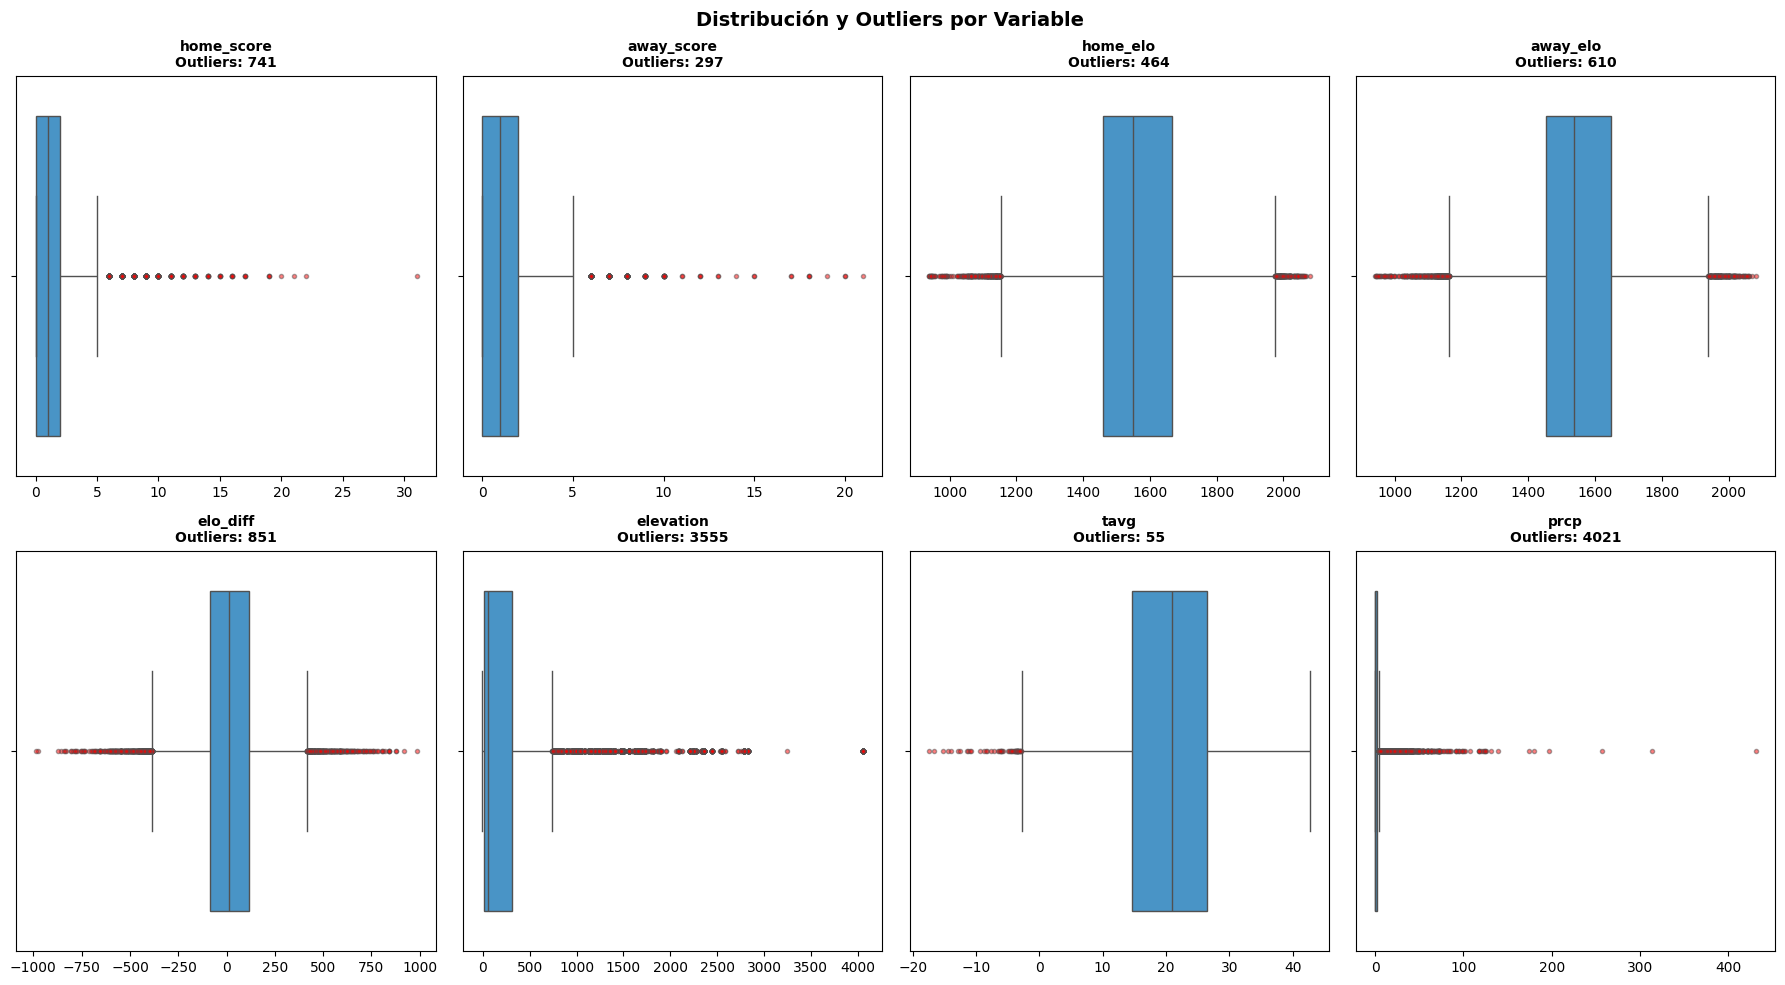

In [ ]:
# Grafico de cajas y bigotes
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas para los boxplots
columnas_box = [
    'home_score', 'away_score',
    'home_elo', 'away_elo', 'elo_diff',
    'elevation', 'tavg', 'prcp'
]

# plt.subplots(2, 4) — 2 filas y 4 columnas de gráficos
# axes.flatten() — convierte la matriz 2x4 en una lista simple para iterar
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_box):
    # sns.boxplot — dibuja el gráfico de caja y bigote
    # x=df[col] — datos de la columna
    # ax=axes[i] — en qué subplot dibujarlo
    # flierprops — personaliza los puntos outliers (los puntos fuera de los bigotes)
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color='#3498db',
        flierprops=dict(
            marker='o',          # forma del punto outlier
            markerfacecolor='red',  # color de relleno
            markersize=3,        # tamaño del punto
            alpha=0.5            # transparencia
        )
    )
    
    # Calculamos cantidad de outliers para mostrar en el título
    # IQR — rango intercuartílico (Q3 - Q1)
    Q1 = df[col].quantile(0.25)  # primer cuartil
    Q3 = df[col].quantile(0.75)  # tercer cuartil
    IQR = Q3 - Q1
    
    # Límites para considerar outlier: fuera de 1.5 * IQR
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    
    axes[i].set_title(f'{col}\nOutliers: {n_outliers}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Distribución y Outliers por Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

### analisis numerico

In [ ]:
# muestro solo las columnas numericas para tener referencia
# select_dtypes(include='number'): esto filtra las columnas numericas automatica y directamente
columnas_numericas = df.select_dtypes(include='number').columns.to_list()
# hacemos un for para mostrar de mejor manera la info
for i in columnas_numericas:
    print(f"{i}")

home_score
away_score
home_elo
away_elo
elo_diff
expected_result
home_form_l5
away_form_l5
lat
lon
tavg
wspd
prcp
elevation
rhum
home_avg_goals_scored_l5
home_avg_goals_conceded_l5
away_avg_goals_scored_l5
away_avg_goals_conceded_l5
expected_goals_home
expected_goals_away


In [ ]:
resumen = df[columnas_numericas].describe().T # en este caso .describe().T lo que hace es que invierte las filas con las columnas para lograr una mejor presentacion de la data
resumen['median'] = df[columnas_numericas].median()
resumen['mode'] = df[columnas_numericas].mode().iloc[0]
resumen['skew'] = df[columnas_numericas].skew()
resumen['kurtosis'] = df[columnas_numericas].kurtosis()

print(resumen[['mean', 'median', 'mode', 'std']].round(2))
print('\n')
print(resumen[['min', 'max', 'skew', 'kurtosis']].round(2))

                               mean   median     mode     std
home_score                     1.63     1.00     1.00    1.69
away_score                     1.10     1.00     0.00    1.34
home_elo                    1560.65  1550.43  1500.00  163.03
away_elo                    1545.88  1537.97  1500.00  159.01
elo_diff                      14.77    14.59     0.00  174.65
expected_result                0.52     0.52     0.50    0.20
home_form_l5                   6.95     7.00     7.00    3.61
away_form_l5                   6.73     7.00     7.00    3.58
lat                           24.17    29.33    25.29   24.00
lon                           11.60    15.98    51.53   61.04
tavg                          20.07    21.00    26.80    7.67
wspd                          13.00    11.60     9.40    6.77
prcp                           2.68     0.00     0.00    8.53
elevation                    289.87    59.25    15.25  514.96
rhum                          71.50    75.00    80.00   15.92
home_avg

Explicacion de medidas:

Medidas de tendencia central:

    mean (media): En este caso el valor 'promedio' de home_elo es de 1560.65, lo cual dicta que el grueso de los equipos esta concentrado en ese nivel de puntos de elo, en este caso podemos mirar el 1.63 de ratio de victorias que poseen los equipos locales para dictaminar que son los que mayor promedio de elo suelen tener, ya que son los que en promedio mas victorias tienen.

    median (mediana): En este caso el valor que esta 'al medio' en la muestra de away_elo es 1537.97 punto de elo, lo cual dice que es un valor medio a tener como referencia, en este sentido se dice de los equipos que llegaron a ganar varios partidos, pero sin llegar al porcentaje de victorias de los equipos locales en promedio.

    mode (moda): En este caso el valor que 'mas se repite' es de 1500.0 en ambos indices de equipos, por el hecho de ser el valor por el cual se comienza, esta calro que es el valor mas repetido e incluso despues de varios partidos de cada equipo, sigue siendo un valor el cual se repite mucho, esto nos dice sobre los equipos que mantienen un rendimiento estable pero sin mostrar lo suficiente como para mejorar.

Otras medidas estadisticas:

    std: Podemos hablar sobre la desiacion estandar que podemos conseguir en a columna de goles en promedio, que no es tan alta, con tan solo 0.92, lo que hace que si haya un poco de disperion dentro de la caja en donde se encierran estos datos, pero no es tanta como se podria esperar en un principio.

    min - max: En cuanto a estos dos resultados podemos datar que en cuanto a la elevacion del terreno sobre el nivel del mar, tenemos que el numero minimo es: -9.00 y el nmero maximo es: 4058.00, esto hace posible realizar conjeturas sobre la complejidad del terreno y que claramente es posible que este influya en los resultados de los encuentros, ya que estos dos indicadores nos dan a entender la inmensa disparidad que existe en esta columna y sus valores.

    skew (skewness): En este caso si el valor es positivo la media tiende a ser de los valores mas pequeños y si es negativa es mas grande, en este caso si es 0 el resultado es que las medidas de tendencia son iguales, en este caso en la columna elo_diff, la diferencia es de -0.07, o que indica que esta levemente inclinado hacia los valores mas grandes o en este caso si lo vemos en un grafico, la asimetria seria estar inclinada levemente hacia la izquierda. (negativo es izquierda y positivo es derecha)

    kurtosis: La Kurtosis mide o registra que tan alta es la distribucion de los datos, en este caso los valores altos pueden denotar muchos outliers en una columna, como es el caso de las columnas home_score y away_score, donde los goles van desde los 0 hasta los 31 goles.

In [ ]:
# varianza de los datos
varianza = df[columnas_numericas].var().round(2)
varianza

home_score                         2.86
away_score                         1.79
home_elo                       26579.49
away_elo                       25283.23
elo_diff                       30501.60
expected_result                    0.04
home_form_l5                      13.07
away_form_l5                      12.84
lat                              575.90
lon                             3726.46
tavg                              58.87
wspd                              45.83
prcp                              72.82
elevation                     265181.87
rhum                             253.31
home_avg_goals_scored_l5           0.85
home_avg_goals_conceded_l5         0.65
away_avg_goals_scored_l5           0.53
away_avg_goals_conceded_l5         1.18
expected_goals_home                2.05
expected_goals_away                1.19
dtype: float64

Dispersion de los datos en base a su media (Promedio):

    La variabilidad de los datos en algunas columnas estan demasiado pronunciadas, por ejemplo:

    home_score y away_score con 2.86 y 1.79, indican que los datos varian bastante, aunque esto es porque como son tabla de goles, es complejo el poder mostrar valores mas bajos, en este caso podria bajar en caso de eliminar los outliers, para luego poder mostrar nuevamente cuanto cambia con valores mas cercanos y no tan dispersos ocmo estan actualmente.

    home_elo y away_elo con 26579.49 y 25283.23, indican que la varianza es alta, en este caso debido a que el elo abarca un rango amplio de equipos y situaciones, desde selecciones con bajo elo hasta selecciones con elo muy alto, lo cual es lo mas esperado porque esta medida no ha hecho ninguna distincion entre equipos, sino que es por columnas por lo cual no indica problema, solo muestra la diferencia y la diversidad que puede haber en equipos de futbol.

    elo_diff con 30501.6, este es el mas factor mas esperado, esto debido a que combina la varianza de ambos elos. La diferencia de equipos podria ir desde 0 puntos de elo hasta cientos de puntos.

    expected_result con 0.04, esta es mas baja por el mero hecho de que es una probabilidad entre 0 y 1, por lo cual no es muy comun que se aleje mucho de la media.

    home_for_l5 y away_for_l5 con 13.07 y 12.84, esto es una varianza moderada porque refleja la forma reciente de los equipos en un tiempo razonable de entre los ultimos 5 encuentros, por ende cada fecha puede cambiar este valor haciendose mayor o menor.

In [ ]:
# covarianzas
print('Covarianzas Relacionadas con el resultado de partidos:')
# ¿el favorito también está en mejor forma?
print(f'La covarianza entre elo_diff y home_form_l5 es de: {df['elo_diff'].cov(df['home_form_l5']).round(2)}')
# deberían estar muy correlacionadas, es una validación
print(f'La covarianza entre elo_diff y expected_result es de: {df['elo_diff'].cov(df['expected_result']).round(2)}')
# ¿hay relación entre la forma de ambos equipos?s
print(f'La covarianza entre home_form_l5 y away_form_l5 es de: {df['home_form_l5'].cov(df['away_form_l5']).round(2)}')
print('\n')
print('Covarianzas Relacionadas con goles de partidos:')
# ataque local vs defensa visitante
print(f'La covarianza entre home_avg_goals_scored_l5 y away_avg_goals_conceded_l5 es de: {df['home_avg_goals_scored_l5'].cov(df['away_avg_goals_conceded_l5']).round(2)}')
# qué tan bien predice los goles reales de local
print(f'La covarianza entre expected_goals_home y home_score es de: {df['expected_goals_home'].cov(df['home_score']).round(2)}')
# qué tan bien predice los goles reales de visita
print(f'La covarianza entre expected_goals_away y away_score es de: {df['expected_goals_away'].cov(df['away_score']).round(2)}')
print('\n')
print('Covarianzas Relacionadas con el clima de las fechas de los partidos:')
# ¿a mayor altitud llueve menos?
print(f'La covarianza entre elevation y prcp es de: {df['elevation'].cov(df['prcp']).round(2)}')
# temperatura y humedad suelen estar relacionadas
print(f'La covarianza entre tavg y rhum es de: {df['tavg'].cov(df['rhum']).round(2)}')

Covarianzas Relacionadas con el resultado de partidos:
La covarianza entre elo_diff y home_form_l5 es de: 249.17
La covarianza entre elo_diff y expected_result es de: 34.3
La covarianza entre home_form_l5 y away_form_l5 es de: 1.78


Covarianzas Relacionadas con goles de partidos:
La covarianza entre home_avg_goals_scored_l5 y away_avg_goals_conceded_l5 es de: -0.01
La covarianza entre expected_goals_home y home_score es de: -0.35
La covarianza entre expected_goals_away y away_score es de: -0.17


Covarianzas Relacionadas con el clima de las fechas de los partidos:
La covarianza entre elevation y prcp es de: -39.18
La covarianza entre tavg y rhum es de: -19.06


Intrepretacion:

    elo_diff vs expected_result (34.3) — covarianza positiva, tiene sentido, a mayor diferencia de ELO mayor probabilidad esperada de victoria local.

    elo_diff vs home_form_l5 (249.17) — positiva, los equipos con mejor ELO tienden a tener mejor forma reciente.

    home_form_l5 vs away_form_l5 (1.78) — casi cero, no hay relación entre la forma de ambos equipos.

    expected_goals_home vs home_score (-0.35) — negativa, esto es raro, indicaría que cuando se esperan más goles del local, en realidad mete menos. Vale la pena revisarlo con correlación que es más fácil de interpretar.

    elevation vs prcp (-39.18) — negativa, a mayor altitud menos lluvia, tiene sentido geográficamente.

    tavg vs rhum (-19.06) — negativa, a mayor temperatura menor humedad, también tiene sentido.

In [ ]:
# Correlaciones
correlaciones = df[columnas_numericas].corr().round(2)
# mostramos solo las correlaciones con home_score, away_score y elo_diff
columnas_interes = ['home_score', 'away_score', 'elo_diff', 'expected_result', 'home_form_l5', 'away_form_l5', 'expected_goals_home', 'expected_goals_away']

print(correlaciones[columnas_interes].to_string())

                            home_score  away_score  elo_diff  expected_result  home_form_l5  away_form_l5  expected_goals_home  expected_goals_away
home_score                        1.00       -0.18      0.40             0.39          0.13         -0.22                -0.14                -0.02
away_score                       -0.18        1.00     -0.37            -0.37         -0.19          0.14                 0.01                -0.12
home_elo                          0.16       -0.23      0.56             0.55          0.58          0.15                 0.37                 0.39
away_elo                         -0.27        0.17     -0.53            -0.51          0.16          0.57                 0.42                 0.37
elo_diff                          0.40       -0.37      1.00             0.98          0.39         -0.38                -0.04                 0.03
expected_result                   0.39       -0.37      0.98             1.00          0.40         -0.38       

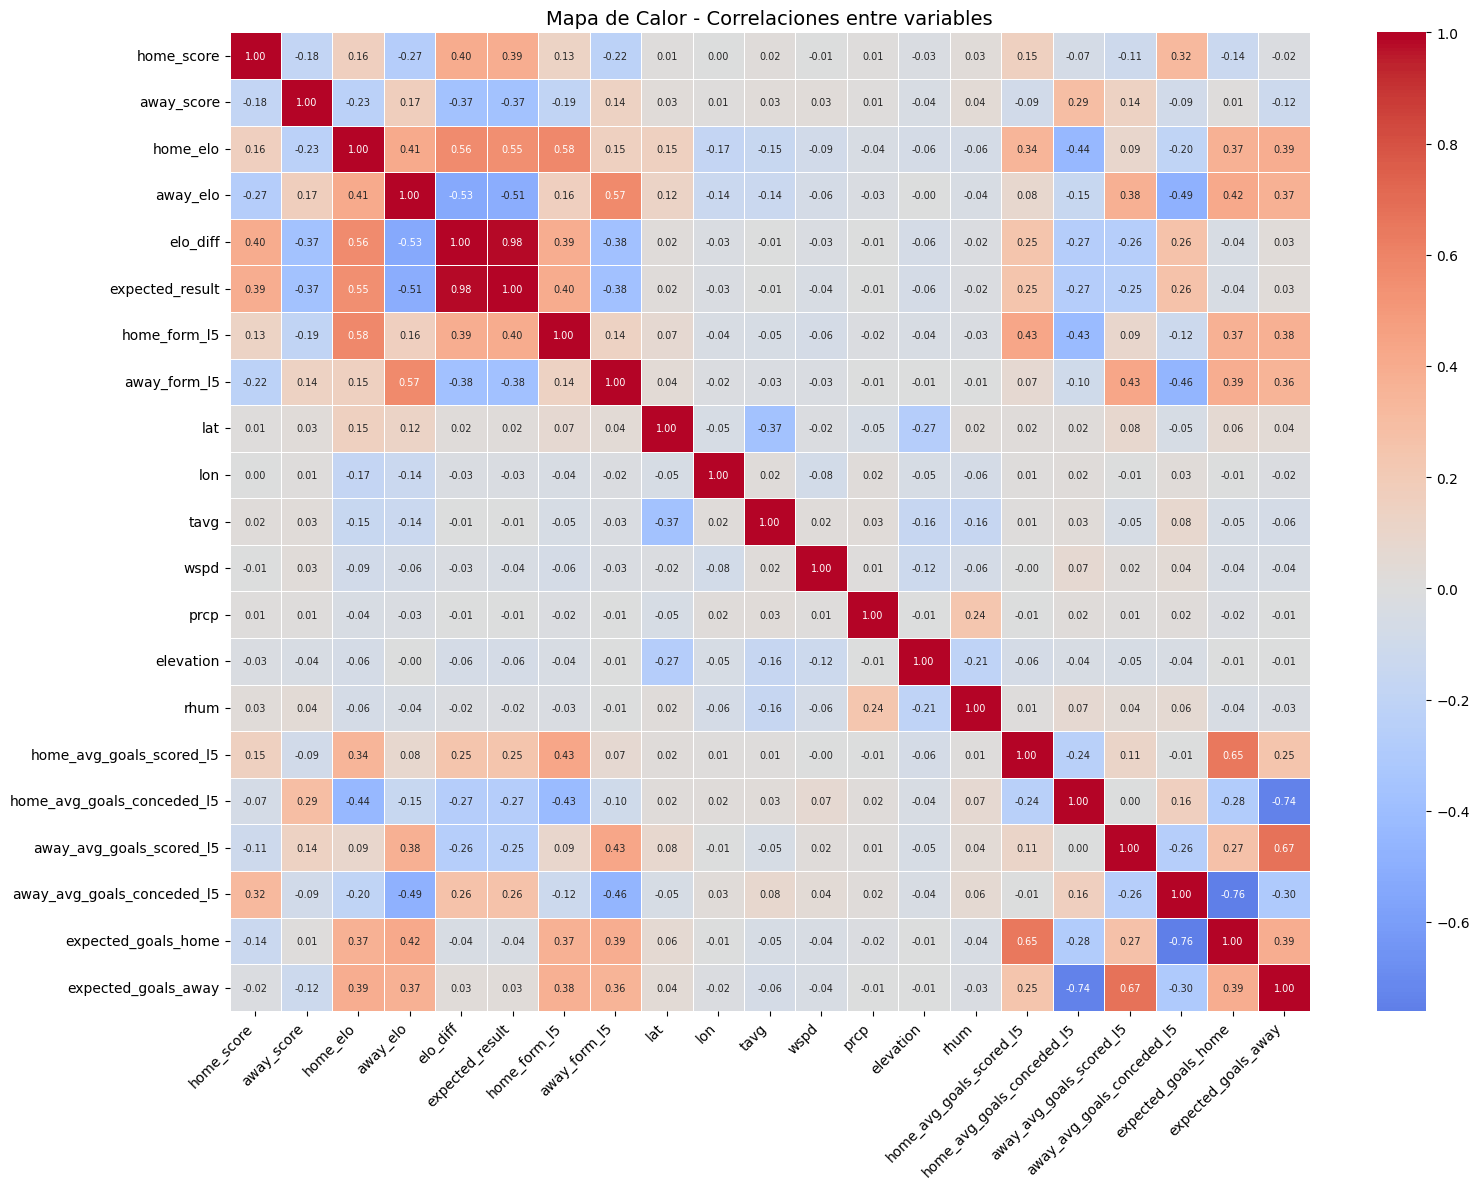

Guardado!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# os.makedirs crea la carpeta graficos/ si no existe. exist_ok=True evita que tire error si ya existe.
os.makedirs('graficos', exist_ok=True)

plt.figure(figsize=(16, 12)) # Crea un lienzo en blanco. figsize=(16, 12) define el ancho y alto en pulgadas
sns.heatmap(
    correlaciones, # el dataframe creado llamado correlaciones
    annot=True, # muestra los numeros dentro de cada celda
    fmt='.2f', # formato de los numeros, en este caso con 2 decimales
    cmap='coolwarm', #paleta de colores: azul valores negativos y rojo valores positivos
    center=0, # el blanco/neutro esta en 0
    linewidths=0.5, # lineas separadoras entre celdas
    annot_kws={'size': 7} # amaño de la letra de los numeros
)
plt.title('Mapa de Calor - Correlaciones entre variables', fontsize=14) # titulo del grafico
plt.xticks(rotation=45, ha='right') # etiquetas eje X rotadas 45° para que no se solapen
plt.yticks(rotation=0) # etiquetas eje Y horizontales
plt.tight_layout() # ajusta automáticamente los márgenes
plt.savefig('graficos/heatmap_correlaciones.png', dpi=150, bbox_inches='tight') # dpi=150 es la resolución de la imagen - bbox_inches='tight' evita que se corten las etiquetas al guardar.
plt.show() # mostramos el grafico
print("Guardado!")

Las conclusiones más importantes:

Muy buenas correlaciones:

    elo_diff vs expected_result (0.98) — casi perfecta, tiene sentido porque expected_result se calcula desde ELO
    home_avg_goals_conceded_l5 vs expected_goals_home (-0.76) — fuerte, la defensa del visitante afecta mucho los goles esperados del local
    away_avg_goals_conceded_l5 vs expected_goals_away (-0.30) — similar pero menos pronunciada

Correlaciones con home_score:

    elo_diff (0.40) — el favorito tiende a meter más goles
    away_avg_goals_conceded_l5 (0.32) — si el visitante defiende mal, el local anota más
    home_form_l5 (0.13) — la forma reciente ayuda algo pero no tanto

Correlaciones con away_score:

    away_elo (0.17) — el visitante con mejor ELO mete más
    home_avg_goals_conceded_l5 (0.29) — si el local defiende mal, el visitante anota más

Variables climáticas:

    tavg, wspd, prcp, elevation, rhum — todas cercanas a 0, poca correlación lineal con goles y resultado. Eso no significa que no aporten al modelo

### KPi's

#### Lista de kpi's

Generales:

    Victorias, empates y derrotas de locales y visitantes en FIFA World Cup
    Promedio de goles por partido de locales y visitantes
    Porcentaje de partidos neutrales
    País que ganó más partidos de clasificatorias en la FIFA World Cup
    Top 15 países donde se realizaron más encuentros
    Top 15 países locales que más jugaron fuera de su nación

Nuevos con ELO:

    Top 10 selecciones con mayor ELO promedio histórico
    Evolución del ELO de las selecciones del Mundial 2026

Nuevos con goles:

    Top 10 selecciones con mejor promedio goleador histórico
    Partidos con más goles por torneo

Nuevos con clima/elevación:

    Porcentaje de victorias locales según altitud del estadio
    Promedio de goles según temperatura y lluvia

Nuevo con result:

    Ventaja de local por torneo — ¿en qué torneo gana más el local?

#### kpi's Generales

In [ ]:
import pandas as pd
df = pd.read_csv('dfa8_con_clima.csv')


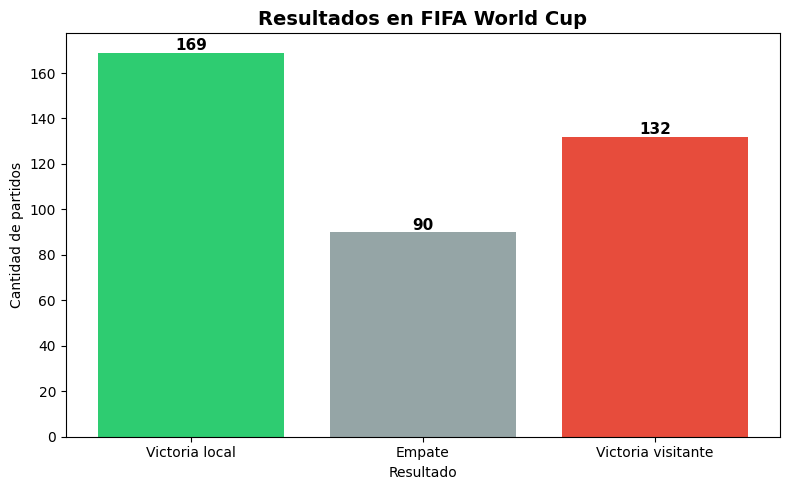

In [ ]:
# kpi 1:
# Victorias, empates y derrotas de locales y visitantes en FIFA world cup
import matplotlib.pyplot as plt
import os

os.makedirs('graficos', exist_ok=True) # crea si no existe el folder

wc = df[df['tournament'] == 'FIFA World Cup'] # filtrar el torneo dentro de la columna

# contamos cuantos ['home_win', 'draw', 'away_win'] hay, y reindex fuerza el orden especifico asignado, para que no salga en cualquier orden despues en el grafico
resultados = wc['result'].value_counts().reindex(['home_win', 'draw', 'away_win'])

# creamos el lienzo a trazar
# fig crea los ejes, es toda la figura
# ax crea el apartado donde se crean los graficos, es el area de dibujo
# figsize el ancho y alto en pulgadas
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar( # dibujando las barras
    ['Victoria local', 'Empate', 'Victoria visitante'], # primer argumento el eje x
    resultados.values, # alturas de cada barra
    color = ['#2ecc71', '#95a5a6', '#e74c3c'] # color de la barra en orden del eje x
)

# iteramos sobre las barras para agregar numeros encima
# bar.get_x() + bar.get_width()/2 calcula el centro horizontal de la barra
# bar.get_height() + 1 coloca el textp justo encima de la barra
# str(bar.get_height()) convierte el numero a texto para mostrarlo
# ha= center/left/right, es el lugar donde queda el numero respecto donde se coloca
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(bar.get_height()), ha = 'center', fontsize = 11, fontweight = 'bold')
    
ax.set_title('Resultados en FIFA World Cup', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Cantidad de partidos')
ax.set_xlabel('Resultado')
plt.tight_layout() # ajusta los margenes para que nada quede cortado
plt.savefig('graficos/kpi1_resultados_wc.png', dpi=150, bbox_inches='tight') # dpi = borde etiquetas de los margenes y bbox_inches = evita que se corten los margenes al guardar
plt.show()

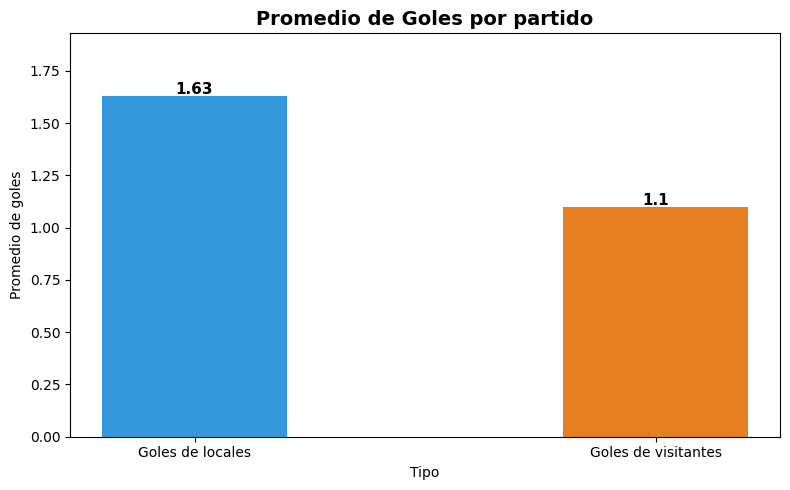

In [ ]:
# kpi 2:
# Promedio de goles por partido de locales y visitantes
import matplotlib.pyplot as plt

promedio_home = df['home_score'].mean().round(2)
promedio_away = df['away_score'].mean().round(2)

fig, ax = plt.subplots(figsize = (8, 5))
# ax.bar — dibuja las barras
# primer argumento — etiquetas eje X
# segundo argumento — valores de las barras
bars = ax.bar(
    ['Goles de locales', 'Goles de visitantes'],
    [promedio_home, promedio_away],
    color = ['#3498db', '#e67e22'],
    width = 0.4 # ancho de las barras, 0.4 es mas angosto que el default 0.8
)

# numero sobre cada barra
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            str(bar.get_height()), ha='center', fontsize=11, fontweight='bold')

ax.set_title('Promedio de Goles por partido', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Promedio de goles')
ax.set_xlabel('Tipo')

# ylim — fija el límite del eje Y para que las barras no queden pegadas al techo
ax.set_ylim(0, max(promedio_home, promedio_away) + 0.3)

plt.tight_layout()
plt.savefig('graficos/kpi2_promedio_goles.png', dpi=150, bbox_inches='tight')
plt.show()

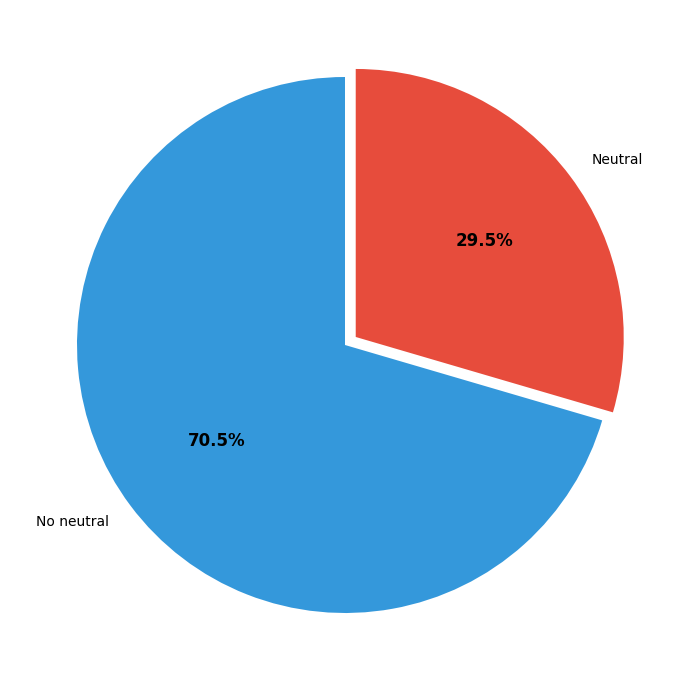

In [ ]:
# kpi 3:
# Porcentaje partidos neutrales
import matplotlib.pyplot as plt

# contamos partidos neutrales y no neutrales
neutral_counts = df['neutral'].value_counts()
labels = ['No neutral', 'Neutral']
sizes = [neutral_counts[False], neutral_counts[True]]

fig, ax = plt.subplots(figsize = (7, 7))
# ax.pie — dibuja un gráfico de torta
# sizes — tamaño de cada porción
# labels — etiquetas de cada porción
# autopct — formato del porcentaje dentro de cada porción (%1.1f%% = 1 decimal)
# startangle — ángulo de inicio del primer trozo
# explode — separa ligeramente una porción para destacarla
wedges, texts, autotexts = ax.pie(
    sizes,
    labels = labels,
    autopct = '%1.1f%%',
    startangle = 90,
    explode = (0, 0.05), # separa ligeramente lamporcion neutral
    colors = ['#3498db', '#e74c3c']
)

# Ajustamos tamaño de fuente de los porcentajes
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('graficos/kpi3_partidos_neutrales.png', dpi=150, bbox_inches='tight')
plt.show()

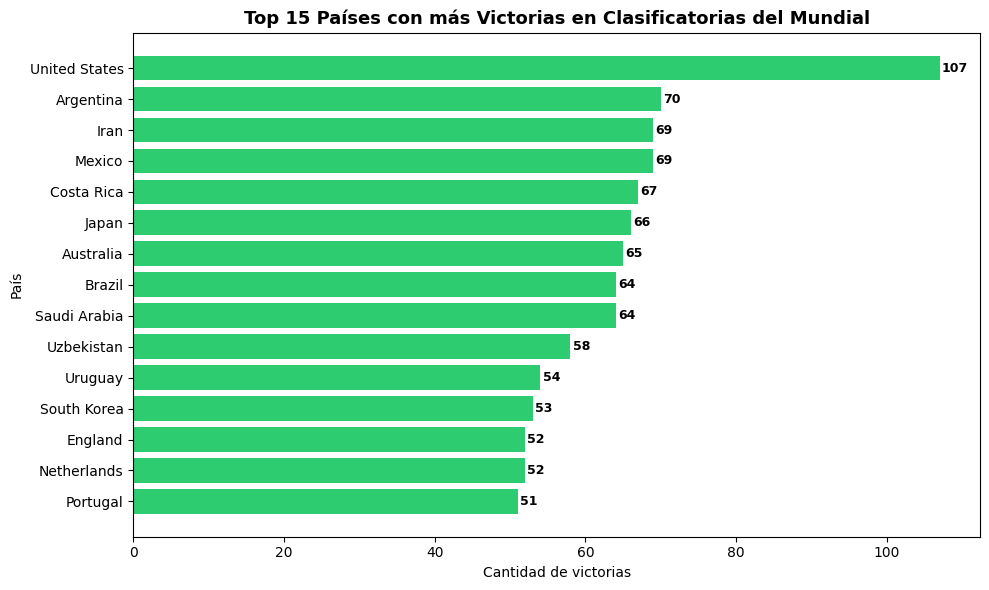

In [ ]:
# kpi 4:
# Pais que gano mas partidos en las clasificatorias de la FIFA World Cup
import matplotlib.pyplot as plt

# Filtramos solo partidos de clasificatorias
clasif = df[df['tournament'] == 'FIFA World Cup qualification']

# Victorias locales — el home_team ganó
victorias_local = clasif[clasif['result'] == 'home_win'].groupby('home_team').size()

# Victorias visitante — el away_team ganó
victorias_away = clasif[clasif['result'] == 'away_win'].groupby('away_team').size()

# Combinamos ambas sumando victorias totales por equipo
# add — suma dos Series alineando por índice, fill_value=0 evita NaN si un equipo no tiene victorias en uno de los dos
victorias_totales = victorias_local.add(victorias_away, fill_value=0).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))

# barh — barras horizontales, más legible con muchos países
bars = ax.barh(
    victorias_totales.index[::-1],  # [::-1] invierte el orden para que el mayor quede arriba
    victorias_totales.values[::-1],
    color='#2ecc71'
)

# Número al final de cada barra
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 15 Países con más Victorias en Clasificatorias del Mundial',fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de victorias')
ax.set_ylabel('País')
plt.tight_layout()
plt.savefig('graficos/kpi4_victorias_clasificatorias.png', dpi=150, bbox_inches='tight')
plt.show()

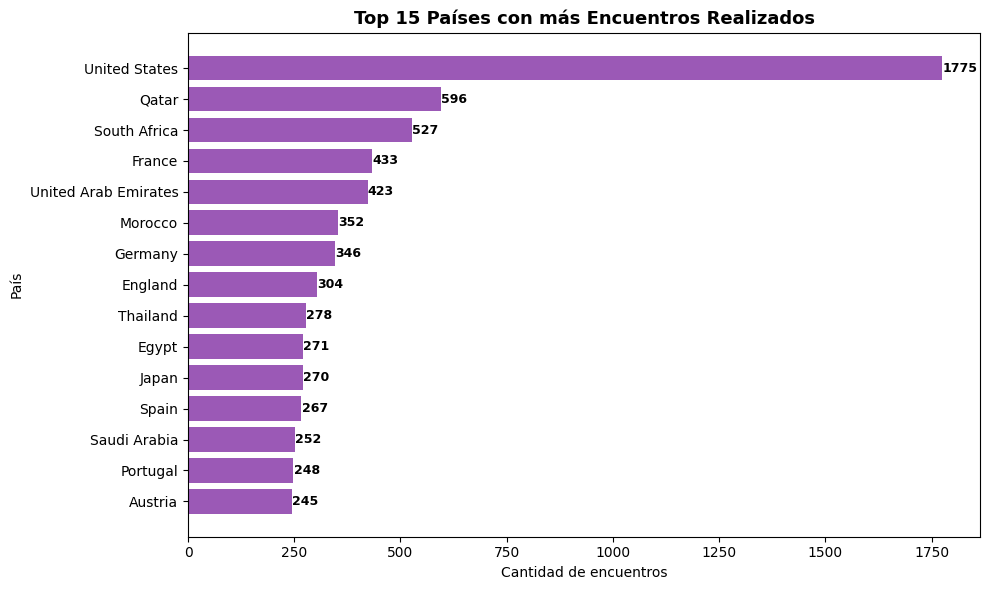

In [ ]:
# kpi 5:
# Top 15 paises donde se realizaron mas encuentros
import matplotlib.pyplot as plt

# Contamos partidos por país y tomamos los 15 primeros
encuentros_pais = df['country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))

# barh — barras horizontales igual que el anterior
bars = ax.barh(
    encuentros_pais.index[::-1],  # [::-1] para que el mayor quede arriba
    encuentros_pais.values[::-1],
    color='#9b59b6'
)

# Número al final de cada barra
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 15 Países con más Encuentros Realizados',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de encuentros')
ax.set_ylabel('País')

plt.tight_layout()
plt.savefig('graficos/kpi5_encuentros_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

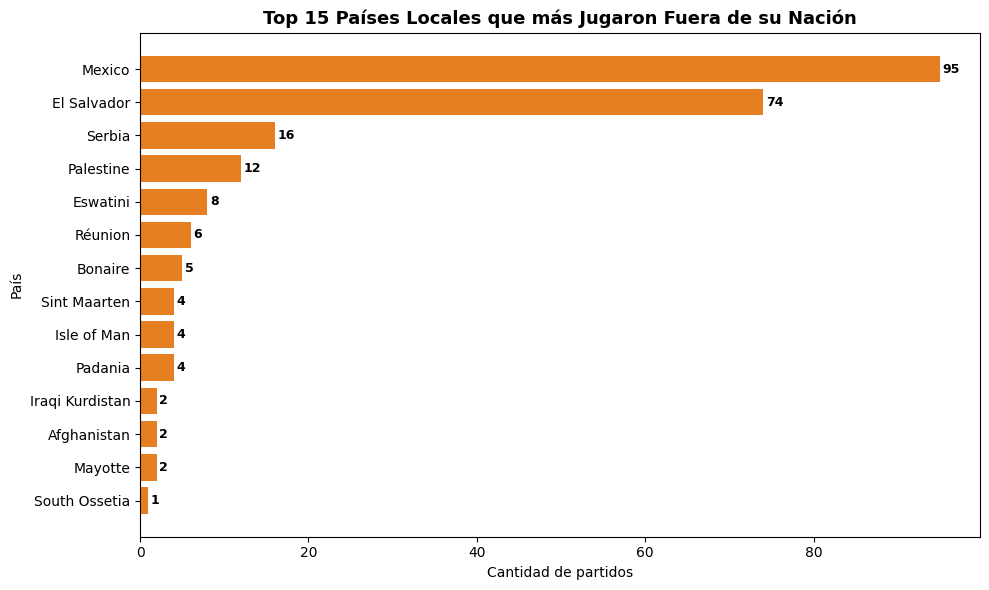

In [ ]:
# kpi 6:
# Top 15 paises que mas jugaron fuera de su nacion
import matplotlib.pyplot as plt
# Un equipo juega fuera de su nación cuando el país del partido es distinto al país del equipo local
# para esto comparamos home_team con country
# Primero necesitamos un mapeo de equipo a su país
# Asumimos que el país más frecuente donde juega de local es su nación
pais_equipo = df.groupby('home_team')['country'].agg(lambda x: x.mode()[0])

# Filtramos partidos donde el país del partido es distinto (!=) país del equipo local
df['pais_equipo_local'] = df['home_team'].map(pais_equipo)
# neutral=True significa que ninguno juega en casa
fuera = df[(df['country'] != df['pais_equipo_local']) & (df['neutral'] == False)]
# Contamos por equipo local
fuera_counts = fuera['home_team'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    fuera_counts.index[::-1],
    fuera_counts.values[::-1],
    color='#e67e22'
)

for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 15 Países Locales que más Jugaron Fuera de su Nación',fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de partidos')
ax.set_ylabel('País')
plt.tight_layout()
plt.savefig('graficos/kpi6_locales_fuera_nacion.png', dpi=150, bbox_inches='tight')
plt.show()

#### kpi's de ELO

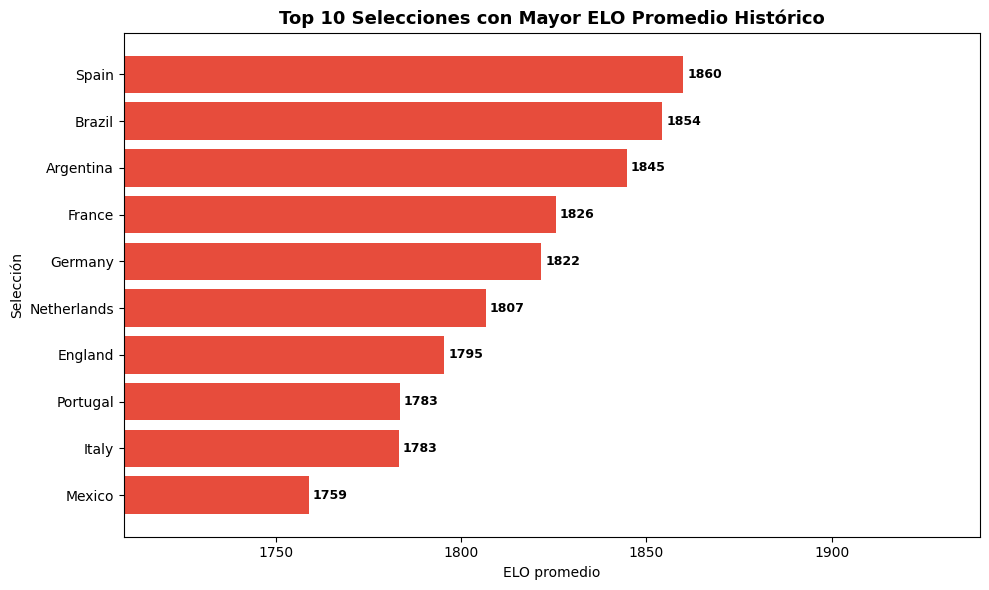

In [ ]:
# kpi 7:
# Top 10 selecciones con mayor ELO promedio histórico
import matplotlib.pyplot as plt

# Calculamos ELO promedio como local y visitante por equipo
elo_home = df.groupby('home_team')['home_elo'].mean()
elo_away = df.groupby('away_team')['away_elo'].mean()

# Combinamos promediando ambos
# add — suma los dos, divide entre 2 para obtener el promedio general
elo_promedio = elo_home.add(elo_away, fill_value=0) / 2
elo_promedio = elo_promedio.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    elo_promedio.index[::-1],
    elo_promedio.values[::-1],
    color='#e74c3c'
)

for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.0f}',  # f'{:.0f}' — formato sin decimales
            va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Selecciones con Mayor ELO Promedio Histórico',fontsize=13, fontweight='bold')
ax.set_xlabel('ELO promedio')
ax.set_ylabel('Selección')
# set_xlim — fija el límite del eje X para que los números no queden cortados
ax.set_xlim(elo_promedio.min() - 50, elo_promedio.max() + 80)
plt.tight_layout()
plt.savefig('graficos/kpi7_elo_promedio.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_19405/3844877225.py:50: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_elo['year'] = pd.to_datetime(df_elo['date']).dt.year


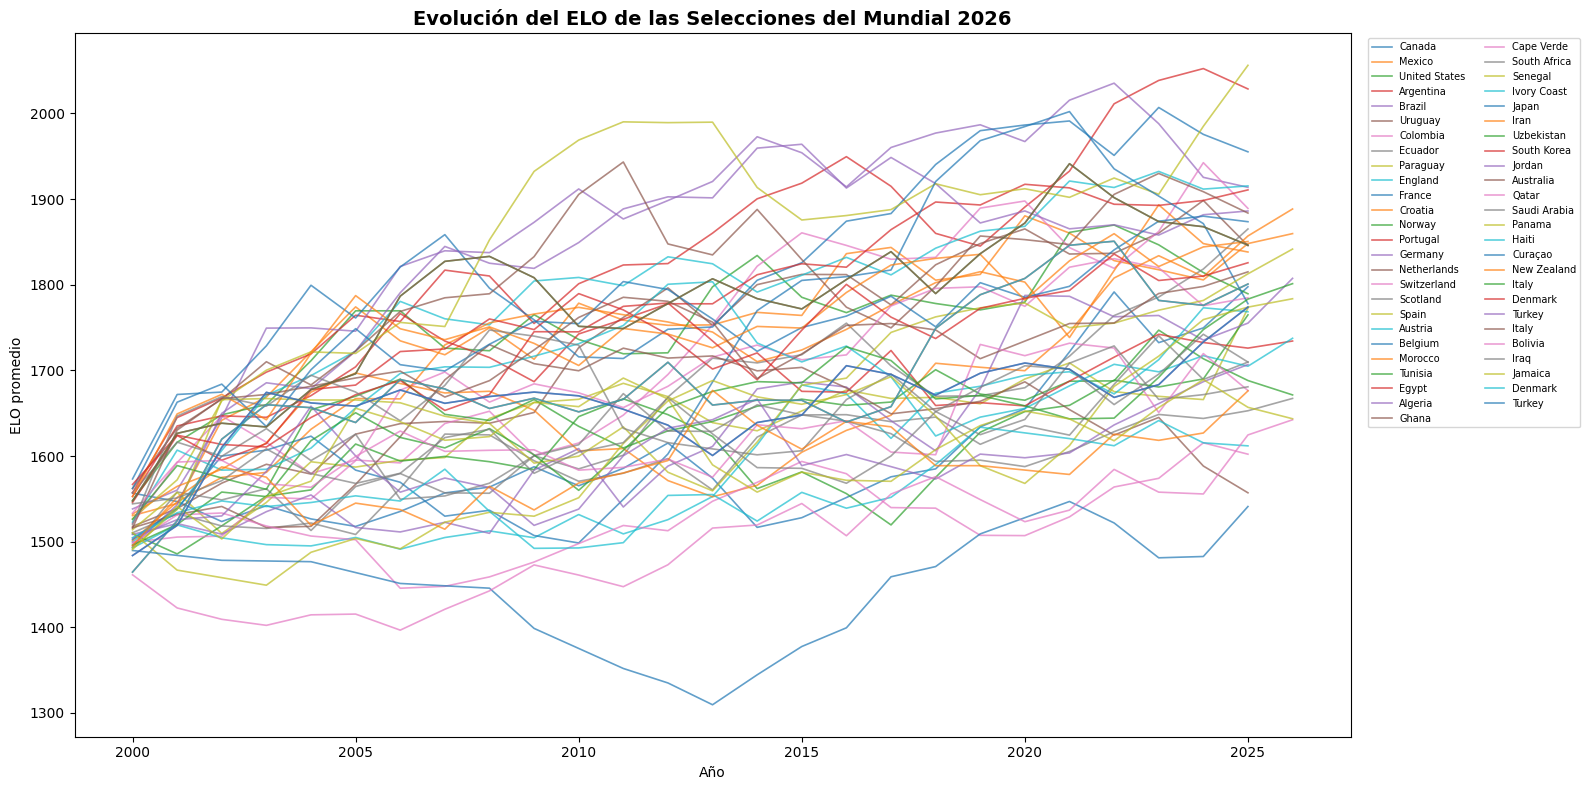

In [ ]:
# kpi 8:
# Evolución del ELO de las selecciones del Mundial 2026
import matplotlib.pyplot as plt

# selecciones que estan clasificadas al mundial
equipos_wc2026 = [
    # Anfitriones
    'Canada', 'Mexico', 'United States',
    # CONMEBOL
    'Argentina', 'Brazil', 'Uruguay', 'Colombia', 'Ecuador', 'Paraguay',
    # UEFA
    'England', 'France', 'Croatia', 'Norway', 'Portugal', 'Germany',
    'Netherlands', 'Switzerland', 'Scotland', 'Spain', 'Austria', 'Belgium',
    # CAF
    'Morocco', 'Tunisia', 'Egypt', 'Algeria', 'Ghana', 'Cape Verde',
    'South Africa', 'Senegal', 'Ivory Coast',
    # AFC
    'Japan', 'Iran', 'Uzbekistan', 'South Korea', 'Jordan', 'Australia',
    'Qatar', 'Saudi Arabia',
    # CONCACAF
    'Panama', 'Haiti', 'Curaçao',
    # OFC
    'New Zealand',
    # Repesca UEFA
    'Italy', 'Denmark', 'Turkey',
    # Repesca intercontinental
    'Italy', 'Bolivia', 'Iraq', 'Jamaica', 'Denmark', 'Turkey'
]

'''
# primero verificamos que selccion no se encuentra en el dataset
no_encontrados = [e for e in equipos_wc2026 if e not in df['home_team'].unique()]
print("No encontrados:", no_encontrados) # TODOS ESTABAN EN EL DATASET
'''

# Filtramos solo partidos de equipos clasificados como locales
# isin comprueba que los equipos realmente esten en el array
df_wc = df[df['home_team'].isin(equipos_wc2026)][['date', 'home_team', 'home_elo']].copy()
df_wc.columns = ['date', 'team', 'elo']

# Agregamos también cuando juegan de visitante
df_wc2 = df[df['away_team'].isin(equipos_wc2026)][['date', 'away_team', 'away_elo']].copy()
df_wc2.columns = ['date', 'team', 'elo']

# Combinamos ambos
df_elo = pd.concat([df_wc, df_wc2]).sort_values('date')

# Agrupamos por año y equipo para no tener demasiados puntos
# resample no funciona bien con groupby, usamos año directamente
df_elo['year'] = pd.to_datetime(df_elo['date']).dt.year
elo_anual = df_elo.groupby(['year', 'team'])['elo'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 8))

# Graficamos una línea por equipo
for equipo in equipos_wc2026:
    datos = elo_anual[elo_anual['team'] == equipo]
    if not datos.empty:
        ax.plot(
            datos['year'],
            datos['elo'],
            linewidth=1.2,
            alpha=0.7,  # alpha — transparencia, 0=invisible, 1=sólido
            label=equipo
        )

ax.set_title('Evolución del ELO de las Selecciones del Mundial 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('ELO promedio')

# legend — muestra la leyenda fuera del gráfico para no tapar las líneas
ax.legend(
    bbox_to_anchor=(1.01, 1),  # posición fuera del gráfico a la derecha
    loc='upper left',
    fontsize=7,
    ncol=2  # ncol — divide la leyenda en 2 columnas
)

plt.tight_layout()
plt.savefig('graficos/kpi8_evolucion_elo_wc2026.png', dpi=150, bbox_inches='tight')
plt.show()

#### Kpi's de Goles

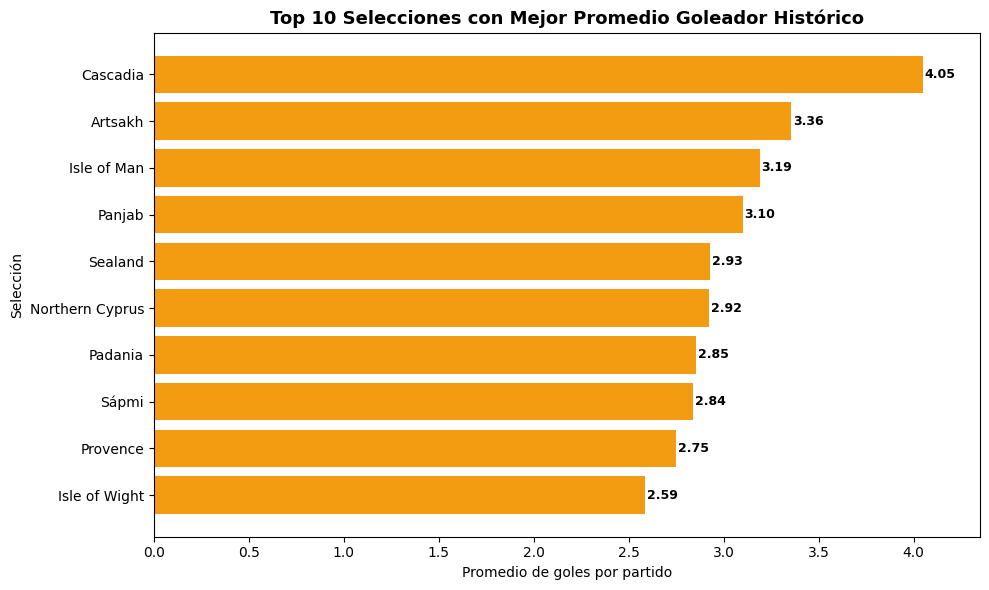

In [ ]:
# kpi 9:
# Top 10 selecciones con mejor promedio goleador histórico
import matplotlib.pyplot as plt

# Filtramos equipos con al menos 8 partidos jugados
partidos_home = df.groupby('home_team').size()
partidos_away = df.groupby('away_team').size()
partidos_totales = partidos_home.add(partidos_away, fill_value=0)

equipos_validos = partidos_totales[partidos_totales >= 8].index

# Filtramos solo equipos válidos
goles_home = df[df['home_team'].isin(equipos_validos)].groupby('home_team')['home_score'].mean()
goles_away = df[df['away_team'].isin(equipos_validos)].groupby('away_team')['away_score'].mean()

# Promedio general combinando local y visitante
goles_promedio = goles_home.add(goles_away, fill_value=0) / 2
goles_promedio = goles_promedio.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    goles_promedio.index[::-1],
    goles_promedio.values[::-1],
    color='#f39c12'
)

for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}',  # 2 decimales para el promedio
            va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Selecciones con Mejor Promedio Goleador Histórico', fontsize=13, fontweight='bold')
ax.set_xlabel('Promedio de goles por partido')
ax.set_ylabel('Selección')
ax.set_xlim(0, goles_promedio.max() + 0.3)
plt.tight_layout()
plt.savefig('graficos/kpi9_promedio_goleador.png', dpi=150, bbox_inches='tight')
plt.show()

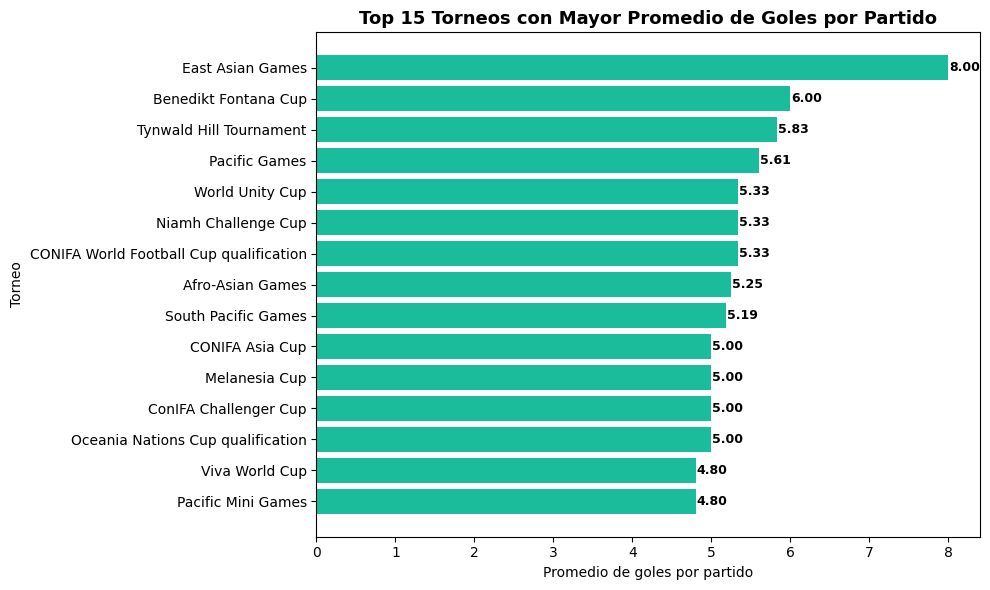

In [ ]:
# kpi 10:
# Partidos con más goles por torneo
import matplotlib.pyplot as plt

# Total de goles por partido
df['total_goals'] = df['home_score'] + df['away_score']

# Promedio de goles totales por torneo
goles_torneo = df.groupby('tournament')['total_goals'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    goles_torneo.index[::-1],
    goles_torneo.values[::-1],
    color='#1abc9c'
)

for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}',
            va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 15 Torneos con Mayor Promedio de Goles por Partido',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Promedio de goles por partido')
ax.set_ylabel('Torneo')

plt.tight_layout()
plt.savefig('graficos/kpi10_goles_por_torneo.png', dpi=150, bbox_inches='tight')
plt.show()

# Borramos columna auxiliar
df = df.drop(columns=['total_goals'])

#### Kpi's de CLima y ELevacion

/tmp/ipykernel_19405/1095086495.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['rango_altitud'] = pd.cut(
/tmp/ipykernel_19405/1095086495.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True i

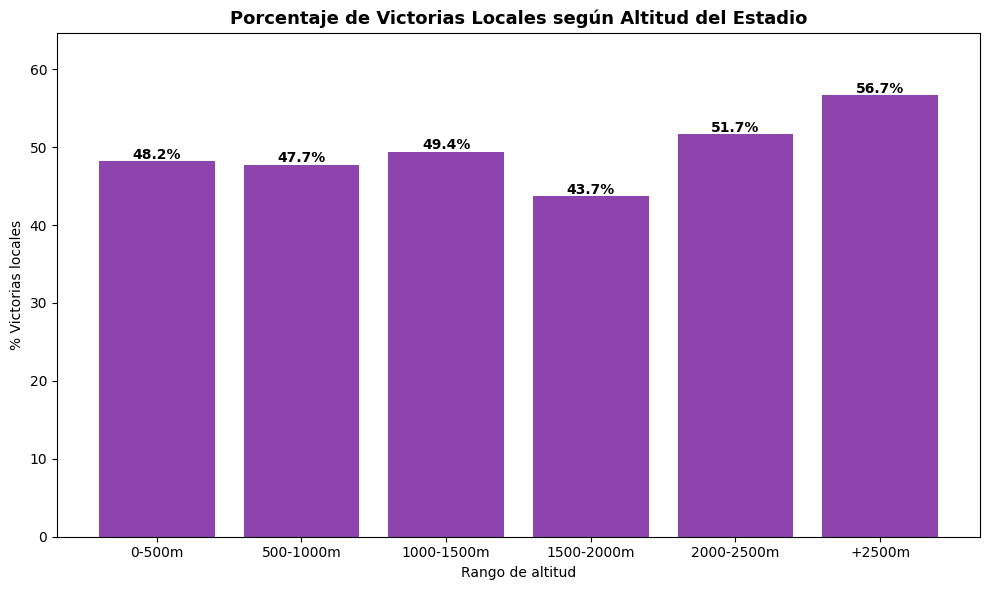

In [ ]:
# kpi 11:
# Porcentaje de victorias locales según altitud del estadio
import matplotlib.pyplot as plt

# Creamos rangos de altitud
# pd.cut — divide una columna continua en rangos/categorías
df['rango_altitud'] = pd.cut(
    df['elevation'],
    bins=[0, 500, 1000, 1500, 2000, 2500, 9000],  # límites de cada rango
    labels=['0-500m', '500-1000m', '1000-1500m', '1500-2000m', '2000-2500m', '+2500m']
)

# Porcentaje de victorias locales por rango de altitud
victorias_altitud = df.groupby('rango_altitud').apply(
    lambda x: (x['result'] == 'home_win').sum() / len(x) * 100
).round(2)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    victorias_altitud.index,
    victorias_altitud.values,
    color='#8e44ad'
)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('Porcentaje de Victorias Locales según Altitud del Estadio',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Rango de altitud')
ax.set_ylabel('% Victorias locales')
ax.set_ylim(0, victorias_altitud.max() + 8)

plt.tight_layout()
plt.savefig('graficos/kpi11_victorias_altitud.png', dpi=150, bbox_inches='tight')
plt.show()

# Borramos columna auxiliar
df = df.drop(columns=['rango_altitud'])

/tmp/ipykernel_19405/142497856.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['rango_temp'] = pd.cut(
/tmp/ipykernel_19405/142497856.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting v

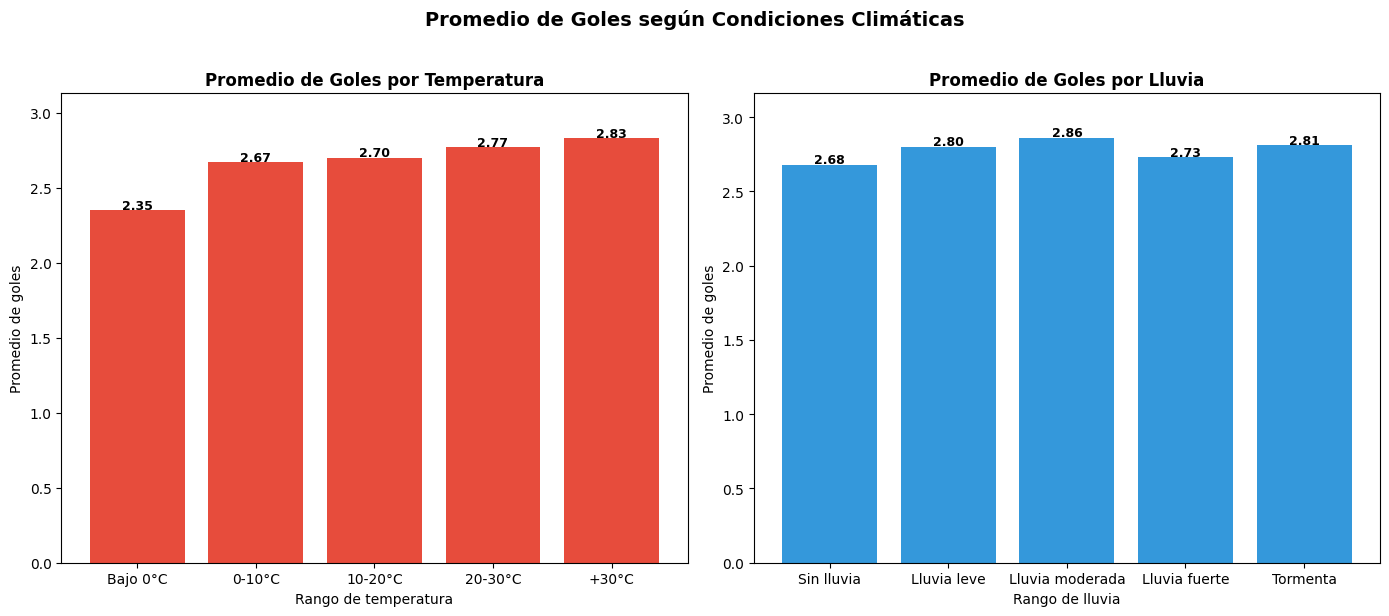

In [ ]:
# kpi 12:
# Promedio de goles según temperatura y lluvia
import matplotlib.pyplot as plt

# Creamos rangos de temperatura
df['rango_temp'] = pd.cut(
    df['tavg'],
    bins=[-20, 0, 10, 20, 30, 50],
    labels=['Bajo 0°C', '0-10°C', '10-20°C', '20-30°C', '+30°C']
)

# Creamos rangos de lluvia
df['rango_lluvia'] = pd.cut(
    df['prcp'],
    bins=[-1, 0, 5, 15, 30, 500],
    labels=['Sin lluvia', 'Lluvia leve', 'Lluvia moderada', 'Lluvia fuerte', 'Tormenta']
)

# Promedio de goles totales por rango de temperatura y lluvia
df['total_goals'] = df['home_score'] + df['away_score']

goles_temp = df.groupby('rango_temp')['total_goals'].mean().round(2)
goles_lluvia = df.groupby('rango_lluvia')['total_goals'].mean().round(2)

# Graficamos dos subplots — uno para temperatura y otro para lluvia
# plt.subplots(1, 2) — 1 fila, 2 columnas de gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1 — Temperatura
bars1 = ax1.bar(
    goles_temp.index,
    goles_temp.values,
    color='#e74c3c'
)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Promedio de Goles por Temperatura', fontsize=12, fontweight='bold')
ax1.set_xlabel('Rango de temperatura')
ax1.set_ylabel('Promedio de goles')
ax1.set_ylim(0, goles_temp.max() + 0.3)

# Gráfico 2 — Lluvia
bars2 = ax2.bar(
    goles_lluvia.index,
    goles_lluvia.values,
    color='#3498db'
)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Promedio de Goles por Lluvia', fontsize=12, fontweight='bold')
ax2.set_xlabel('Rango de lluvia')
ax2.set_ylabel('Promedio de goles')
ax2.set_ylim(0, goles_lluvia.max() + 0.3)

plt.suptitle('Promedio de Goles según Condiciones Climáticas',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('graficos/kpi12_goles_clima.png', dpi=150, bbox_inches='tight')
plt.show()

# Borramos columnas auxiliares
df = df.drop(columns=['rango_temp', 'rango_lluvia', 'total_goals'])

#### Kpi's Resultado

/tmp/ipykernel_19405/4232459375.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ventaja_local = df_torneos.groupby('tournament').apply(


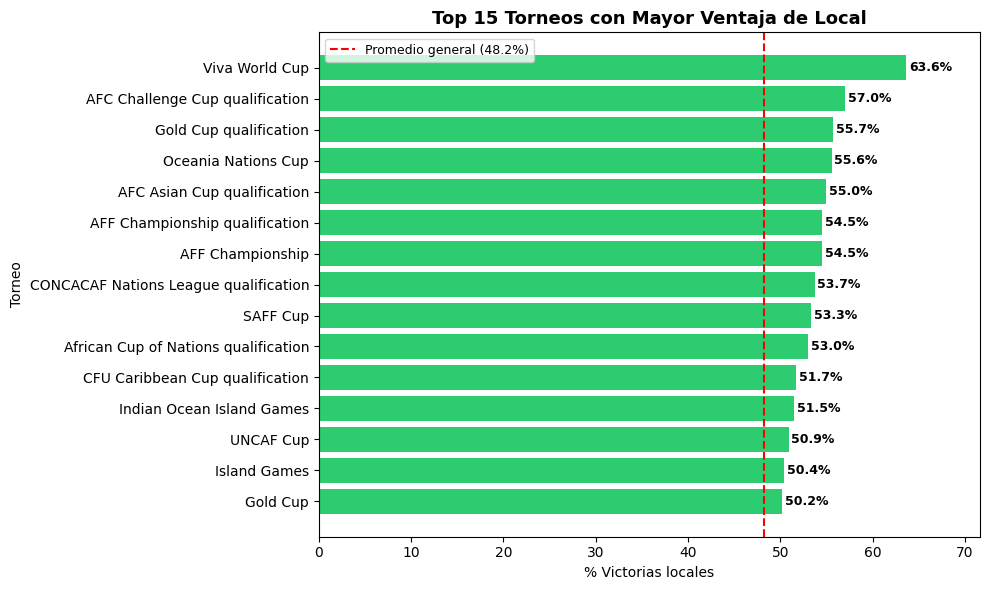

In [ ]:
# kpi: 13
# Ventaja de local por torneo — ¿en qué torneo gana más el local?
import matplotlib.pyplot as plt

# Calculamos porcentaje de victorias locales por torneo
# Solo torneos con al menos 50 partidos para que sea representativo
partidos_por_torneo = df.groupby('tournament').size()
torneos_validos = partidos_por_torneo[partidos_por_torneo >= 50].index

df_torneos = df[df['tournament'].isin(torneos_validos)]

ventaja_local = df_torneos.groupby('tournament').apply(
    lambda x: (x['result'] == 'home_win').sum() / len(x) * 100
).round(2).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    ventaja_local.index[::-1],
    ventaja_local.values[::-1],
    color='#2ecc71'
)

for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 15 Torneos con Mayor Ventaja de Local',
             fontsize=13, fontweight='bold')
ax.set_xlabel('% Victorias locales')
ax.set_ylabel('Torneo')
ax.set_xlim(0, ventaja_local.max() + 8)

# Línea vertical punteada en el promedio general
promedio_general = (df['result'] == 'home_win').sum() / len(df) * 100
ax.axvline(
    x=promedio_general,
    color='red',
    linestyle='--',  # línea punteada
    linewidth=1.5,
    label=f'Promedio general ({promedio_general:.1f}%)'
)

# legend — muestra la leyenda
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('graficos/kpi13_ventaja_local_torneo.png', dpi=150, bbox_inches='tight')
plt.show()

## Tratamiento de datos pre-modelos

**Objetivos:**

**Regresion:** Predecir la cantidad de goles.

**CLasificacion:** Predecir el resultado del partido con sus probabilidades.

### Tratamiento General

In [1]:
import pandas as pd

df = pd.read_csv('dfa8_con_clima.csv')
df.dtypes

date                           object
home_team                      object
away_team                      object
home_score                      int64
away_score                      int64
tournament                     object
city                           object
country                        object
neutral                          bool
home_elo                      float64
away_elo                      float64
elo_diff                      float64
expected_result               float64
home_form_l5                    int64
away_form_l5                    int64
lat                           float64
lon                           float64
tavg                          float64
wspd                          float64
prcp                          float64
elevation                     float64
rhum                          float64
result                         object
home_avg_goals_scored_l5      float64
home_avg_goals_conceded_l5    float64
away_avg_goals_scored_l5      float64
away_avg_goa

In [2]:
'''
Historial de goles ampliado:

home_avg_goals_scored_l10 — promedio goles anotados últimos 10 partidos
home_avg_goals_conceded_l10 — promedio goles recibidos últimos 10 partidos
away_avg_goals_scored_l10 — igual para visitante
away_avg_goals_conceded_l10 — igual para visitante
'''
# Ordenamos por equipo y fecha
df = df.sort_values(['home_team', 'date']).reset_index(drop=True)

def calcular_promedios_goles_l10(df, equipo_col, goles_anotados_col, goles_recibidos_col):
    equipos = df[equipo_col].unique()
    avg_scored = {}
    avg_conceded = {}
    
    for equipo in equipos:
        partidos = df[df[equipo_col] == equipo].sort_values('date')
        for i, (idx, row) in enumerate(partidos.iterrows()):
            # Tomamos los últimos 10 en lugar de 5
            ultimos_10 = partidos.iloc[max(0, i-10):i]
            if len(ultimos_10) > 0:
                avg_scored[idx] = ultimos_10[goles_anotados_col].mean()
                avg_conceded[idx] = ultimos_10[goles_recibidos_col].mean()
            else:
                avg_scored[idx] = None
                avg_conceded[idx] = None
    
    return avg_scored, avg_conceded

# Local
print("Calculando promedios local L10...")
home_scored_l10, home_conceded_l10 = calcular_promedios_goles_l10(
    df, 'home_team', 'home_score', 'away_score'
)

# Visitante
print("Calculando promedios visitante L10...")
away_scored_l10, away_conceded_l10 = calcular_promedios_goles_l10(
    df, 'away_team', 'away_score', 'home_score'
)

# Asignamos
df['home_avg_goals_scored_l10'] = df.index.map(home_scored_l10).round(2)
df['home_avg_goals_conceded_l10'] = df.index.map(home_conceded_l10).round(2)
df['away_avg_goals_scored_l10'] = df.index.map(away_scored_l10).round(2)
df['away_avg_goals_conceded_l10'] = df.index.map(away_conceded_l10).round(2)

# Verificamos nulos
for col in ['home_avg_goals_scored_l10', 'home_avg_goals_conceded_l10',
            'away_avg_goals_scored_l10', 'away_avg_goals_conceded_l10']:
    print(f"{col}: {df[col].isna().sum()} nulos")


Calculando promedios local L10...
Calculando promedios visitante L10...
home_avg_goals_scored_l10: 305 nulos
home_avg_goals_conceded_l10: 305 nulos
away_avg_goals_scored_l10: 299 nulos
away_avg_goals_conceded_l10: 299 nulos


/tmp/ipykernel_11367/2715824839.py:44: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['home_avg_goals_scored_l10'] = df.index.map(home_scored_l10).round(2)
/tmp/ipykernel_11367/2715824839.py:45: FutureWarning: ChainedAssignmentError: behav

In [3]:
for col in ['home_avg_goals_scored_l10', 'home_avg_goals_conceded_l10',
            'away_avg_goals_scored_l10', 'away_avg_goals_conceded_l10']:
    media = df[col].mean()
    df[col] = df[col].fillna(round(media, 2))
    print(f"{col}: media = {round(media, 2)}")

    # Verificamos nulos
for col in ['home_avg_goals_scored_l10', 'home_avg_goals_conceded_l10',
            'away_avg_goals_scored_l10', 'away_avg_goals_conceded_l10']:
    print(f"{col}: {df[col].isna().sum()} nulos")

home_avg_goals_scored_l10: media = 1.64
home_avg_goals_conceded_l10: media = 1.1
away_avg_goals_scored_l10: media = 1.1
away_avg_goals_conceded_l10: media = 1.65
home_avg_goals_scored_l10: 0 nulos
home_avg_goals_conceded_l10: 0 nulos
away_avg_goals_scored_l10: 0 nulos
away_avg_goals_conceded_l10: 0 nulos


/tmp/ipykernel_11367/1306115213.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[col] = df[col].fillna(round(media, 2))


In [4]:
'''
Historial entre equipos (head to head):

h2h_home_goals — promedio de goles del local en partidos previos contra ese visitante específico
h2h_away_goals — igual para el visitante
'''
# Head to head — historial entre los dos equipos específicos
print("Calculando head to head...")

h2h_home_goals = {}
h2h_away_goals = {}

df_sorted = df.sort_values('date').reset_index(drop=True)

for idx, row in df_sorted.iterrows():
    home = row['home_team']
    away = row['away_team']
    fecha = row['date']
    
    # Partidos previos entre estos dos equipos en cualquier dirección
    h2h = df_sorted[
        (df_sorted['date'] < fecha) &
        (
            ((df_sorted['home_team'] == home) & (df_sorted['away_team'] == away)) |
            ((df_sorted['home_team'] == away) & (df_sorted['away_team'] == home))
        )
    ]
    
    if len(h2h) > 0:
        # Goles del equipo local en esos partidos
        goles_home = []
        goles_away = []
        
        for _, p in h2h.iterrows():
            if p['home_team'] == home:
                goles_home.append(p['home_score'])
                goles_away.append(p['away_score'])
            else:
                goles_home.append(p['away_score'])
                goles_away.append(p['home_score'])
        
        h2h_home_goals[idx] = round(sum(goles_home) / len(goles_home), 2)
        h2h_away_goals[idx] = round(sum(goles_away) / len(goles_away), 2)
    else:
        h2h_home_goals[idx] = None
        h2h_away_goals[idx] = None

df['h2h_home_goals'] = df.index.map(h2h_home_goals)
df['h2h_away_goals'] = df.index.map(h2h_away_goals)

print(f"h2h_home_goals nulos: {df['h2h_home_goals'].isna().sum()}")
print(f"h2h_away_goals nulos: {df['h2h_away_goals'].isna().sum()}")


Calculando head to head...
h2h_home_goals nulos: 6417
h2h_away_goals nulos: 6417


/tmp/ipykernel_11367/3991600783.py:48: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['h2h_home_goals'] = df.index.map(h2h_home_goals)
/tmp/ipykernel_11367/3991600783.py:49: FutureWarning: ChainedAssignmentError: behaviour will change in p

In [5]:
# imputar con el promedio goleador individual de cada equipo
# si no tienen historial entre ellos, usamos cuánto meten normalmente.
def imputar_h2h(row):
    if pd.isna(row['h2h_home_goals']):
        row['h2h_home_goals'] = row['home_avg_goals_scored_l5']
    if pd.isna(row['h2h_away_goals']):
        row['h2h_away_goals'] = row['away_avg_goals_scored_l5']
    return row

df = df.apply(imputar_h2h, axis=1)

print(f"h2h_home_goals nulos: {df['h2h_home_goals'].isna().sum()}")
print(f"h2h_away_goals nulos: {df['h2h_away_goals'].isna().sum()}")

h2h_home_goals nulos: 0
h2h_away_goals nulos: 0


In [ ]:
# creacion de columnas de similitud de elo y similitud de forma (para dictaminar empates)
# la formula sera: 1 / (diferencia + 1)
# abs, devuelve el valor absoluto, en este caso si es negativo, lo pasa a positivo
# diferencia grande = valor cercano a 0 (no son parejos)
# diferencia pequeña = valor cercano a 1 (son muy parejos)

df['elo_similarity'] = 1 / (abs(df['elo_diff']) + 1)
df['form_similarity'] = 1 / (abs(df['home_form_l5'] - df['away_form_l5']) + 1)
df['goals_similarity'] = 1 / (abs(df['home_avg_goals_scored_l5'] - df['away_avg_goals_scored_l5']) + 1)

print(df[['elo_similarity', 'form_similarity', 'goals_similarity']].describe().round(3))

       elo_similarity  form_similarity  goals_similarity
count       25435.000        25435.000         25435.000
mean            0.032            0.321             0.597
std             0.091            0.248             0.203
min             0.001            0.062             0.053
25%             0.005            0.143             0.455
50%             0.010            0.250             0.556
75%             0.022            0.333             0.714
max             1.000            1.000             1.000


/tmp/ipykernel_11367/1637800397.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['elo_similarity'] = 1 / (abs(df['elo_diff']) + 1)
/tmp/ipykernel_11367/1637800397.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pa

In [ ]:
# Eliminando columnas que no aportan mucho al modelo
# creo un dataframe diferente para esto
df2 = df.copy()

# ahora comenzamos a borrar las columnas que no apareceran directamente en los modelos
# date no aporta directamente al modelo
# city, lat, lon ya es una informacion geografica capturada en elevation y clima
columnas_Del = ['date', 'city', 'lat', 'lon']

df2 = df2.drop(columns = columnas_Del)

print(f'Las columnas restantes son: {df2.shape[1]}')
print(df2.columns.tolist())

In [8]:
# Tratamiento de outliers
# antes de eliminar equipos por cantidad de goles los verificamos en cantidad
# viendo la cantidad de partios con mas de 8 goles en alguno de los dos equipos
mask_outliers = (df2['home_score'] > 7) | (df2['away_score'] > 7)
print(f"Partidos con más de 7 goles: {mask_outliers.sum()}")
print(f"Partidos restantes: {len(df2) - mask_outliers.sum()}")
print(f"Porcentaje eliminado: {mask_outliers.sum()/len(df2)*100:.2f}%")
# Ver los partidos que se eliminarían
#print("\nPartidos a eliminar:")
#print(df2[mask_outliers][['home_team', 'away_team', 'home_score', 'away_score']].sort_values('home_score', ascending=False).head(10))

# procedemos con la eliminacion
df2 = df2[(df2['home_score'] <= 7) & (df2['away_score'] <= 7)]
print(f"Filas restantes: {len(df2)}")

Partidos con más de 7 goles: 330
Partidos restantes: 25105
Porcentaje eliminado: 1.30%
Filas restantes: 25105


In [9]:
# cantidad de goles maximos por bando luego del tratado
uno = df2['home_score'].max()
dos = df2['away_score'].max()
uno, dos

(np.int64(7), np.int64(7))

In [10]:
# borrado outliers de prcp
for limite in [50, 100, 150, 200]:
    eliminados = (df2['prcp'] > limite).sum()
    print(f"Límite {limite}mm: {eliminados} partidos eliminados ({eliminados/len(df2)*100:.2f}%)")

# se brarraran mas de 100mm que en ese caso seria algo similar a una lluvia torrencial extrema
df2 = df2[df2['prcp'] <= 100]
print(f'Filas restantes: {len(df2)}')

Límite 50mm: 115 partidos eliminados (0.46%)
Límite 100mm: 20 partidos eliminados (0.08%)
Límite 150mm: 6 partidos eliminados (0.02%)
Límite 200mm: 3 partidos eliminados (0.01%)
Filas restantes: 25085


In [ ]:
# Encoding de categorias
# columnas a tratar = neutral - tournament
# primero revisamos cuantpos torneos unicos existen
print(f"Torneos únicos: {df2['tournament'].nunique()}")
torneos = df2['tournament'].value_counts().head(115)
print(torneos)
# 'w' crea el archivo o sobrescribe si ya existe
with open("torneos.txt", "w") as archivo:
    archivo.write(torneos.to_string())

Torneos únicos: 115
tournament
Friendly                                8283
FIFA World Cup qualification            5762
UEFA Euro qualification                 1514
African Cup of Nations qualification    1403
UEFA Nations League                      656
                                        ... 
CONMEBOL–UEFA Cup of Champions             1
Benedikt Fontana Cup                       1
South Asian Super Cup                      1
ConIFA Challenger Cup                      1
Copa Confraternidad                        1
Name: count, Length: 115, dtype: int64


In [11]:
# en vez de elimnar se agrupara en categrias por torneo
# asi tomamos en consideracion el nivel de competencia
def categorizar_torneo(torneo):
    if torneo in ['FIFA World Cup', 'Confederations Cup']:
        return 'FIFA_WC'
    elif torneo in ['FIFA World Cup qualification']:
        return 'FIFA_WC_qual'
    elif torneo in ['UEFA Euro', 'UEFA Nations League']:
        return 'UEFA_major'
    elif torneo in ['UEFA Euro qualification']:
        return 'UEFA_qual'
    elif torneo in ['Copa América', 'Copa América qualification']:
        return 'CONMEBOL_major'
    elif torneo in ['Gold Cup', 'CONCACAF Nations League', 'CONCACAF Nations League qualification', 'Gold Cup qualification']:
        return 'CONCACAF_major'
    elif torneo in ['African Cup of Nations', 'African Cup of Nations qualification']:
        return 'CAF_major'
    elif torneo in ['AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 'AFC Challenge Cup qualification']:
        return 'AFC_major'
    elif torneo in ['Oceania Nations Cup', 'Oceania Nations Cup qualification']:
        return 'OFC_major'
    elif torneo == 'Friendly':
        return 'Friendly'
    else:
        return 'Other'

df2['tournament_cat'] = df2['tournament'].apply(categorizar_torneo)
print(df2['tournament_cat'].value_counts())

tournament_cat
Friendly          8283
FIFA_WC_qual      5762
Other             3634
CAF_major         1928
UEFA_qual         1514
CONCACAF_major    1196
AFC_major          949
UEFA_major         933
FIFA_WC            487
CONMEBOL_major     297
OFC_major          102
Name: count, dtype: int64


/tmp/ipykernel_11367/2964270343.py:27: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df2['tournament_cat'] = df2['tournament'].apply(categorizar_torneo)


In [13]:
# eliminamos la columna original de tournament y nos quedamos con la categoriada
df2 = df2.drop(columns = ['tournament'])

# pd.get_dummies — crea una columna binaria por cada categoría
# drop_first=True — elimina una categoría para evitar multicolinealidad
df2 = pd.get_dummies(df2, columns=['tournament_cat'], drop_first=True)

# neutral — simplemente True/False a 1/0
df2['neutral'] = df2['neutral'].astype(int)

print(df2.shape)
print(df2.columns.tolist())

(25085, 47)
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'city', 'country', 'neutral', 'home_elo', 'away_elo', 'elo_diff', 'expected_result', 'home_form_l5', 'away_form_l5', 'lat', 'lon', 'tavg', 'wspd', 'prcp', 'elevation', 'rhum', 'result', 'home_avg_goals_scored_l5', 'home_avg_goals_conceded_l5', 'away_avg_goals_scored_l5', 'away_avg_goals_conceded_l5', 'expected_goals_home', 'expected_goals_away', 'home_avg_goals_scored_l10', 'home_avg_goals_conceded_l10', 'away_avg_goals_scored_l10', 'away_avg_goals_conceded_l10', 'h2h_home_goals', 'h2h_away_goals', 'elo_similarity', 'form_similarity', 'goals_similarity', 'tournament_cat_CAF_major', 'tournament_cat_CONCACAF_major', 'tournament_cat_CONMEBOL_major', 'tournament_cat_FIFA_WC', 'tournament_cat_FIFA_WC_qual', 'tournament_cat_Friendly', 'tournament_cat_OFC_major', 'tournament_cat_Other', 'tournament_cat_UEFA_major', 'tournament_cat_UEFA_qual']


/tmp/ipykernel_11367/3341077256.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df2['neutral'] = df2['neutral'].astype(int)


In [14]:
# transformando las columnas boolennas a entero
cols_torneo = [col for col in df2.columns if 'tournament_cat' in col]

for col in cols_torneo:
    df2[col] = df2[col].astype(int)

df2

/tmp/ipykernel_11367/727360431.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df2[col] = df2[col].astype(int)
/tmp/ipykernel_11367/727360431.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setti

,date,home_team,away_team,home_score,away_score,city,country,neutral,home_elo,away_elo,...,tournament_cat_CAF_major,tournament_cat_CONCACAF_major,tournament_cat_CONMEBOL_major,tournament_cat_FIFA_WC,tournament_cat_FIFA_WC_qual,tournament_cat_Friendly,tournament_cat_OFC_major,tournament_cat_Other,tournament_cat_UEFA_major,tournament_cat_UEFA_qual
0,2012-09-25,Abkhazia,Artsakh,1,1,Sukhumi,Georgia,0,1500.000000,1500.000000,...,0,0,0,0,0,1,0,0,0,0
1,2014-06-01,Abkhazia,Occitania,1,1,Östersund,Sweden,1,1490.000000,1587.920801,...,0,0,0,0,0,0,0,1,0,0
2,2014-06-04,Abkhazia,South Ossetia,0,0,Östersund,Sweden,1,1510.144034,1504.000198,...,0,0,0,0,0,0,0,1,0,0
3,2014-06-07,Abkhazia,Occitania,0,1,Östersund,Sweden,1,1515.681193,1591.978871,...,0,0,0,0,0,0,0,1,0,0
4,2015-05-05,Abkhazia,Luhansk PR,1,0,Sukhumi,Georgia,0,1503.923279,1500.000000,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25430,2017-06-26,Åland Islands,Saare County,0,0,Fardhem,Sweden,1,1503.064885,1385.573052,...,0,0,0,0,0,0,0,1,0,0
25431,2017-06-27,Åland Islands,Shetland,2,1,Visby,Sweden,1,1499.806470,1512.128694,...,0,0,0,0,0,0,0,1,0,0
25432,2023-07-09,Åland Islands,Isle of Wight,0,2,Saint Sampson,Guernsey,1,1520.303534,1534.892363,...,0,0,0,0,0,0,0,1,0,0
25433,2023-07-11,Åland Islands,Western Isles,0,2,Saint Sampson,Guernsey,1,1504.565947,1450.541562,...,0,0,0,0,0,0,0,1,0,0


In [15]:
df2.dtypes

home_team                         object
away_team                         object
home_score                         int64
away_score                         int64
country                           object
neutral                            int64
home_elo                         float64
away_elo                         float64
elo_diff                         float64
expected_result                  float64
home_form_l5                       int64
away_form_l5                       int64
tavg                             float64
wspd                             float64
prcp                             float64
elevation                        float64
rhum                             float64
result                            object
home_avg_goals_scored_l5         float64
home_avg_goals_conceded_l5       float64
away_avg_goals_scored_l5         float64
away_avg_goals_conceded_l5       float64
expected_goals_home              float64
expected_goals_away              float64
home_avg_goals_s

In [ ]:
# eliminaremos las ultimas columnas que no serviran como caracteristicas en este caso para el predicho
columnas_Del = ['home_team', 'away_team', 'country']

df2 = df2.drop(columns = columnas_Del)

df2

,home_score,away_score,neutral,home_elo,away_elo,elo_diff,expected_result,home_form_l5,away_form_l5,tavg,...,tournament_cat_CAF_major,tournament_cat_CONCACAF_major,tournament_cat_CONMEBOL_major,tournament_cat_FIFA_WC,tournament_cat_FIFA_WC_qual,tournament_cat_Friendly,tournament_cat_OFC_major,tournament_cat_Other,tournament_cat_UEFA_major,tournament_cat_UEFA_qual
0,1,1,0,1500.000000,1500.000000,0.000000,0.500,0,0,21.1,...,0,0,0,0,0,1,0,0,0,0
1,1,1,1,1490.000000,1587.920801,-97.920801,0.363,1,15,11.0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,1,1510.144034,1504.000198,6.143836,0.509,5,3,12.6,...,0,0,0,0,0,0,0,1,0,0
3,0,1,1,1515.681193,1591.978871,-76.297678,0.392,6,9,14.4,...,0,0,0,0,0,0,0,1,0,0
4,1,0,0,1503.923279,1500.000000,3.923279,0.506,6,0,12.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25430,0,0,1,1503.064885,1385.573052,117.491833,0.663,5,3,14.9,...,0,0,0,0,0,0,0,1,0,0
25431,2,1,1,1499.806470,1512.128694,-12.322224,0.482,3,6,14.1,...,0,0,0,0,0,0,0,1,0,0
25432,0,2,1,1520.303534,1534.892363,-14.588830,0.479,9,10,17.1,...,0,0,0,0,0,0,0,1,0,0
25433,0,2,1,1504.565947,1450.541562,54.024385,0.577,7,3,16.9,...,0,0,0,0,0,0,0,1,0,0


In [17]:
# guardamos df2 en un csv para cuando exista un problema no tener que volver a cargar todo nuevamente
df2.to_csv('df2_datos_tratados_base2.csv', index=False)

In [15]:
df2.to_csv('datos_prdi_temp.csv', index=False)

**Conclusion:**

    Columnas innecesarias eliminadas (date, city, lat, lon, home_team, away_team, country)

    Outliers tratados (home_score, away_score máx 7, prcp máx 100)

    Encoding de categóricas (tournament_cat, neutral)

### Tratamiento de regresion

In [7]:
import pandas as pd
df2 = pd.read_csv('df2_datos_tratados_base2.csv')

In [8]:
df_regresion = df2.drop(columns=['result']).copy()

In [9]:
df_regresion

,home_score,away_score,neutral,home_elo,away_elo,elo_diff,expected_result,home_form_l5,away_form_l5,tavg,...,tournament_cat_CAF_major,tournament_cat_CONCACAF_major,tournament_cat_CONMEBOL_major,tournament_cat_FIFA_WC,tournament_cat_FIFA_WC_qual,tournament_cat_Friendly,tournament_cat_OFC_major,tournament_cat_Other,tournament_cat_UEFA_major,tournament_cat_UEFA_qual
0,1,1,0,1500.000000,1500.000000,0.000000,0.500,0,0,21.1,...,0,0,0,0,0,1,0,0,0,0
1,1,1,1,1490.000000,1587.920801,-97.920801,0.363,1,15,11.0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,1,1510.144034,1504.000198,6.143836,0.509,5,3,12.6,...,0,0,0,0,0,0,0,1,0,0
3,0,1,1,1515.681193,1591.978871,-76.297678,0.392,6,9,14.4,...,0,0,0,0,0,0,0,1,0,0
4,1,0,0,1503.923279,1500.000000,3.923279,0.506,6,0,12.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25080,0,0,1,1503.064885,1385.573052,117.491833,0.663,5,3,14.9,...,0,0,0,0,0,0,0,1,0,0
25081,2,1,1,1499.806470,1512.128694,-12.322224,0.482,3,6,14.1,...,0,0,0,0,0,0,0,1,0,0
25082,0,2,1,1520.303534,1534.892363,-14.588830,0.479,9,10,17.1,...,0,0,0,0,0,0,0,1,0,0
25083,0,2,1,1504.565947,1450.541562,54.024385,0.577,7,3,16.9,...,0,0,0,0,0,0,0,1,0,0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# separamos features y variable objetivo
# separamos las variables objetivos que serian en este caso (home_score - away_score)
X = df_regresion.drop(columns = ['home_score', 'away_score'])
y = df_regresion[['home_score', 'away_score']]

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# split 70/30, entrenamiento y prueba
# random state = 42, para reproductividad, siempre da el mismo split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nEntrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")

# escalado para los modelos lineales
# inicializamos el objeto escalador
scaler = StandardScaler() 
# fit_transform = aprende y transforma (aprende de la media y desviacion estandar de cada columna y aplica a cada valor la formula de transformacion: (valor - media) / desviación)
X_train_scaled = scaler.fit_transform(X_train) 
# transform solo = usa lo aprendido en X_train (usa la media y desviacion que aprendio del entrenamiento)
X_test_scaled = scaler.transform(X_test) 
# si se usara fit_transform en el test, se estaria contaminando el modelo con informacion del futuro, es un error comun llamado DATA LEAKAGE

X shape: (25085, 37)
y shape: (25085, 2)

Entrenamiento: (17559, 37)
Prueba: (7526, 37)


### Tratamiento de Clasificacion

In [5]:
import pandas as pd
df2 = pd.read_csv('df2_datos_tratados_base2.csv')

In [6]:
df_clasificacion = df2.drop(columns=['home_score', 'away_score']).copy()

In [7]:
df_clasificacion.shape

(25085, 38)

In [22]:
df_clasificacion.columns

Index(['neutral', 'home_elo', 'away_elo', 'elo_diff', 'expected_result',
       'home_form_l5', 'away_form_l5', 'tavg', 'wspd', 'prcp', 'elevation',
       'rhum', 'result', 'home_avg_goals_scored_l5',
       'home_avg_goals_conceded_l5', 'away_avg_goals_scored_l5',
       'away_avg_goals_conceded_l5', 'expected_goals_home',
       'expected_goals_away', 'home_avg_goals_scored_l10',
       'home_avg_goals_conceded_l10', 'away_avg_goals_scored_l10',
       'away_avg_goals_conceded_l10', 'h2h_home_goals', 'h2h_away_goals',
       'elo_similarity', 'form_similarity', 'goals_similarity',
       'tournament_cat_CAF_major', 'tournament_cat_CONCACAF_major',
       'tournament_cat_CONMEBOL_major', 'tournament_cat_FIFA_WC',
       'tournament_cat_FIFA_WC_qual', 'tournament_cat_Friendly',
       'tournament_cat_OFC_major', 'tournament_cat_Other',
       'tournament_cat_UEFA_major', 'tournament_cat_UEFA_qual'],
      dtype='object')

In [8]:
df_clasificacion['result'].value_counts()

result
home_win    12014
away_win     7186
draw         5885
Name: count, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clasificacion.drop(columns=['result'])
y = df_clasificacion['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
    stratify=y  # stratify — mantiene la misma proporción de clases en train y test
)

# Preparamos datos binarios para modelo de empates
y_train_binary1 = y_train.map({'away_win': 'no_draw', 'draw': 'draw', 'home_win': 'no_draw'})
y_test_binary1 = y_test.map({'away_win': 'no_draw', 'draw': 'draw', 'home_win': 'no_draw'})

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")
print(f"\nDistribución train:")
print(y_train.value_counts())
print(y_train_binary1.value_counts())

Entrenamiento: (17559, 37)
Prueba: (7526, 37)

Distribución train:
result
home_win    8410
away_win    5030
draw        4119
Name: count, dtype: int64
result
no_draw    13440
draw        4119
Name: count, dtype: int64


## Modelos y Evaluacion

**Objetivos:**

**Regresion:** Predecir la cantidad de goles.

**CLasificacion:** Predecir el resultado del partido con sus probabilidades.

### Modelos de Regresion

Métricas de evaluación:

MAE — error absoluto medio, en promedio cuántos goles nos equivocamos.

RMSE — raíz del error cuadrático medio, penaliza más los errores grandes.

R² — qué tan bien explica el modelo la varianza, 1 es perfecto, 0 es malo

#### Random Forest

In [37]:
# Random Forest
# RandomForestRegressor — conjunto de árboles de decisión
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100, # cantidad de árboles en el bosque, más árboles = más preciso pero más lento
    max_depth=10, # profundidad máxima de cada árbol, evita overfitting si se limita
    min_samples_split=5, # mínimo de muestras para dividir un nodo, mayor valor = árbol más simple
    min_samples_leaf=2, # mínimo de muestras en una hoja, evita que el árbol memorice casos muy específicos
    random_state=42, # semilla para reproducibilidad
    n_jobs=-1  # n_jobs=-1 — usa todos los núcleos del procesador
)

# Entrenamos el modelo con los datos de entrenamiento sin escalar
# ya que Random Forest no necesita escalado
rf.fit(X_train, y_train)

# Predecimos sobre el conjunto de prueba
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

Random Forest:
  MAE:  0.9103
  RMSE: 1.1840
  R²:   0.2090


MAE: 0.9118 — en promedio el modelo se equivoca en ~0.91 goles por equipo. Para predecir goles en fútbol es aceptable pero mejorable.

RMSE: 1.1866 — los errores grandes se penalizan más. Un RMSE de 1.19 indica que hay casos donde se equivoca bastante más que 1 gol.

R²: 0.2059 — el modelo explica el 20.6% de la varianza. Es bajo, pero predecir goles en fútbol es inherentemente difícil — hay mucho componente aleatorio.

#### XGBoost

In [ ]:
# XGBoost
# XGBRegressor — gradient boosting, construye árboles secuencialmente
# cada árbol corrige los errores del anterior
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MultiOutputRegressor — envuelve el modelo para predecir dos variables a la vez
# ya que XGBoost por defecto predice una sola variable
xgb = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=200, # cantidad de árboles, más árboles = mejor pero más lento
        max_depth=6, # profundidad máxima de cada árbol
        learning_rate=0.05,
        subsample=0.8, # qué tan rápido aprende, valores bajos = más preciso pero más lento
        colsample_bytree=0.8, # porcentaje de filas usadas por cada árbol, evita overfitting
        random_state=42, # semilla para reproducibilidad
        n_jobs=-1 # # n_jobs=-1 — usa todos los núcleos del procesador
    )
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost:")
print(f"  MAE:  {mae_xgb:.4f}")
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  R²:   {r2_xgb:.4f}")

XGBoost:
  MAE:  0.9093
  RMSE: 1.1838
  R²:   0.2103


MAE: 0.9096 — en promedio el modelo se equivoca en ~0.91 goles por equipo. Para predecir goles en fútbol es aceptable pero mejorable.

RMSE: 1.1858 — los errores grandes se penalizan más. Un RMSE de 1.19 indica que hay casos donde se equivoca bastante más que 1 gol.

R²: 0.2073 — el modelo explica el 20.7% de la varianza. Es bajo, pero predecir goles en fútbol es inherentemente difícil — hay mucho componente aleatorio.

Es a duras penas mejor que el anterior

#### LightGBM

In [11]:
# LightGBM
# LGBMRegressor — similar a XGBoost pero más rápido
# crece los árboles por hojas en lugar de por niveles (leaf-wise vs level-wise)
# lo hace más preciso pero también más propenso a overfitting si no se controla
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgbm = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=200, # cantidad de árboles
        max_depth=6, # profundidad máxima
        learning_rate=0.05, # tasa de aprendizaje
        num_leaves=31, # cantidad de hojas por árbol, parámetro clave en LightGBM más hojas = modelo más complejo, recomendado menor a 2^max_depth
        subsample=0.8, # porcentaje de filas por árbol
        colsample_bytree=0.8, # porcentaje de columnas por árbol
        random_state=42,
        n_jobs=-1,
        verbose=-1  # verbose=-1 — silencia los mensajes de entrenamiento
    )
)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("LightGBM:")
print(f"  MAE:  {mae_lgbm:.4f}")
print(f"  RMSE: {rmse_lgbm:.4f}")
print(f"  R²:   {r2_lgbm:.4f}")

LightGBM:
  MAE:  0.9074
  RMSE: 1.1811
  R²:   0.2133


MAE: 0.9092 — en promedio el modelo se equivoca en ~0.91 goles por equipo. Para predecir goles en fútbol es aceptable pero mejorable.

RMSE: 1.1839 — los errores grandes se penalizan más. Un RMSE de 1.18 indica que hay casos donde se equivoca bastante más que 1 gol.

R²: 0.2100 — el modelo explica el 21.0% de la varianza. Es bajo, pero predecir goles en fútbol es inherentemente difícil — hay mucho componente aleatorio.

Es a duras penas mejor que el anterior

#### Ridge Regresion

In [ ]:
#  Ridge Regresion
# Ridge — regresión lineal con regularización L2
# penaliza los coeficientes grandes para evitar overfitting
# alpha — fuerza de la regularización
#         valores altos = más regularización = modelo más simple
#         valores bajos = menos regularización = modelo más complejo
# Ridge usa X_train_scaled porque los modelos lineales son sensibles a la escala de las variables

from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge = MultiOutputRegressor(
    Ridge(
        alpha=1.0
    )
)

ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression:")
print(f"  MAE:  {mae_ridge:.4f}")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  R²:   {r2_ridge:.4f}")

Ridge Regression:
  MAE:  0.9145
  RMSE: 1.1928
  R²:   0.1979


Peor modelo que los anteriores, auqnue es de esperar ya que los modelos lineales no capturan las relaciones no lineales que se dan en el futbol

#### Lasso Regresion

In [41]:
# Lasso Regresion
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Lasso — regresión lineal con regularización L1
# a diferencia de Ridge que solo achica los coeficientes,
# Lasso puede llevarlos exactamente a 0 — hace selección automática de features
# alpha — fuerza de la regularización, igual que Ridge
lasso = MultiOutputRegressor(
    Lasso(
        alpha=0.1,  # alpha más bajo que Ridge porque Lasso es más agresivo
        max_iter=1000  # max_iter — máximo de iteraciones para converger
    )
)

lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression:")
print(f"  MAE:  {mae_lasso:.4f}")
print(f"  RMSE: {rmse_lasso:.4f}")
print(f"  R²:   {r2_lasso:.4f}")

Lasso Regression:
  MAE:  0.9279
  RMSE: 1.2107
  R²:   0.1725


EN definitiva el peor valor de los 5 modelos

### Modelos de clasificacion

#### Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# RandomForestClassifier — igual que en regresión pero para clasificación
# class_weight='balanced' — ajusta los pesos de cada clase automáticamente
# para compensar el desbalance entre home_win, draw y away_win
# n_estimators — cantidad de árboles
# max_depth — profundidad máxima de cada árbol
# min_samples_split — mínimo de muestras para dividir un nodo
# min_samples_leaf — mínimo de muestras en una hoja
# random_state — semilla para reproducibilidad
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# Métricas
# accuracy_score — porcentaje de aciertos total
# f1_score weighted — promedio del F1 ponderado por cantidad de muestras por clase
print("Random Forest:")
print(f"  Accuracy: {acc_rf:.4f} ({acc_rf*100:.1f}%)")
print(f"  F1-score: {f1_rf:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
  Accuracy: 0.5522 (55.2%)
  F1-score: 0.5423

Reporte detallado:
              precision    recall  f1-score   support

    away_win       0.51      0.62      0.56      2156
        draw       0.31      0.22      0.26      1766
    home_win       0.67      0.67      0.67      3604

    accuracy                           0.55      7526
   macro avg       0.50      0.51      0.50      7526
weighted avg       0.54      0.55      0.54      7526



#### XGBoost

In [7]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Codificamos y porque XGBoost necesita números, no strings
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# XGBClassifier — gradient boosting para clasificación
# scale_pos_weight no funciona para multiclase, usamos sample_weight
# use_label_encoder=False — evita warning de versiones nuevas
# eval_metric — métrica de evaluación interna durante entrenamiento
# n_estimators, max_depth, learning_rate, subsample, colsample_bytree — igual que regresión
xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'  # mlogloss — log loss para clasificación multiclase
)

xgb_clf.fit(X_train, y_train_enc)
y_pred_xgb_enc = xgb_clf.predict(X_test)

# Decodificamos las predicciones de vuelta a strings
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print("XGBoost:")
print(f"  Accuracy: {acc_xgb:.4f} ({acc_xgb*100:.1f}%)")
print(f"  F1-score: {f1_xgb:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test, y_pred_xgb))

XGBoost:
  Accuracy: 0.5725 (57.3%)
  F1-score: 0.5137

Reporte detallado:
              precision    recall  f1-score   support

    away_win       0.53      0.58      0.55      2156
        draw       0.35      0.05      0.09      1766
    home_win       0.61      0.82      0.70      3604

    accuracy                           0.57      7526
   macro avg       0.49      0.48      0.45      7526
weighted avg       0.52      0.57      0.51      7526



en este caso predice mejor victoria de equipo local o visitante, pero el empate sera peor en la prediccion que el modelo de random forest que es mas equilibrado.

#### LightGBM

In [15]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# LGBMClassifier — igual que en regresión pero para clasificación
# class_weight='balanced' — compensa el desbalance entre clases
# num_leaves — cantidad de hojas por árbol
# subsample — porcentaje de filas por árbol
lgbm_clf = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_clf.fit(X_train, y_train)
y_pred_lgbm = lgbm_clf.predict(X_test)

acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm, average='weighted')


print("LightGBM:")
print(f"  Accuracy: {acc_lgbm:.4f} ({acc_lgbm*100:.1f}%)")
print(f"  F1-score: {f1_lgbm:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test, y_pred_lgbm))

LightGBM:
  Accuracy: 0.5185 (51.8%)
  F1-score: 0.5255

Reporte detallado:
              precision    recall  f1-score   support

    away_win       0.50      0.57      0.54      2156
        draw       0.28      0.32      0.30      1766
    home_win       0.69      0.58      0.63      3604

    accuracy                           0.52      7526
   macro avg       0.49      0.49      0.49      7526
weighted avg       0.54      0.52      0.53      7526



de los tres es el mas bajo, sin embargo es junto a random forest uno de los mas parejos en cuanto a lo que es aprender en general de las 3 clases

#### Regresion Logistica

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# LogisticRegression — modelo lineal para clasificación
# C — inverso de la regularización, valores altos = menos regularización
# max_iter — máximo de iteraciones para converger
# class_weight='balanced' — compensa el desbalance
# multi_class='multinomial' — para clasificación de más de 2 clases
# solver='lbfgs' — algoritmo de optimización, recomendado para multiclase
lr_clf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)

# Usamos datos escalados porque es un modelo lineal
lr_clf.fit(X_train_scaled, y_train)
y_pred_lr = lr_clf.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')


print("Logistic Regression:")
print(f"  Accuracy: {acc_lr:.4f} ({acc_lr*100:.1f}%)")
print(f"  F1-score: {f1_lr:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
  Accuracy: 0.5254 (52.5%)
  F1-score: 0.5314

Reporte detallado:
              precision    recall  f1-score   support

    away_win       0.51      0.58      0.54      2156
        draw       0.29      0.31      0.30      1766
    home_win       0.69      0.59      0.64      3604

    accuracy                           0.53      7526
   macro avg       0.49      0.50      0.49      7526
weighted avg       0.54      0.53      0.53      7526



este modelo es similar al anterior

#### SVM

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

# SVC — Support Vector Machine para clasificación
# C — parámetro de regularización, valores altos = menos regularización
# kernel — función que transforma los datos
#   'rbf' — Radial Basis Function, bueno para datos no lineales
# class_weight='balanced' — compensa el desbalance
# probability=True — permite obtener probabilidades además de la clase
# random_state — semilla para reproducibilidad
svm_clf = SVC(
    C=1.0,
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)

# Usamos datos escalados porque SVM es sensible a la escala
svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')


print("SVM:")
print(f"  Accuracy: {acc_svm:.4f} ({acc_svm*100:.1f}%)")
print(f"  F1-score: {f1_svm:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test, y_pred_svm))

SVM:
  Accuracy: 0.5162 (51.6%)
  F1-score: 0.5276

Reporte detallado:
              precision    recall  f1-score   support

    away_win       0.52      0.56      0.54      2156
        draw       0.29      0.38      0.33      1766
    home_win       0.69      0.56      0.62      3604

    accuracy                           0.52      7526
   macro avg       0.50      0.50      0.50      7526
weighted avg       0.55      0.52      0.53      7526



#### Ensamble: Random Forest - XGBoost

Random forest predice mejor los empates y XGBoost predice mejor el vecedor del partido, se va a probas ambos en conjunto para conocer el resultado mas optimo posible

In [12]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# VotingClassifier — combina múltiples modelos
# voting='soft' — promedia las probabilidades de cada modelo
# en lugar de votar por mayoría (voting='hard')
# esto es mejor cuando los modelos están bien calibrados

rf_best = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

xgb_best = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_best),
        ('xgb', xgb_best)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train_enc)
y_pred_ensemble = le.inverse_transform(ensemble.predict(X_test))

acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble, average='weighted')

print("Ensemble RF + XGBoost:")
print(f"  Accuracy: {acc_ensemble:.4f} ({acc_ensemble*100:.1f}%)")
print(f"  F1-score: {f1_ensemble:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test, y_pred_ensemble))

Ensemble RF + XGBoost:
  Accuracy: 0.5699 (57.0%)
  F1-score: 0.5124

Reporte detallado:
              precision    recall  f1-score   support

    away_win       0.50      0.64      0.56      2156
        draw       0.32      0.04      0.08      1766
    home_win       0.62      0.79      0.70      3604

    accuracy                           0.57      7526
   macro avg       0.48      0.49      0.45      7526
weighted avg       0.52      0.57      0.51      7526



#### Modelo en cascada

Como el modelo en ensamble de usar dos modelos a la vez sigue con problemas de averiguar el resultado del partido si es empate, optamos por la ultima salida antes de descartar.

En este caso optar por un modelo en cascada. Se utilizaran dos modelos, el primero intentara preveer si el partido es empate, si no, ira al segundo modelo y entregara una respuesta de si es victoria o no para uno u otro.

In [14]:
# Modelo 1 — ¿Es empate o no?
y_train_binary1 = y_train.map({'away_win': 'no_draw', 'draw': 'draw', 'home_win': 'no_draw'})
y_test_binary1 = y_test.map({'away_win': 'no_draw', 'draw': 'draw', 'home_win': 'no_draw'})

rf_draw = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_draw.fit(X_train, y_train_binary1)
y_pred_draw = rf_draw.predict(X_test)

print("Modelo 1 - Empate vs No empate:")
print(classification_report(y_test_binary1, y_pred_draw))

Modelo 1 - Empate vs No empate:
              precision    recall  f1-score   support

        draw       0.29      0.45      0.35      1766
     no_draw       0.80      0.66      0.72      5760

    accuracy                           0.61      7526
   macro avg       0.54      0.55      0.54      7526
weighted avg       0.68      0.61      0.63      7526



In [15]:
# Filtramos solo partidos no empate para entrenar modelo 2
mask_train = y_train != 'draw'
mask_test = y_test != 'draw'

X_train_nodraw = X_train[mask_train]
y_train_nodraw = y_train[mask_train]

X_test_nodraw = X_test[mask_test]
y_test_nodraw = y_test[mask_test]

# Modelo 2 — home_win vs away_win
rf_winner = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_winner.fit(X_train_nodraw, y_train_nodraw)
y_pred_winner = rf_winner.predict(X_test_nodraw)

print("Modelo 2 - home_win vs away_win:")
print(classification_report(y_test_nodraw, y_pred_winner))

Modelo 2 - home_win vs away_win:
              precision    recall  f1-score   support

    away_win       0.65      0.69      0.67      2156
    home_win       0.81      0.77      0.79      3604

    accuracy                           0.74      5760
   macro avg       0.73      0.73      0.73      5760
weighted avg       0.75      0.74      0.74      5760



In [22]:
# Combinamos los dos modelos
# rf_draw = especialista en detectar empates
# rf_winner = especialista en detectar equipo victorioso
# y_pred_cascada = lista vacia que guarde las predicciones
y_pred_cascada = []

# se itera partido a partido, partiendo del indice 0 que se genera automaticamente
for i in range(len(X_test)):
    # Primero preguntamos al modelo 1 — ¿es empate?
    # X_test.iloc[[i]] - selecciona la fila i como un DataFrame (con doble corchete [[i]] para mantener la forma 2D que espera el modelo)
    # .predict(...) - devuelve un array, por ejemplo ['draw']
    # [0] - extrae el primer (y único) elemento: el string 'draw' o 'no_draw'
    # resumen: X_test.iloc[[i]] → seleccionamos el partido i ---- rf_draw.predict(...) → predice para ese partido ---  [0] → tomamos el valor para evaluar en el if
    pred_draw = rf_draw.predict(X_test.iloc[[i]])[0]
    
    if pred_draw == 'draw':
        y_pred_cascada.append('draw')
    else:
        # Si no es empate, preguntamos al modelo 2 — ¿quién gana?
        pred_winner = rf_winner.predict(X_test.iloc[[i]])[0]
        y_pred_cascada.append(pred_winner)

acc_cascada = accuracy_score(y_test, y_pred_cascada)
f1_cascada = f1_score(y_test, y_pred_cascada, average='weighted')

print("Modelo en Cascada:")
print(f"  Accuracy: {acc_cascada:.4f} ({acc_cascada*100:.1f}%)")
print(f"  F1-score: {f1_cascada:.4f}")
print(classification_report(y_test, y_pred_cascada))

Modelo en Cascada:
  Accuracy: 0.5008 (50.1%)
  F1-score: 0.5129
              precision    recall  f1-score   support

    away_win       0.57      0.37      0.45      2156
        draw       0.29      0.48      0.36      1766
    home_win       0.67      0.59      0.63      3604

    accuracy                           0.50      7526
   macro avg       0.51      0.48      0.48      7526
weighted avg       0.55      0.50      0.51      7526



### Resumen Comparativo

**Regresion**

In [42]:
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'LightGBM', 'Ridge', 'Lasso'],
    'MAE': [mae_rf, mae_xgb, mae_lgbm, mae_ridge, mae_lasso],
    'RMSE': [rmse_rf, rmse_xgb, rmse_lgbm, rmse_ridge, rmse_lasso],
    'R²': [r2_rf, r2_xgb, r2_lgbm, r2_ridge, r2_lasso]
}).sort_values('MAE').reset_index(drop=True)

print(resultados.round(4))

          Modelo     MAE    RMSE      R²
0       LightGBM  0.9074  1.1811  0.2133
1        XGBoost  0.9093  1.1838  0.2103
2  Random Forest  0.9103  1.1840  0.2090
3          Ridge  0.9145  1.1928  0.1979
4          Lasso  0.9279  1.2107  0.1725


**Clasificacion**

In [20]:
resultados_clf = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'LightGBM', 'Regresion Logistica', 'SVM'],
    'Accuracy': [acc_rf, acc_xgb, acc_lgbm, acc_lr, acc_svm],
    'F1-score': [f1_rf, f1_xgb, f1_lgbm, f1_lr, f1_svm]
}).sort_values('Accuracy', ascending = False).reset_index(drop = True)

print(resultados_clf.round(4))

                Modelo  Accuracy  F1-score
0              XGBoost    0.5725    0.5137
1        Random Forest    0.5535    0.5436
2  Regresion Logistica    0.5254    0.5314
3             LightGBM    0.5185    0.5255
4                  SVM    0.5162    0.5276


## Sistema de prediccion

El usuario debe de ingresar los siguientes datos para realizar las predicciones:

    home_team — equipo local
    away_team — equipo visitante
    tournament — torneo
    neutral — cancha neutral (True/False)
    sede — ciudad sede (ej: Miami) — el sistema busca lat, lon, elevation y country automáticamente
    fecha — fecha del partido (ej: 2026-06-15) — el sistema consulta clima a Open-Meteo


Y el sistema automáticamente obtiene:

    Coordenadas y elevación de la sede
    Clima de esa fecha y lugar via Open-Meteo
    ELO, forma y goles históricos de ambos equipos desde df

In [6]:
sedes_wc2026 = {
    # México
    'Ciudad de Mexico': {'lat': 19.4042, 'lon': -99.1503, 'elevation': 2240, 'country': 'Mexico'},
    'Monterrey': {'lat': 25.6866, 'lon': -100.3161, 'elevation': 538, 'country': 'Mexico'},
    'Guadalajara': {'lat': 20.6892, 'lon': -103.1944, 'elevation': 1566, 'country': 'Mexico'},
    # Canadá
    'Toronto': {'lat': 43.6335, 'lon': -79.4192, 'elevation': 76, 'country': 'Canada'},
    'Vancouver': {'lat': 49.2768, 'lon': -123.1118, 'elevation': 11, 'country': 'Canada'},
    # Estados Unidos
    'Atlanta': {'lat': 33.7554, 'lon': -84.4009, 'elevation': 280, 'country': 'United States'},
    'Boston': {'lat': 42.0909, 'lon': -71.2643, 'elevation': 4, 'country': 'United States'},
    'Dallas': {'lat': 32.7480, 'lon': -97.0930, 'elevation': 183, 'country': 'United States'},
    'Houston': {'lat': 29.6847, 'lon': -95.4107, 'elevation': 12, 'country': 'United States'},
    'Kansas City': {'lat': 39.0489, 'lon': -94.4839, 'elevation': 243, 'country': 'United States'},
    'Los Angeles': {'lat': 33.9534, 'lon': -118.3392, 'elevation': 76, 'country': 'United States'},
    'Miami': {'lat': 25.9580, 'lon': -80.2389, 'elevation': 4, 'country': 'United States'},
    'Nueva York': {'lat': 40.8135, 'lon': -74.0745, 'elevation': 10, 'country': 'United States'},
    'Filadelfia': {'lat': 39.9008, 'lon': -75.1674, 'elevation': 10, 'country': 'United States'},
    'San Francisco': {'lat': 37.4032, 'lon': -121.9694, 'elevation': 7, 'country': 'United States'},
    'Seattle': {'lat': 47.5952, 'lon': -122.3316, 'elevation': 4, 'country': 'United States'},
}

In [7]:
def categorizar_torneo(torneo):
    if torneo in ['FIFA World Cup', 'Confederations Cup']:
        return 'FIFA_WC'
    elif torneo in ['FIFA World Cup qualification']:
        return 'FIFA_WC_qual'
    elif torneo in ['UEFA Euro', 'UEFA Nations League']:
        return 'UEFA_major'
    elif torneo in ['UEFA Euro qualification']:
        return 'UEFA_qual'
    elif torneo in ['Copa América', 'Copa América qualification']:
        return 'CONMEBOL_major'
    elif torneo in ['Gold Cup', 'CONCACAF Nations League', 'CONCACAF Nations League qualification', 'Gold Cup qualification']:
        return 'CONCACAF_major'
    elif torneo in ['African Cup of Nations', 'African Cup of Nations qualification']:
        return 'CAF_major'
    elif torneo in ['AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 'AFC Challenge Cup qualification']:
        return 'AFC_major'
    elif torneo in ['Oceania Nations Cup', 'Oceania Nations Cup qualification']:
        return 'OFC_major'
    elif torneo == 'Friendly':
        return 'Friendly'
    else:
        return 'Other'

In [ ]:
# PRIMERO GUARDAMOS LOS MODELOS
import joblib

# guardamos los modelos 
joblib.dump(rf_draw, 'modelo_empates.pkl')
joblib.dump(rf_winner, 'modelo_ganador.pkl')
joblib.dump(lgbm, 'modelo_regresion.pkl')

# guardamos el diccionario del mundial en sedes
import json
with open('sedes_wc2026.json', 'w') as f:
    json.dump(sedes_wc2026, f)

print('Modelos Guardados')

Modelos Guardados


In [17]:
# Comenzamos el sistema de prediccion
import joblib
import requests
import numpy as np
import pandas as pd
from datetime import datetime

# cargamos los modelos
rf_draw = joblib.load('modelo_empates.pkl')
rf_winner = joblib.load('modelo_ganador.pkl')
lgbm = joblib.load('modelo_regresion.pkl')

# cargamos dataset original para buscar datos de equipos
df = pd.read_csv('datos_prdi_temp.csv') # modelo para predicciones con todas las columnas
df['date'] = pd.to_datetime(df['date']) # convertimos columna date a tipo date ya que era object

def obtener_clima(lat, lon, fecha):
    try:
        url = (
            f"https://archive-api.open-meteo.com/v1/archive?"
            f"latitude={lat}&longitude={lon}"
            f"&start_date={fecha}&end_date={fecha}"
            f"&daily=temperature_2m_mean,precipitation_sum,windspeed_10m_max"
            f"&hourly=relative_humidity_2m"
            f"&timezone=auto"
        )
        response = requests.get(url, timeout=15)
        data = response.json()
        tavg = data.get('daily', {}).get('temperature_2m_mean', [None])[0]
        prcp = data.get('daily', {}).get('precipitation_sum', [None])[0]
        wspd = data.get('daily', {}).get('windspeed_10m_max', [None])[0]
        rhum = np.mean(data.get('hourly', {}).get('relative_humidity_2m', [None]))
        return tavg, prcp, wspd, rhum
    except:
        return None, None, None, None
    
def obtener_datos_equipos(equipo, es_local = True):
    # buscamos ultimos partidos de los equipos
    if es_local:
        partidos = df[df['home_team'] == equipo].sort_values('date')
    else:
        partidos = df[df['away_team'] == equipo].sort_values('date')
    
    if partidos.empty:
        return None
    
    ultimo = partidos.iloc[-1] # guarda la ultima fila del dataframe, es decir, el partido mas reciente (iloc[-1] = el -1 es el ultimo elemento)

    if es_local:
        return {
            'elo': ultimo['home_elo'],
            'form_l5': ultimo['home_form_l5'],
            'goals_scored_l5': ultimo['home_avg_goals_scored_l5'],
            'goals_conceded_l5': ultimo['home_avg_goals_conceded_l5'],
            'goals_scored_l10': ultimo['home_avg_goals_scored_l10'],
            'goals_conceded_l10': ultimo['home_avg_goals_conceded_l10'],
        }
    else:
        return {
            'elo': ultimo['away_elo'],
            'form_l5': ultimo['away_form_l5'],
            'goals_scored_l5': ultimo['away_avg_goals_scored_l5'],
            'goals_conceded_l5': ultimo['away_avg_goals_conceded_l5'],
            'goals_scored_l10': ultimo['away_avg_goals_scored_l10'],
            'goals_conceded_l10': ultimo['away_avg_goals_conceded_l10'],
        }

def predecir_partido(home_team, away_team, tournament, neutral, sede, fecha):
    
    # 1. Datos de la sede
    if sede not in sedes_wc2026:
        print(f"Sede '{sede}' no encontrada")
        return
    
    sede_info = sedes_wc2026[sede]
    lat = sede_info['lat']
    lon = sede_info['lon']
    elevation = sede_info['elevation']
    country = sede_info['country']
    
    # 2. Clima
    print("Obteniendo datos climáticos...")
    tavg, prcp, wspd, rhum = obtener_clima(lat, lon, fecha)
    
    # 3. Datos de equipos
    home_data = obtener_datos_equipos(home_team, es_local=True)
    away_data = obtener_datos_equipos(away_team, es_local=False)
    
    if not home_data or not away_data:
        print("No se encontraron datos de alguno de los equipos")
        return

    # 4. Calculamos features derivadas
    elo_diff = home_data['elo'] - away_data['elo']
    expected_result = 1 / (1 + 10 ** (-elo_diff / 400))
    elo_similarity = 1 / (abs(elo_diff) + 1)
    form_similarity = 1 / (abs(home_data['form_l5'] - away_data['form_l5']) + 1)
    goals_similarity = 1 / (abs(home_data['goals_scored_l5'] - away_data['goals_scored_l5']) + 1)
    expected_goals_home = home_data['goals_scored_l5'] - away_data['goals_conceded_l5']
    expected_goals_away = away_data['goals_scored_l5'] - home_data['goals_conceded_l5']
    
    # H2H
    h2h = df[
        ((df['home_team'] == home_team) & (df['away_team'] == away_team)) |
        ((df['home_team'] == away_team) & (df['away_team'] == home_team))
    ]
    if not h2h.empty:
        h2h_home = h2h.apply(lambda r: r['home_score'] if r['home_team'] == home_team else r['away_score'], axis=1).mean()
        h2h_away = h2h.apply(lambda r: r['away_score'] if r['home_team'] == home_team else r['home_score'], axis=1).mean()
    else:
        h2h_home = home_data['goals_scored_l5']
        h2h_away = away_data['goals_scored_l5']
    
    # Torneo encoding
    tournament_cat = categorizar_torneo(tournament)
    torneos = ['CAF_major', 'CONCACAF_major', 'CONMEBOL_major', 'FIFA_WC',
               'FIFA_WC_qual', 'Friendly', 'OFC_major', 'Other', 'UEFA_major', 'UEFA_qual']
    torneo_enc = {f'tournament_cat_{t}': 1 if tournament_cat == t else 0 for t in torneos} # por cada torneo de la lista habra un numero peor toos 0 excepto FIFA World Cup

    # 5. Armamos el vector de features
    features = {
        'neutral': int(neutral),
        'home_elo': home_data['elo'],
        'away_elo': away_data['elo'],
        'elo_diff': elo_diff,
        'expected_result': expected_result,
        'home_form_l5': home_data['form_l5'],
        'away_form_l5': away_data['form_l5'],
        'tavg': tavg,
        'wspd': wspd,
        'prcp': prcp,
        'elevation': elevation,
        'rhum': rhum,
        'home_avg_goals_scored_l5': home_data['goals_scored_l5'],
        'home_avg_goals_conceded_l5': home_data['goals_conceded_l5'],
        'away_avg_goals_scored_l5': away_data['goals_scored_l5'],
        'away_avg_goals_conceded_l5': away_data['goals_conceded_l5'],
        'expected_goals_home': expected_goals_home,
        'expected_goals_away': expected_goals_away,
        'home_avg_goals_scored_l10': home_data['goals_scored_l10'],
        'home_avg_goals_conceded_l10': home_data['goals_conceded_l10'],
        'away_avg_goals_scored_l10': away_data['goals_scored_l10'],
        'away_avg_goals_conceded_l10': away_data['goals_conceded_l10'],
        'h2h_home_goals': h2h_home,
        'h2h_away_goals': h2h_away,
        'elo_similarity': elo_similarity,
        'form_similarity': form_similarity,
        'goals_similarity': goals_similarity,
        **torneo_enc
    }

    # Convertimos a float, None se convierte en NaN
    features['tavg'] = float(tavg) if tavg is not None else df['tavg'].mean()
    features['wspd'] = float(wspd) if wspd is not None else df['wspd'].mean()
    features['prcp'] = float(prcp) if prcp is not None else df['prcp'].mean()
    features['rhum'] = float(rhum) if rhum is not None else df['rhum'].mean()

    X_pred = pd.DataFrame([features])

    # 6. Predicciones
    # Empate
    proba_draw = rf_draw.predict_proba(X_pred)[0]
    idx_draw = list(rf_draw.classes_).index('draw')
    prob_empate = proba_draw[idx_draw]
    
    # Ganador
    proba_winner = rf_winner.predict_proba(X_pred)[0]
    idx_home = list(rf_winner.classes_).index('home_win')
    idx_away = list(rf_winner.classes_).index('away_win')
    prob_home_winner = proba_winner[idx_home]
    prob_away_winner = proba_winner[idx_away]
    
    # Combinamos probabilidades
    prob_home = (1 - prob_empate) * prob_home_winner
    prob_away = (1 - prob_empate) * prob_away_winner
    
    # Normalizamos para que sumen 100%
    total = prob_home + prob_empate + prob_away
    prob_home = prob_home / total * 100
    prob_empate = prob_empate / total * 100
    prob_away = prob_away / total * 100
    
    # Goles
    goles = lgbm.predict(X_pred)[0]
    home_goals = max(0, round(goles[0]))
    away_goals = max(0, round(goles[1]))
    
    # 7. Mostramos resultado
    print(f"\n{'='*50}")
    print(f"  {home_team} vs {away_team}")
    print(f"  {sede} | {fecha} | {tournament}")
    print(f"{'='*50}")
    print(f"\n📊 Probabilidades:")
    print(f"  🏠 {home_team} gana: {prob_home:.1f}%")
    print(f"  🤝 Empate:           {prob_empate:.1f}%")
    print(f"  ✈️  {away_team} gana: {prob_away:.1f}%")
    print(f"\n⚽ Marcador estimado:")
    print(f"  {home_team} {home_goals} - {away_goals} {away_team}")
    print(f"{'='*50}\n")

/tmp/ipykernel_2302/688079336.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['date'] = pd.to_datetime(df['date']) # convertimos columna date a tipo date ya que era object


In [24]:
# llamando la funcion con los datos
predecir_partido(
    home_team='Argentina',
    away_team='Nigeria',
    tournament='FIFA World Cup',
    neutral=True,
    sede='Miami',
    fecha='2026-06-15'
)

Obteniendo datos climáticos...

  Argentina vs Nigeria
  Miami | 2026-06-15 | FIFA World Cup

📊 Probabilidades:
  🏠 Argentina gana: 60.3%
  🤝 Empate:           28.4%
  ✈️  Nigeria gana: 11.2%

⚽ Marcador estimado:
  Argentina 2 - 1 Nigeria

